# **B1 experiments - Step 0 - 7 (common setups) + Region-Based A / B / C experiments**

**Common B1 infrastructure: Steps 0–7 are intentionally shared across the B1 experimental notebooks to maintain consistent datasets, models, frozen dev100 subset, and SAN cache definitions.**

# Step 0 - Mount Google Drive and select compute device

In [1]:
# ============================================================
# Step 0 — Mount Google Drive and select compute device
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

Mounted at /content/drive
Device: cuda


# Step 1 - Project paths + dataset loader


In [2]:
# ============================================================
# Step 1A — Define project and dataset paths
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/MSc_Project_ZeroShot_Counting"
)

DATA_ROOT = PROJECT_ROOT / "datasets"

# ------------------------------------------------------------
# FSC-147
# ------------------------------------------------------------

FSC147_ROOT = DATA_ROOT / "FSC147"
FSC147_RAW = FSC147_ROOT / "raw"

FSC147_IMAGE_DIR = FSC147_RAW / "images_384_VarV2"
FSC147_DENSITY_DIR = (
    FSC147_RAW / "gt_density_map_adaptive_384_VarV2"
)

FSC147_ANNOTATION_FILE = (
    FSC147_RAW / "annotation_FSC147_384.json"
)

FSC147_SPLIT_FILE = (
    FSC147_RAW / "Train_Test_Val_FSC_147.json"
)

FSC147_CLASSES_FILE = (
    FSC147_RAW / "ImageClasses_FSC147.txt"
)

# ------------------------------------------------------------
# OmniCount-191
# ------------------------------------------------------------

OMNICOUNT_ROOT = DATA_ROOT / "OmniCount-191"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATA_ROOT    :", DATA_ROOT)

print("\nFSC-147 root :", FSC147_ROOT)
print("OmniCount root:", OMNICOUNT_ROOT)

PROJECT_ROOT : /content/drive/MyDrive/MSc_Project_ZeroShot_Counting
DATA_ROOT    : /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/datasets

FSC-147 root : /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/datasets/FSC147
OmniCount root: /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/datasets/OmniCount-191


In [3]:
# ============================================================
# Step 1B — Clone project repository and import shared modules
# ============================================================

%cd /content

!rm -rf Surrey-MScProject-Zero-Shot-Object-Counting

!git clone \
    https://github.com/paulmcchan/Surrey-MScProject-Zero-Shot-Object-Counting.git

/content
Cloning into 'Surrey-MScProject-Zero-Shot-Object-Counting'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 47 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 65.52 KiB | 3.28 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [4]:
# ============================================================
# Step 1C — Import project dataset / evaluation utilities
# ============================================================

import sys

REPO_ROOT = (
    "/content/Surrey-MScProject-Zero-Shot-Object-Counting"
)

if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

from src.datasets import (
    FSC147Dataset,
    OmniCount191Dataset,
    collate_keep_dicts,
)

from src.evaluation import (
    evaluate_single_label_counts,
)

print("Project modules imported successfully.")

Project modules imported successfully.


# Step 2 - Install / Load SAN

In [5]:
# ============================================================
# Step 2A — Clone official SAN repository
# ============================================================

%cd /content

!rm -rf SAN
!git clone https://github.com/MendelXu/SAN.git

%cd /content/SAN

/content
Cloning into 'SAN'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 183 (delta 36), reused 26 (delta 26), pack-reused 135 (from 1)
Receiving objects: 100% (183/183), 3.17 MiB | 8.99 MiB/s, done.
Resolving deltas: 100% (58/58), done.
/content/SAN


In [6]:
# ============================================================
# Step 2B — Install SAN dependencies
# ============================================================

!pip install -q \
    cython \
    scipy \
    shapely \
    timm \
    h5py \
    submitit \
    scikit-image \
    wandb \
    setuptools \
    fvcore \
    tabulate \
    regex \
    opencv-python \
    "open_clip_torch==2.16.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.3/25.3 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.5/228.5 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 14.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not cur

In [7]:
# ============================================================
# Step 2C — Install Detectron2
# ============================================================

%cd /content

!pip uninstall -y detectron2
!rm -rf /content/detectron2

!python -m pip install \
    'git+https://github.com/facebookresearch/detectron2.git'

/content
  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-x_mtkt3t
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-x_mtkt3t
  Resolved https://github.com/facebookresearch/detectron2.git to commit 1e3e13bbf607b54f62205c4c33922521822fb298
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/168.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 26.4 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp313-cp313-linux_x86_64.whl size=7049812 sha256=f47f700e403dc02a55298e2aeafce6fc9f1239becee0ed3272475161c9ea87af
  Stored in directory: /tmp/pip-ephem-wheel-

In [8]:
# ============================================================
# Step 2D — Configure and load SAN-ViT-B/16
# ============================================================

import sys
from pathlib import Path

SAN_ROOT = Path("/content/SAN")

if str(SAN_ROOT) not in sys.path:
    sys.path.insert(0, str(SAN_ROOT))

CHECKPOINT_DIR = SAN_ROOT / "output"
CHECKPOINT_DIR.mkdir(exist_ok=True)

SAN_CHECKPOINT = (
    CHECKPOINT_DIR / "san_vit_b_16.pth"
)

if not SAN_CHECKPOINT.exists():
    !wget -O {SAN_CHECKPOINT} \
        https://huggingface.co/Mendel192/san/resolve/main/san_vit_b_16.pth

print("SAN checkpoint:", SAN_CHECKPOINT)
print("Exists:", SAN_CHECKPOINT.exists())

--2026-09-30 13:15:15--  https://huggingface.co/Mendel192/san/resolve/main/san_vit_b_16.pth
Resolving huggingface.co (huggingface.co)... 18.65.39.48, 18.65.39.74, 18.65.39.43, ...
Connecting to huggingface.co (huggingface.co)|18.65.39.48|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/63f599a9cc1dd316869b503b/039ab682651d8629737a75626ef620be728538b7b3b97afcf02d80602183f000?user_id=public&X-Xet-Cas-Uid=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27san_vit_b_16.pth%3B+filename%3D%22san_vit_b_16.pth%22%3B&xip=AdYuVdnyK4M&Expires=1790777715&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjNmNTk5YTljYzFkZDMxNjg2OWI1MDNiLzAzOWFiNjgyNjUxZDg2Mjk3MzdhNzU2MjZlZjYyMGJlNzI4NTM4YjdiM2I5N2FmY2YwMmQ4MDYwMjE4M2YwMDBcXD91c2VyX2lkPXB1YmxpYyZYLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSomeGlwPUFkWXVWZG55SzRNIiwiQ29uZGl0aW9uIjp7IkRhdGVMZXNzVGhhb

In [9]:
# ============================================================
# Step 2E — Build SAN model
# ============================================================

%cd /content/SAN

from detectron2.config import get_cfg
from detectron2.projects.deeplab import add_deeplab_config

from san.config import add_san_config
from train_net import Trainer

SAN_CONFIG = (
    "/content/SAN/configs/"
    "san_clip_vit_res4_coco.yaml"
)

cfg = get_cfg()

add_deeplab_config(cfg)
add_san_config(cfg)

cfg.merge_from_file(SAN_CONFIG)

cfg.MODEL.DEVICE = device
cfg.MODEL.WEIGHTS = str(SAN_CHECKPOINT)

cfg.freeze()

san_model = Trainer.build_model(cfg)

print("SAN model constructed.")
print("Model class:", san_model.__class__.__name__)

/content/SAN


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
100%|███████████████████████████████████████| 351M/351M [00:16<00:00, 21.7MiB/s]
/content/SAN/san/model/side_adapter/timm_wrapper.py:24: UserWarning: Unused kwargs are provided:{'dynamic_img_pad': False, 'device': None, 'dtype': None}.
  warnings.warn(f"Unused kwargs are provided:{kwargs}.")


SAN model constructed.
Model class: SAN


In [10]:
# ============================================================
# Step 2F — Load SAN pretrained weights
# ============================================================

from detectron2.checkpoint import (
    DetectionCheckpointer,
)

checkpointer = DetectionCheckpointer(
    san_model
)

checkpoint_info = checkpointer.resume_or_load(
    cfg.MODEL.WEIGHTS,
    resume=False,
)

san_model.eval()

print("SAN weights loaded successfully.")
print("Training mode:", san_model.training)
print("Device:", cfg.MODEL.DEVICE)

SAN weights loaded successfully.
Training mode: False
Device: cuda


# Step 3 — Install and load SAM2

In [11]:
# ============================================================
# Step 3A — Install official SAM2 repository
# ============================================================

%cd /content

if not Path("/content/sam2").exists():
    !git clone \
        https://github.com/facebookresearch/sam2.git

%cd /content/sam2

!pip install -q -e .

print("SAM2 repository ready.")

/content
Cloning into 'sam2'...
remote: Enumerating objects: 1107, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 1107 (delta 13), reused 7 (delta 7), pack-reused 1089 (from 2)
Receiving objects: 100% (1107/1107), 134.85 MiB | 32.35 MiB/s, done.
Resolving deltas: 100% (385/385), done.
/content/sam2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for SAM-2 (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
detectron2 0.6 requires iopath<0.1.10,>=0.1.7, but you have iopath 0.1.10 which is incompatible.
SAM2 repository ready.


In [12]:
# ============================================================
# Step 3B — Prepare SAM2.1 Hiera-small checkpoint
# ============================================================

SAM2_ROOT = Path("/content/sam2")

SAM2_CHECKPOINT_DIR = (
    SAM2_ROOT / "checkpoints"
)

SAM2_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SAM2_CHECKPOINT = (
    SAM2_CHECKPOINT_DIR /
    "sam2.1_hiera_small.pt"
)

if not SAM2_CHECKPOINT.exists():

    !wget -q \
        -O {SAM2_CHECKPOINT} \
        https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt

print("SAM2 checkpoint:", SAM2_CHECKPOINT)
print("Exists:", SAM2_CHECKPOINT.exists())

SAM2 checkpoint: /content/sam2/checkpoints/sam2.1_hiera_small.pt
Exists: True


In [13]:
# ============================================================
# Step 3C — Build SAM2.1 Hiera-small predictor
# ============================================================

import sys

if str(SAM2_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(SAM2_ROOT),
    )

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import (
    SAM2ImagePredictor,
)

SAM2_MODEL_CFG = (
    "configs/sam2.1/"
    "sam2.1_hiera_s.yaml"
)

sam2_model = build_sam2(
    SAM2_MODEL_CFG,
    str(SAM2_CHECKPOINT),
    device=device,
)

sam2_model.eval()

sam2_predictor = (
    SAM2ImagePredictor(
        sam2_model
    )
)

print("SAM2 loaded successfully.")
print(
    "Predictor:",
    sam2_predictor.__class__.__name__,
)

SAM2 loaded successfully.
Predictor: SAM2ImagePredictor


# Step 4 — Define experiment paths and fixed B1 assumptions

In [14]:
# ============================================================
# Step 4A — Define B1 experiment paths and fixed assumptions
# ============================================================

B1_RESULTS_ROOT = (
    PROJECT_ROOT /
    "results" /
    "B1_experiments"
)

B1_RESULTS_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

B1_CACHE_ROOT = (
    PROJECT_ROOT /
    "cache" /
    "B1_SAN"
)

B1_CACHE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "B1 results:",
    B1_RESULTS_ROOT
)

print(
    "SAN cache:",
    B1_CACHE_ROOT
)

B1 results: /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments
SAN cache: /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/cache/B1_SAN


In [15]:
# ============================================================
# Step 4B — Fixed B1 experimental assumptions
# ============================================================

B1_PRIMARY_DATASET = "fsc147"
B1_SPLIT = "val"

SAN_SHORT_SIDE = 640
SAN_VOCABULARY_MODE = "target+background"

SAM2_PROMPT_MODE = "single_positive"
SAM2_MULTIMASK_OUTPUT = False
SAM2_INSTANCE_SELECTION = "retain_all"

print("B1 fixed assumptions:")
print("Primary dataset      :", B1_PRIMARY_DATASET)
print("Split                :", B1_SPLIT)
print("SAN short side       :", SAN_SHORT_SIDE)
print("SAN vocabulary       :", SAN_VOCABULARY_MODE)
print("SAM2 prompt mode     :", SAM2_PROMPT_MODE)
print("SAM2 multimask       :", SAM2_MULTIMASK_OUTPUT)
print("Instance selection   :", SAM2_INSTANCE_SELECTION)

B1 fixed assumptions:
Primary dataset      : fsc147
Split                : val
SAN short side       : 640
SAN vocabulary       : target+background
SAM2 prompt mode     : single_positive
SAM2 multimask       : False
Instance selection   : retain_all


# Step 5 — Build FSC-147 and OmniCount-191 validation datasets

In [16]:
# ============================================================
# Step 5A — Build validation datasets
# ============================================================

fsc147_val_dataset = FSC147Dataset(
    root=FSC147_RAW,
    split=B1_SPLIT,
    load_images=True,
)

omnicount_val_dataset = OmniCount191Dataset(
    root=OMNICOUNT_ROOT,
    split=B1_SPLIT,
    load_images=True,
)

print(
    "FSC-147 validation images:",
    len(fsc147_val_dataset),
)

print(
    "OmniCount-191 validation images:",
    len(omnicount_val_dataset),
)

FSC-147 validation images: 1286
OmniCount-191 validation images: 3578


In [17]:
# ============================================================
# Step 5B — FSC-147 sanity check
# ============================================================

sample = fsc147_val_dataset[0]

print("Image ID   :", sample["image_id"])
print("Image size :", sample["image"].size)
print(
    "Categories :",
    list(sample["categories"].keys()),
)

for category_name, info in sample["categories"].items():
    print(
        category_name,
        "GT count =",
        info["count"],
    )

Image ID   : 190.jpg
Image size : (576, 384)
Categories : ['seagulls']
seagulls GT count = 13


In [18]:
# ============================================================
# Step 5C — OmniCount-191 sanity check
# ============================================================

sample = omnicount_val_dataset[0]

print("Image ID   :", sample["image_id"])
print("Image size :", sample["image"].size)
print(
    "Categories :",
    list(sample["categories"].keys()),
)

for category_name, info in sample["categories"].items():
    print(
        category_name,
        "GT count =",
        info["count"],
    )

Image ID   : Birds/val/0
Image size : (1920, 1080)
Categories : ['pigeon', 'raven', 'crow']
pigeon GT count = 10
raven GT count = 4
crow GT count = 2


# Step 6 — Define and freeze the FSC development subset

In [19]:
# ============================================================
# Step 6A — Build metadata-only FSC-147 validation dataset
# ============================================================

import pandas as pd
import numpy as np

fsc147_val_metadata = FSC147Dataset(
    root=FSC147_RAW,
    split=B1_SPLIT,
    load_images=False,
)

print(
    "Metadata-only FSC-147 validation images:",
    len(fsc147_val_metadata),
)

Metadata-only FSC-147 validation images: 1286


In [20]:
# ============================================================
# Step 6B — Build FSC-147 validation metadata table
# ============================================================

metadata_rows = []

for idx in range(len(fsc147_val_metadata)):

    sample_meta = fsc147_val_metadata[idx]

    # FSC-147 contains one target category per image
    category_name = next(
        iter(sample_meta["categories"])
    )

    gt_count = sample_meta["categories"][
        category_name
    ]["count"]

    metadata_rows.append(
        {
            "dataset_index": idx,
            "image_id": sample_meta["image_id"],
            "category": category_name,
            "gt_count": int(gt_count),
        }
    )

fsc147_val_metadata_df = pd.DataFrame(
    metadata_rows
)

print(
    "Number of metadata rows:",
    len(fsc147_val_metadata_df),
)

display(
    fsc147_val_metadata_df.head(10)
)

Number of metadata rows: 1286


,dataset_index,image_id,category,gt_count
0,0,190.jpg,seagulls,13
1,1,191.jpg,seagulls,15
2,2,192.jpg,seagulls,19
3,3,194.jpg,peaches,82
4,4,195.jpg,peaches,10
5,5,196.jpg,peaches,85
6,6,197.jpg,peaches,77
7,7,198.jpg,peaches,69
8,8,214.jpg,grapes,64
9,9,215.jpg,grapes,259


In [21]:
# ============================================================
# Step 6C — Inspect FSC-147 GT-count distribution
# ============================================================

print(
    fsc147_val_metadata_df["gt_count"].describe(
        percentiles=[
            0.10,
            0.20,
            0.25,
            0.40,
            0.50,
            0.60,
            0.75,
            0.80,
            0.90,
            0.95,
        ]
    )
)

print(
    "\nNumber of unique categories:",
    fsc147_val_metadata_df["category"].nunique(),
)

count    1286.000000
mean       63.796267
std       123.812072
min         7.000000
10%        10.000000
20%        12.000000
25%        14.000000
40%        20.000000
50%        27.000000
60%        37.000000
75%        63.000000
80%        76.000000
90%       139.500000
95%       215.750000
max      2092.000000
Name: gt_count, dtype: float64

Number of unique categories: 29


In [22]:
# ============================================================
# Step 6D — Inspect FSC-147 validation category distribution
# ============================================================

category_counts = (
    fsc147_val_metadata_df["category"]
    .value_counts()
    .sort_values(ascending=False)
)

print(
    "Number of unique categories:",
    len(category_counts),
)

print("\nImages per category:")
print(category_counts)

print("\nCategory frequency summary:")
print(category_counts.describe())

Number of unique categories: 29

Images per category:
category
chicken wings         157
grapes                155
bottle caps           122
flamingos             102
birds                  87
seagulls               78
books                  76
donuts tray            73
chairs                 72
pills                  55
polka dots             53
peaches                36
kiwis                  25
horses                 23
toilet paper rolls     23
ants                   22
shirts                 20
skateboard             19
camels                 14
milk cartons           14
flower pots            12
fresh cut              11
bullets                11
oyster shells           9
sausages                5
oysters                 4
shallots                4
prawn crackers          2
flowers                 2
Name: count, dtype: int64

Category frequency summary:
count     29.000000
mean      44.344828
std       45.457418
min        2.000000
25%       11.000000
50%       23.000000
75%     

In [23]:
# ============================================================
# Step 6E — Inspect GT-count range by category
# ============================================================

category_gt_summary = (
    fsc147_val_metadata_df
    .groupby("category")["gt_count"]
    .agg(
        num_images="count",
        min_count="min",
        median_count="median",
        mean_count="mean",
        max_count="max",
    )
    .sort_values(
        "num_images",
        ascending=False,
    )
)

display(category_gt_summary)

,num_images,min_count,median_count,mean_count,max_count
category,,,,,
chicken wings,157,8,17.0,18.649682,52
grapes,155,11,53.0,73.851613,757
bottle caps,122,8,50.0,109.991803,1229
flamingos,102,8,17.0,32.480392,402
birds,87,7,47.0,121.781609,2092
seagulls,78,7,14.0,22.038462,119
books,76,8,42.5,92.802632,1022
donuts tray,73,8,12.0,13.698630,54
chairs,72,8,57.5,82.263889,301


In [24]:
# ============================================================
# Step 6F — Construct density-enriched FSC-147 development subset
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Fixed sampling configuration
# ------------------------------------------------------------

RANDOM_SEED = 42

STRATUM_CONFIG = [
    {
        "stratum": "S1_0_20",
        "lower_q": 0.00,
        "upper_q": 0.20,
        "n_samples": 10,
    },
    {
        "stratum": "S2_20_40",
        "lower_q": 0.20,
        "upper_q": 0.40,
        "n_samples": 10,
    },
    {
        "stratum": "S3_40_60",
        "lower_q": 0.40,
        "upper_q": 0.60,
        "n_samples": 20,
    },
    {
        "stratum": "S4_60_80",
        "lower_q": 0.60,
        "upper_q": 0.80,
        "n_samples": 20,
    },
    {
        "stratum": "S5_80_95",
        "lower_q": 0.80,
        "upper_q": 0.95,
        "n_samples": 20,
    },
    {
        "stratum": "S6_95_100",
        "lower_q": 0.95,
        "upper_q": 1.00,
        "n_samples": 20,
    },
]

# ------------------------------------------------------------
# Compute quantile boundaries from the full FSC-147 val set
# ------------------------------------------------------------

gt_counts = fsc147_val_metadata_df["gt_count"]

quantile_boundaries = {
    q: float(gt_counts.quantile(q))
    for q in [
        0.00,
        0.20,
        0.40,
        0.60,
        0.80,
        0.95,
        1.00,
    ]
}

print("Quantile boundaries:")
for q, value in quantile_boundaries.items():
    print(f"{q:>4.2f} : {value:.2f}")

# ------------------------------------------------------------
# Assign every validation image to one density stratum
#
# Important:
# We use rank-based qcut rather than raw threshold intervals.
# This avoids ambiguity when many images share the same GT count
# at a quantile boundary.
# ------------------------------------------------------------

ranked_counts = gt_counts.rank(
    method="first"
)

fsc147_val_metadata_df = (
    fsc147_val_metadata_df.copy()
)

fsc147_val_metadata_df["density_stratum"] = pd.qcut(
    ranked_counts,
    q=[
        0.00,
        0.20,
        0.40,
        0.60,
        0.80,
        0.95,
        1.00,
    ],
    labels=[
        "S1_0_20",
        "S2_20_40",
        "S3_40_60",
        "S4_60_80",
        "S5_80_95",
        "S6_95_100",
    ],
)

# ------------------------------------------------------------
# Sample fixed number of images from each stratum
# ------------------------------------------------------------

selected_parts = []

for config in STRATUM_CONFIG:

    stratum_name = config["stratum"]
    n_samples = config["n_samples"]

    stratum_df = (
        fsc147_val_metadata_df[
            fsc147_val_metadata_df["density_stratum"]
            == stratum_name
        ]
    )

    if len(stratum_df) < n_samples:
        raise ValueError(
            f"{stratum_name} has only "
            f"{len(stratum_df)} images, "
            f"but {n_samples} were requested."
        )

    sampled_df = stratum_df.sample(
        n=n_samples,
        random_state=RANDOM_SEED,
        replace=False,
    )

    selected_parts.append(
        sampled_df
    )

fsc147_dev_100_df = pd.concat(
    selected_parts,
    ignore_index=True,
)

# ------------------------------------------------------------
# Sort for stable / readable output
# ------------------------------------------------------------

stratum_order = [
    "S1_0_20",
    "S2_20_40",
    "S3_40_60",
    "S4_60_80",
    "S5_80_95",
    "S6_95_100",
]

fsc147_dev_100_df["density_stratum"] = pd.Categorical(
    fsc147_dev_100_df["density_stratum"],
    categories=stratum_order,
    ordered=True,
)

fsc147_dev_100_df = (
    fsc147_dev_100_df
    .sort_values(
        ["density_stratum", "gt_count", "image_id"]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

assert len(fsc147_dev_100_df) == 100

assert (
    fsc147_dev_100_df["image_id"].nunique()
    == 100
)

print(
    "\nDevelopment subset size:",
    len(fsc147_dev_100_df),
)

print(
    "Unique images:",
    fsc147_dev_100_df["image_id"].nunique(),
)

display(
    fsc147_dev_100_df.head(20)
)

Quantile boundaries:
0.00 : 7.00
0.20 : 12.00
0.40 : 20.00
0.60 : 37.00
0.80 : 76.00
0.95 : 215.75
1.00 : 2092.00

Development subset size: 100
Unique images: 100


,dataset_index,image_id,category,gt_count,density_stratum
0,576,3873.jpg,shallots,7,S1_0_20
1,322,1964.jpg,bottle caps,8,S1_0_20
2,153,774.jpg,books,8,S1_0_20
3,360,2304.jpg,camels,9,S1_0_20
4,880,5211.jpg,donuts tray,9,S1_0_20
5,888,5220.jpg,donuts tray,9,S1_0_20
6,559,3771.jpg,donuts tray,10,S1_0_20
7,1081,6306.jpg,pills,11,S1_0_20
8,524,3585.jpg,chicken wings,12,S1_0_20
9,67,575.jpg,flamingos,12,S1_0_20


In [25]:
# ============================================================
# Step 6F-2 — Validate development subset composition
# ============================================================

print("Images per density stratum:")
print(
    fsc147_dev_100_df[
        "density_stratum"
    ].value_counts().sort_index()
)

print(
    "\nGT-count summary by stratum:"
)

stratum_summary = (
    fsc147_dev_100_df
    .groupby(
        "density_stratum",
        observed=True,
    )["gt_count"]
    .agg(
        num_images="count",
        min_count="min",
        median_count="median",
        mean_count="mean",
        max_count="max",
    )
)

display(stratum_summary)

print(
    "\nUnique categories represented:",
    fsc147_dev_100_df[
        "category"
    ].nunique(),
    "/",
    fsc147_val_metadata_df[
        "category"
    ].nunique(),
)

print(
    "\nImages per category in development subset:"
)

dev_category_counts = (
    fsc147_dev_100_df[
        "category"
    ]
    .value_counts()
    .sort_values(
        ascending=False
    )
)

print(dev_category_counts)

Images per density stratum:
density_stratum
S1_0_20      10
S2_20_40     10
S3_40_60     20
S4_60_80     20
S5_80_95     20
S6_95_100    20
Name: count, dtype: int64

GT-count summary by stratum:


,num_images,min_count,median_count,mean_count,max_count
density_stratum,,,,,
S1_0_20,10,7,9.0,9.50,12
S2_20_40,10,14,16.5,16.90,20
S3_40_60,20,21,25.5,26.85,35
S4_60_80,20,38,56.0,54.80,76
S5_80_95,20,85,111.5,118.05,175
S6_95_100,20,219,399.5,595.95,2092



Unique categories represented: 21 / 29

Images per category in development subset:
category
polka dots            11
birds                 11
chairs                10
bottle caps           10
chicken wings          9
grapes                 7
books                  7
flamingos              6
seagulls               5
pills                  5
donuts tray            4
toilet paper rolls     3
camels                 2
kiwis                  2
ants                   2
shallots               1
bullets                1
horses                 1
skateboard             1
shirts                 1
milk cartons           1
Name: count, dtype: int64


In [26]:
# ============================================================
# Step 6F-3 — Density × category cross-check
# ============================================================

density_category_table = pd.crosstab(
    fsc147_dev_100_df["category"],
    fsc147_dev_100_df["density_stratum"],
)

display(
    density_category_table
)

density_stratum,S1_0_20,S2_20_40,S3_40_60,S4_60_80,S5_80_95,S6_95_100
category,,,,,,
ants,0,0,0,2,0,0
birds,0,0,2,2,2,5
books,1,0,1,0,2,3
bottle caps,1,0,1,3,3,2
bullets,0,1,0,0,0,0
camels,1,0,0,1,0,0
chairs,0,0,1,1,7,1
chicken wings,1,3,5,0,0,0
donuts tray,3,1,0,0,0,0


In [27]:
# ============================================================
# Step 6G — Build final FSC-147 development subset
# ============================================================

FINAL_STRATUM_CONFIG = [
    {
        "stratum": "S1_0_20",
        "n_samples": 20,
    },
    {
        "stratum": "S2_20_40",
        "n_samples": 20,
    },
    {
        "stratum": "S3_40_60",
        "n_samples": 20,
    },
    {
        "stratum": "S4_60_80",
        "n_samples": 20,
    },
    {
        "stratum": "S5_80_95",
        "n_samples": 10,
    },
    {
        "stratum": "S6_95_100",
        "n_samples": 10,
    },
]

RANDOM_SEED = 42

selected_parts = []

for config in FINAL_STRATUM_CONFIG:

    stratum_name = config["stratum"]
    n_samples = config["n_samples"]

    stratum_df = (
        fsc147_val_metadata_df[
            fsc147_val_metadata_df["density_stratum"]
            == stratum_name
        ]
    )

    sampled_df = stratum_df.sample(
        n=n_samples,
        random_state=RANDOM_SEED,
        replace=False,
    )

    selected_parts.append(sampled_df)

fsc147_dev_100_df = pd.concat(
    selected_parts,
    ignore_index=True,
)

fsc147_dev_100_df["density_stratum"] = pd.Categorical(
    fsc147_dev_100_df["density_stratum"],
    categories=[
        "S1_0_20",
        "S2_20_40",
        "S3_40_60",
        "S4_60_80",
        "S5_80_95",
        "S6_95_100",
    ],
    ordered=True,
)

fsc147_dev_100_df = (
    fsc147_dev_100_df
    .sort_values(
        ["density_stratum", "gt_count", "image_id"]
    )
    .reset_index(drop=True)
)

assert len(fsc147_dev_100_df) == 100
assert fsc147_dev_100_df["image_id"].nunique() == 100

print("Final development subset size:", len(fsc147_dev_100_df))

print("\nImages per density stratum:")
print(
    fsc147_dev_100_df[
        "density_stratum"
    ].value_counts().sort_index()
)

Final development subset size: 100

Images per density stratum:
density_stratum
S1_0_20      20
S2_20_40     20
S3_40_60     20
S4_60_80     20
S5_80_95     10
S6_95_100    10
Name: count, dtype: int64


In [28]:
# ============================================================
# Step 6H — Validate final development subset
# ============================================================

print("GT-count summary by stratum:")

final_stratum_summary = (
    fsc147_dev_100_df
    .groupby(
        "density_stratum",
        observed=True,
    )["gt_count"]
    .agg(
        num_images="count",
        min_count="min",
        median_count="median",
        mean_count="mean",
        max_count="max",
    )
)

display(final_stratum_summary)

print(
    "\nUnique categories represented:",
    fsc147_dev_100_df["category"].nunique(),
    "/",
    fsc147_val_metadata_df["category"].nunique(),
)

print("\nImages per category:")

print(
    fsc147_dev_100_df[
        "category"
    ]
    .value_counts()
    .sort_values(ascending=False)
)

print("\nDensity × category table:")

display(
    pd.crosstab(
        fsc147_dev_100_df["category"],
        fsc147_dev_100_df["density_stratum"],
    )
)

GT-count summary by stratum:


,num_images,min_count,median_count,mean_count,max_count
density_stratum,,,,,
S1_0_20,20,7,9.0,9.75,12
S2_20_40,20,13,15.0,16.00,20
S3_40_60,20,21,25.5,26.85,35
S4_60_80,20,38,56.0,54.80,76
S5_80_95,10,85,114.5,121.10,175
S6_95_100,10,219,496.0,668.60,2092



Unique categories represented: 21 / 29

Images per category:
category
chicken wings         12
bottle caps           11
birds                 10
seagulls               7
grapes                 7
flamingos              7
pills                  6
books                  6
donuts tray            5
chairs                 5
ants                   4
polka dots             4
toilet paper rolls     4
kiwis                  2
camels                 2
horses                 2
skateboard             2
shallots               1
bullets                1
shirts                 1
milk cartons           1
Name: count, dtype: int64

Density × category table:


density_stratum,S1_0_20,S2_20_40,S3_40_60,S4_60_80,S5_80_95,S6_95_100
category,,,,,,
ants,1,1,0,2,0,0
birds,0,1,2,2,1,4
books,1,2,1,0,1,1
bottle caps,3,1,1,3,3,0
bullets,0,1,0,0,0,0
camels,1,0,0,1,0,0
chairs,1,0,1,1,2,0
chicken wings,2,5,5,0,0,0
donuts tray,3,2,0,0,0,0


In [29]:
# ============================================================
# Step 6H.1 — FSC-147 GT point helper
# ============================================================

def get_gt_points(sample, category):
    """
    Return FSC-147 GT points as Nx2 array [x, y].
    """
    points = sample[
        "categories"
    ][category]["points"]

    return np.asarray(
        points,
        dtype=float,
    ).reshape(-1, 2)

In [30]:
# ============================================================
# Step 6I — Save/freeze FSC-147 development subset
# ============================================================

SUBSET_DIR = (
    B1_RESULTS_ROOT /
    "subsets"
)

SUBSET_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FSC147_DEV_100_FILE = (
    SUBSET_DIR /
    "FSC147_val_dev_100.csv"
)

fsc147_dev_100_df.to_csv(
    FSC147_DEV_100_FILE,
    index=False,
)

print(
    "Saved final development subset to:",
    FSC147_DEV_100_FILE
)

Saved final development subset to: /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments/subsets/FSC147_val_dev_100.csv


# Step 7 - SAN output caching

In [31]:
# ============================================================
# Step 7A — Load frozen FSC-147 development subset
# ============================================================

import pandas as pd

FSC147_DEV_100_FILE = (
    B1_RESULTS_ROOT /
    "subsets" /
    "FSC147_val_dev_100.csv"
)

fsc147_dev_100_df = pd.read_csv(
    FSC147_DEV_100_FILE
)

print(
    "Loaded development subset:",
    len(fsc147_dev_100_df),
    "images"
)

print(
    "Unique images:",
    fsc147_dev_100_df["image_id"].nunique()
)

print("\nDensity strata:")
print(
    fsc147_dev_100_df[
        "density_stratum"
    ].value_counts().sort_index()
)

display(
    fsc147_dev_100_df.head()
)

Loaded development subset: 100 images
Unique images: 100

Density strata:
density_stratum
S1_0_20      20
S2_20_40     20
S3_40_60     20
S4_60_80     20
S5_80_95     10
S6_95_100    10
Name: count, dtype: int64


,dataset_index,image_id,category,gt_count,density_stratum
0,576,3873.jpg,shallots,7,S1_0_20
1,322,1964.jpg,bottle caps,8,S1_0_20
2,153,774.jpg,books,8,S1_0_20
3,360,2304.jpg,camels,9,S1_0_20
4,514,3573.jpg,chicken wings,9,S1_0_20


In [32]:
# ============================================================
# Step 7B — SAN preprocessing helper
# ============================================================

import numpy as np
import torch
from PIL import Image

def prepare_san_input(
    image,
    short_side=SAN_SHORT_SIDE,
):
    """
    Prepare one PIL RGB image for SAN inference.

    Returns
    -------
    image_tensor : torch.Tensor
        CHW float tensor after shortest-side resize.
    original_height : int
    original_width : int
    """

    image = image.convert("RGB")

    original_width, original_height = image.size

    scale = (
        short_side /
        min(original_height, original_width)
    )

    resized_width = int(
        round(original_width * scale)
    )

    resized_height = int(
        round(original_height * scale)
    )

    resized_image = image.resize(
        (resized_width, resized_height),
        Image.BILINEAR,
    )

    image_np = np.asarray(
        resized_image
    ).copy()

    image_tensor = (
        torch.from_numpy(image_np)
        .permute(2, 0, 1)
        .float()
    )

    return (
        image_tensor,
        original_height,
        original_width,
    )

In [33]:
# ============================================================
# Step 7C — Single-image SAN inference helper
# ============================================================

def run_san_for_sample(
    sample,
    san_model,
    device,
):
    """
    Run SAN once for one FSC-147 sample.

    Uses vocabulary:
        [target_category, "background"]

    Returns a compact dictionary containing:
        target score map
        background score map
        metadata
    """

    target_categories = list(
        sample["categories"].keys()
    )

    if len(target_categories) != 1:
        raise ValueError(
            "Current FSC development cache expects "
            "exactly one target category per image."
        )

    target_category = target_categories[0]

    san_vocabulary = [
        target_category,
        "background",
    ]

    (
        image_tensor,
        original_height,
        original_width,
    ) = prepare_san_input(
        sample["image"],
        short_side=SAN_SHORT_SIDE,
    )

    inputs = [
        {
            "image": image_tensor.to(device),
            "height": original_height,
            "width": original_width,
            "vocabulary": san_vocabulary,
        }
    ]

    with torch.no_grad():

        outputs = san_model(inputs)

    sem_seg = (
        outputs[0]["sem_seg"]
        .detach()
        .cpu()
        .float()
    )

    if sem_seg.shape[0] != 2:
        raise ValueError(
            f"Expected 2 SAN channels, "
            f"got shape {tuple(sem_seg.shape)}"
        )

    return {
        "image_id": sample["image_id"],
        "target_category": target_category,
        "vocabulary": san_vocabulary,
        "height": original_height,
        "width": original_width,

        "target_score": sem_seg[0],
        "background_score": sem_seg[1],
    }

In [34]:
# ============================================================
# Step 7D — Single-image SAN cache sanity check
# ============================================================

test_row = fsc147_dev_100_df.iloc[0]

test_index = int(
    test_row["dataset_index"]
)

test_sample = fsc147_val_dataset[
    test_index
]

test_san_cache = run_san_for_sample(
    test_sample,
    san_model,
    device,
)

print(
    "Image ID:",
    test_san_cache["image_id"]
)

print(
    "Target category:",
    test_san_cache["target_category"]
)

print(
    "Vocabulary:",
    test_san_cache["vocabulary"]
)

print(
    "Target score shape:",
    tuple(
        test_san_cache[
            "target_score"
        ].shape
    )
)

print(
    "Background score shape:",
    tuple(
        test_san_cache[
            "background_score"
        ].shape
    )
)

print(
    "Target score range:",
    float(
        test_san_cache[
            "target_score"
        ].min()
    ),
    "to",
    float(
        test_san_cache[
            "target_score"
        ].max()
    ),
)

print(
    "Background score range:",
    float(
        test_san_cache[
            "background_score"
        ].min()
    ),
    "to",
    float(
        test_san_cache[
            "background_score"
        ].max()
    ),
)

Image ID: 3873.jpg
Target category: shallots
Vocabulary: ['shallots', 'background']
Target score shape: (384, 384)
Background score shape: (384, 384)
Target score range: 0.010385769419372082 to 6.709410667419434
Background score range: 0.0021597566083073616 to 0.570577085018158


In [35]:
# ============================================================
# Step 7E — Define SAN cache directory
# ============================================================

FSC147_DEV_SAN_CACHE_DIR = (
    B1_CACHE_ROOT /
    "FSC147_val_dev_100"
)

FSC147_DEV_SAN_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "SAN cache directory:",
    FSC147_DEV_SAN_CACHE_DIR
)

SAN cache directory: /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/cache/B1_SAN/FSC147_val_dev_100


In [36]:
# ============================================================
# Step 7E.1 — SAN cache loader helper
# ============================================================

from pathlib import Path
import torch


def load_san_cache(image_id):
    """
    Load cached SAN output for one FSC-147 development image.
    """

    cache_file = (
        FSC147_DEV_SAN_CACHE_DIR /
        f"{Path(image_id).stem}.pt"
    )

    if not cache_file.exists():
        raise FileNotFoundError(
            f"SAN cache not found: {cache_file}"
        )

    cached = torch.load(
        cache_file,
        map_location="cpu",
        weights_only=False,
    )

    return cached

In [37]:
# ============================================================
# Step 7F — Cache SAN outputs for frozen development subset
# ============================================================

from tqdm.auto import tqdm
import time

cache_records = []

start_time = time.perf_counter()

for _, row in tqdm(
    fsc147_dev_100_df.iterrows(),
    total=len(fsc147_dev_100_df),
    desc="Caching SAN outputs",
):

    dataset_index = int(
        row["dataset_index"]
    )

    image_id = row["image_id"]

    cache_file = (
        FSC147_DEV_SAN_CACHE_DIR /
        f"{Path(image_id).stem}.pt"
    )

    # --------------------------------------------------------
    # Skip if already cached
    # --------------------------------------------------------

    if cache_file.exists():

        cache_records.append(
            {
                "image_id": image_id,
                "dataset_index": dataset_index,
                "cache_file": str(cache_file),
                "status": "existing",
            }
        )

        continue

    # --------------------------------------------------------
    # Load dataset sample
    # --------------------------------------------------------

    sample = fsc147_val_dataset[
        dataset_index
    ]

    # --------------------------------------------------------
    # SAN inference
    # --------------------------------------------------------

    san_cache = run_san_for_sample(
        sample,
        san_model,
        device,
    )

    # --------------------------------------------------------
    # Save compact cache
    # --------------------------------------------------------

    torch.save(
        san_cache,
        cache_file,
    )

    cache_records.append(
        {
            "image_id": image_id,
            "dataset_index": dataset_index,
            "cache_file": str(cache_file),
            "status": "created",
        }
    )

elapsed_time = (
    time.perf_counter()
    - start_time
)

san_cache_index_df = pd.DataFrame(
    cache_records
)

print(
    "\nCache completed."
)

print(
    "Total images:",
    len(san_cache_index_df)
)

print(
    "Created:",
    (
        san_cache_index_df["status"]
        == "created"
    ).sum()
)

print(
    "Existing:",
    (
        san_cache_index_df["status"]
        == "existing"
    ).sum()
)

print(
    f"Elapsed time: "
    f"{elapsed_time:.1f} seconds"
)

Caching SAN outputs:   0%|          | 0/100 [00:00<?, ?it/s]


Cache completed.
Total images: 100
Created: 0
Existing: 100
Elapsed time: 0.6 seconds


In [38]:
# ============================================================
# Step 7G — Save SAN cache index
# ============================================================

SAN_CACHE_INDEX_FILE = (
    FSC147_DEV_SAN_CACHE_DIR /
    "cache_index.csv"
)

san_cache_index_df.to_csv(
    SAN_CACHE_INDEX_FILE,
    index=False,
)

print(
    "Saved cache index:",
    SAN_CACHE_INDEX_FILE
)

Saved cache index: /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/cache/B1_SAN/FSC147_val_dev_100/cache_index.csv


In [39]:
# ============================================================
# Step 7H — Validate SAN development cache
# ============================================================

validation_rows = []

for _, row in tqdm(
    fsc147_dev_100_df.iterrows(),
    total=len(fsc147_dev_100_df),
    desc="Validating SAN cache",
):

    image_id = row["image_id"]

    cache_file = (
        FSC147_DEV_SAN_CACHE_DIR /
        f"{Path(image_id).stem}.pt"
    )

    if not cache_file.exists():

        validation_rows.append(
            {
                "image_id": image_id,
                "valid": False,
                "reason": "missing_file",
            }
        )

        continue

    cached = torch.load(
        cache_file,
        map_location="cpu",
        weights_only=False,
    )

    target_score = cached[
        "target_score"
    ]

    background_score = cached[
        "background_score"
    ]

    expected_shape = (
        int(cached["height"]),
        int(cached["width"]),
    )

    valid = (
        tuple(target_score.shape)
        == expected_shape
        and
        tuple(background_score.shape)
        == expected_shape
        and
        torch.isfinite(
            target_score
        ).all().item()
        and
        torch.isfinite(
            background_score
        ).all().item()
    )

    validation_rows.append(
        {
            "image_id": image_id,
            "valid": valid,
            "reason": (
                "ok"
                if valid
                else "shape_or_finite_error"
            ),
        }
    )

san_cache_validation_df = (
    pd.DataFrame(
        validation_rows
    )
)

print(
    "Valid caches:",
    san_cache_validation_df[
        "valid"
    ].sum(),
    "/",
    len(
        san_cache_validation_df
    ),
)

print(
    "\nValidation status:"
)

print(
    san_cache_validation_df[
        "reason"
    ].value_counts()
)

Validating SAN cache:   0%|          | 0/100 [00:00<?, ?it/s]

Valid caches: 100 / 100

Validation status:
reason
ok    100
Name: count, dtype: int64


# Step 8 — Group A: Semantic Mask / Threshold Experiments

In [40]:
# Step 8A - Sanity check

test_image_id = fsc147_dev_100_df.iloc[0]["image_id"]

test_cache = load_san_cache(
    test_image_id
)

print("Image ID:", test_cache["image_id"])
print("Target:", test_cache["target_category"])
print(
    "Target score shape:",
    tuple(test_cache["target_score"].shape),
)
print(
    "Background score shape:",
    tuple(test_cache["background_score"].shape),
)

Image ID: 3873.jpg
Target: shallots
Target score shape: (384, 384)
Background score shape: (384, 384)


In [41]:
# ============================================================
# Step 8B — Group-A semantic mask selector
# ============================================================

import numpy as np
import torch

from skimage.filters import threshold_otsu


def make_semantic_mask(
    target_score,
    background_score,
    strategy="argmax",
    **kwargs,
):
    """
    Convert SAN score maps into a binary semantic mask.

    Group A:
        A.1  argmax
        A.2  Otsu on target score
        A.3  percentile threshold
        A.4  mean + k*std
        A.5  alpha * max
        A.6  Otsu on target-background difference

    Parameters
    ----------
    target_score : torch.Tensor or np.ndarray
    background_score : torch.Tensor or np.ndarray
    strategy : str
    **kwargs :
        strategy-specific parameters

    Returns
    -------
    mask : np.ndarray, dtype=bool
    info : dict
        Strategy metadata.
    """

    # --------------------------------------------------------
    # Convert inputs to NumPy
    # --------------------------------------------------------

    if torch.is_tensor(target_score):
        target_score = (
            target_score
            .detach()
            .cpu()
            .numpy()
        )

    if torch.is_tensor(background_score):
        background_score = (
            background_score
            .detach()
            .cpu()
            .numpy()
        )

    target_score = np.asarray(
        target_score,
        dtype=np.float32,
    )

    background_score = np.asarray(
        background_score,
        dtype=np.float32,
    )

    # --------------------------------------------------------
    # A.1 — hard target/background argmax
    # --------------------------------------------------------

    if strategy == "argmax":

        stacked = np.stack(
            [
                target_score,
                background_score,
            ],
            axis=0,
        )

        hard_labels = stacked.argmax(
            axis=0
        )

        mask = (
            hard_labels == 0
        )

        info = {
            "strategy": "argmax",
            "parameter": None,
            "threshold": None,
        }

    # --------------------------------------------------------
    # A.2 — Otsu on target-score map
    # --------------------------------------------------------

    elif strategy == "otsu_target":

        threshold = float(
            threshold_otsu(
                target_score
            )
        )

        mask = (
            target_score >= threshold
        )

        info = {
            "strategy": "otsu_target",
            "parameter": None,
            "threshold": threshold,
        }

    # --------------------------------------------------------
    # A.3 — percentile threshold
    # --------------------------------------------------------

    elif strategy == "percentile":

        percentile = float(
            kwargs["percentile"]
        )

        threshold = float(
            np.percentile(
                target_score,
                percentile,
            )
        )

        mask = (
            target_score >= threshold
        )

        info = {
            "strategy": "percentile",
            "parameter": percentile,
            "threshold": threshold,
        }

    # --------------------------------------------------------
    # A.4 — mean + k*std
    # --------------------------------------------------------

    elif strategy == "mean_std":

        k = float(
            kwargs["k"]
        )

        mean_score = float(
            target_score.mean()
        )

        std_score = float(
            target_score.std()
        )

        threshold = (
            mean_score
            +
            k * std_score
        )

        mask = (
            target_score >= threshold
        )

        info = {
            "strategy": "mean_std",
            "parameter": k,
            "threshold": float(threshold),
            "mean_score": mean_score,
            "std_score": std_score,
        }

    # --------------------------------------------------------
    # A.5 — relative to maximum
    # --------------------------------------------------------

    elif strategy == "relative_max":

        alpha = float(
            kwargs["alpha"]
        )

        max_score = float(
            target_score.max()
        )

        threshold = (
            alpha * max_score
        )

        mask = (
            target_score >= threshold
        )

        info = {
            "strategy": "relative_max",
            "parameter": alpha,
            "threshold": float(threshold),
            "max_score": max_score,
        }

    # --------------------------------------------------------
    # A.6 — Otsu on target-background difference
    # --------------------------------------------------------

    elif strategy == "otsu_difference":

        difference_score = (
            target_score
            -
            background_score
        )

        threshold = float(
            threshold_otsu(
                difference_score
            )
        )

        mask = (
            difference_score >= threshold
        )

        info = {
            "strategy": "otsu_difference",
            "parameter": None,
            "threshold": threshold,
        }

    else:
        raise ValueError(
            f"Unknown semantic mask strategy: {strategy}"
        )

    return (
        mask.astype(bool),
        info,
    )

In [42]:
# ============================================================
# Step 8C — Baseline connected components + centroid points
# ============================================================

from scipy import ndimage


def mask_to_centroid_points(mask):
    """
    Baseline B1 region handling:

    binary mask
    → connected components
    → one geometric centroid per component
    """

    labeled, num_components = ndimage.label(
        mask
    )

    points = []

    for component_id in range(
        1,
        num_components + 1,
    ):

        ys, xs = np.where(
            labeled == component_id
        )

        if len(xs) == 0:
            continue

        x = float(xs.mean())
        y = float(ys.mean())

        points.append(
            (x, y)
        )

    return {
        "labels": labeled,
        "num_components": int(num_components),
        "points": points,
        "num_points": len(points),
    }

In [43]:
# ============================================================
# Step 8D — Single-image A.1 sanity check
# ============================================================

test_row = fsc147_dev_100_df.iloc[0]

test_image_id = test_row["image_id"]

cached = load_san_cache(
    test_image_id
)

semantic_mask, mask_info = (
    make_semantic_mask(
        cached["target_score"],
        cached["background_score"],
        strategy="argmax",
    )
)

proposal_info = (
    mask_to_centroid_points(
        semantic_mask
    )
)

print("Image ID:", test_image_id)

print(
    "Target category:",
    cached["target_category"]
)

print(
    "GT count:",
    int(test_row["gt_count"])
)

print(
    "Semantic foreground pixels:",
    int(semantic_mask.sum())
)

print(
    "Semantic foreground fraction:",
    float(semantic_mask.mean())
)

print(
    "Connected components:",
    proposal_info["num_components"]
)

print(
    "Reference points:",
    proposal_info["num_points"]
)

print(
    "Proxy predicted count:",
    proposal_info["num_points"]
)

Image ID: 3873.jpg
Target category: shallots
GT count: 7
Semantic foreground pixels: 82634
Semantic foreground fraction: 0.5603976779513888
Connected components: 1
Reference points: 1
Proxy predicted count: 1


In [44]:
# ============================================================
# Step 8E — Run A.1 over frozen FSC development subset
# ============================================================

from tqdm.auto import tqdm
import pandas as pd
import time


def run_group_a_experiment(
    dev_df,
    strategy,
    **strategy_kwargs,
):
    """
    Run one Group-A configuration over the frozen
    FSC-147 development subset.

    Downstream logic is fixed:
        no mask processing
        connected components
        centroid point per component
        proxy count = number of reference points
    """

    rows = []

    start_time = time.perf_counter()

    for _, row in tqdm(
        dev_df.iterrows(),
        total=len(dev_df),
        desc=f"Running Group A: {strategy}",
    ):

        image_id = row["image_id"]

        cached = load_san_cache(
            image_id
        )

        semantic_mask, mask_info = (
            make_semantic_mask(
                cached["target_score"],
                cached["background_score"],
                strategy=strategy,
                **strategy_kwargs,
            )
        )

        proposal_info = (
            mask_to_centroid_points(
                semantic_mask
            )
        )

        gt_count = int(
            row["gt_count"]
        )

        pred_count = int(
            proposal_info["num_points"]
        )

        error = (
            pred_count - gt_count
        )

        rows.append(
            {
                "image_id": image_id,
                "dataset_index": int(
                    row["dataset_index"]
                ),
                "category": row["category"],
                "density_stratum": row[
                    "density_stratum"
                ],
                "gt_count": gt_count,
                "pred_count": pred_count,
                "error": error,
                "abs_error": abs(error),
                "foreground_pixels": int(
                    semantic_mask.sum()
                ),
                "foreground_fraction": float(
                    semantic_mask.mean()
                ),
                "num_components": int(
                    proposal_info[
                        "num_components"
                    ]
                ),
                "num_reference_points": int(
                    proposal_info[
                        "num_points"
                    ]
                ),
                "mask_strategy": strategy,
                "mask_threshold": mask_info.get(
                    "threshold"
                ),
                "strategy_parameter": mask_info.get(
                    "parameter"
                ),
            }
        )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    results_df = pd.DataFrame(
        rows
    )

    return results_df, elapsed_time

In [45]:
a1_results_df, a1_runtime = (
    run_group_a_experiment(
        fsc147_dev_100_df,
        strategy="argmax",
    )
)

print(
    f"A.1 runtime: "
    f"{a1_runtime:.3f} seconds"
)

display(
    a1_results_df.head(10)
)

Running Group A: argmax:   0%|          | 0/100 [00:00<?, ?it/s]

A.1 runtime: 1.554 seconds


,image_id,dataset_index,category,density_stratum,gt_count,pred_count,error,abs_error,foreground_pixels,foreground_fraction,num_components,num_reference_points,mask_strategy,mask_threshold,strategy_parameter
0,3873.jpg,576,shallots,S1_0_20,7,1,-6,6,82634,0.560398,1,1,argmax,None,None
1,1964.jpg,322,bottle caps,S1_0_20,8,8,0,0,126251,0.608849,8,8,argmax,None,None
2,774.jpg,153,books,S1_0_20,8,6,-2,2,104795,0.474615,6,6,argmax,None,None
3,2304.jpg,360,camels,S1_0_20,9,2,-7,7,41832,0.177712,2,2,argmax,None,None
4,3573.jpg,514,chicken wings,S1_0_20,9,4,-5,5,111617,0.712425,4,4,argmax,None,None
5,3661.jpg,531,toilet paper rolls,S1_0_20,9,1,-8,8,69821,0.445651,1,1,argmax,None,None
6,5211.jpg,880,donuts tray,S1_0_20,9,9,0,0,84185,0.534712,9,9,argmax,None,None
7,5220.jpg,888,donuts tray,S1_0_20,9,2,-7,7,74391,0.474820,2,2,argmax,None,None
8,623.jpg,112,seagulls,S1_0_20,9,7,-2,2,1615,0.007314,7,7,argmax,None,None
9,737.jpg,119,ants,S1_0_20,9,1,-8,8,157349,0.800318,1,1,argmax,None,None


In [46]:
# ============================================================
# Step 8F — Evaluate Overall + S1...S6
# ============================================================

import numpy as np


def compute_count_metrics(df):
    """
    Compute counting metrics for a dataframe
    containing gt_count and pred_count.
    """

    errors = (
        df["pred_count"]
        - df["gt_count"]
    )

    abs_errors = np.abs(
        errors
    )

    squared_errors = (
        errors ** 2
    )

    return {
        "n_images": len(df),

        "mae": float(
            abs_errors.mean()
        ),

        "rmse": float(
            np.sqrt(
                squared_errors.mean()
            )
        ),

        "mean_signed_error": float(
            errors.mean()
        ),

        "undercount": int(
            (errors < 0).sum()
        ),

        "exact": int(
            (errors == 0).sum()
        ),

        "overcount": int(
            (errors > 0).sum()
        ),

        "sum_gt": int(
            df["gt_count"].sum()
        ),

        "sum_pred": int(
            df["pred_count"].sum()
        ),
    }


def evaluate_by_density_stratum(
    results_df,
):
    """
    Return Overall + S1...S6 metrics.
    """

    evaluation_rows = []

    # --------------------------------------------------------
    # Overall
    # --------------------------------------------------------

    overall_metrics = (
        compute_count_metrics(
            results_df
        )
    )

    evaluation_rows.append(
        {
            "scope": "Overall",
            **overall_metrics,
        }
    )

    # --------------------------------------------------------
    # S1 ... S6
    # --------------------------------------------------------

    strata = [
        "S1_0_20",
        "S2_20_40",
        "S3_40_60",
        "S4_60_80",
        "S5_80_95",
        "S6_95_100",
    ]

    for stratum in strata:

        stratum_df = (
            results_df[
                results_df[
                    "density_stratum"
                ]
                == stratum
            ]
        )

        metrics = (
            compute_count_metrics(
                stratum_df
            )
        )

        evaluation_rows.append(
            {
                "scope": stratum,
                **metrics,
            }
        )

    return pd.DataFrame(
        evaluation_rows
    )

In [47]:
a1_metrics_df = (
    evaluate_by_density_stratum(
        a1_results_df
    )
)

display(
    a1_metrics_df
)

,scope,n_images,mae,rmse,mean_signed_error,undercount,exact,overcount,sum_gt,sum_pred
0,Overall,100,97.19,275.853095,-97.19,98,2,0,10045,326
1,S1_0_20,20,5.70,6.542171,-5.70,18,2,0,195,81
2,S2_20_40,20,12.80,13.542526,-12.80,20,0,0,320,64
3,S3_40_60,20,23.40,24.089417,-23.40,20,0,0,537,69
4,S4_60_80,20,51.55,53.457927,-51.55,20,0,0,1096,65
5,S5_80_95,10,118.00,122.026227,-118.00,10,0,0,1211,31
6,S6_95_100,10,667.00,859.494270,-667.00,10,0,0,6686,16


In [48]:
# ============================================================
# Step 8G — Save B1.A.1 development results
# ============================================================

GROUP_A_RESULTS_DIR = (
    B1_RESULTS_ROOT /
    "Group_A"
)

GROUP_A_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

A1_PER_IMAGE_FILE = (
    GROUP_A_RESULTS_DIR /
    "B1_A1_argmax_dev100_per_image.csv"
)

A1_METRICS_FILE = (
    GROUP_A_RESULTS_DIR /
    "B1_A1_argmax_dev100_metrics.csv"
)

a1_results_df.to_csv(
    A1_PER_IMAGE_FILE,
    index=False,
)

a1_metrics_df.to_csv(
    A1_METRICS_FILE,
    index=False,
)

print(
    "Saved per-image results:",
    A1_PER_IMAGE_FILE
)

print(
    "Saved metrics:",
    A1_METRICS_FILE
)

Saved per-image results: /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments/Group_A/B1_A1_argmax_dev100_per_image.csv
Saved metrics: /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments/Group_A/B1_A1_argmax_dev100_metrics.csv


In [49]:
# ============================================================
# Step 8H — Freeze Group-A experiment configurations
# ============================================================

GROUP_A_CONFIGS = [
    # --------------------------------------------------------
    # A.1 — baseline
    # --------------------------------------------------------
    {
        "experiment_id": "B1.A.1",
        "name": "argmax",
        "strategy": "argmax",
        "kwargs": {},
    },

    # --------------------------------------------------------
    # A.2 — Otsu on target
    # --------------------------------------------------------
    {
        "experiment_id": "B1.A.2",
        "name": "otsu_target",
        "strategy": "otsu_target",
        "kwargs": {},
    },

    # --------------------------------------------------------
    # A.3 — percentile sweep
    # --------------------------------------------------------
    {
        "experiment_id": "B1.A.3a",
        "name": "percentile_70",
        "strategy": "percentile",
        "kwargs": {
            "percentile": 70,
        },
    },
    {
        "experiment_id": "B1.A.3b",
        "name": "percentile_80",
        "strategy": "percentile",
        "kwargs": {
            "percentile": 80,
        },
    },
    {
        "experiment_id": "B1.A.3c",
        "name": "percentile_90",
        "strategy": "percentile",
        "kwargs": {
            "percentile": 90,
        },
    },

    # --------------------------------------------------------
    # A.4 — mean + k*std sweep
    # --------------------------------------------------------
    {
        "experiment_id": "B1.A.4a",
        "name": "mean_std_0.0",
        "strategy": "mean_std",
        "kwargs": {
            "k": 0.0,
        },
    },
    {
        "experiment_id": "B1.A.4b",
        "name": "mean_std_0.5",
        "strategy": "mean_std",
        "kwargs": {
            "k": 0.5,
        },
    },
    {
        "experiment_id": "B1.A.4c",
        "name": "mean_std_1.0",
        "strategy": "mean_std",
        "kwargs": {
            "k": 1.0,
        },
    },

    # --------------------------------------------------------
    # A.5 — alpha*max sweep
    # --------------------------------------------------------
    {
        "experiment_id": "B1.A.5a",
        "name": "relative_max_0.25",
        "strategy": "relative_max",
        "kwargs": {
            "alpha": 0.25,
        },
    },
    {
        "experiment_id": "B1.A.5b",
        "name": "relative_max_0.50",
        "strategy": "relative_max",
        "kwargs": {
            "alpha": 0.50,
        },
    },
    {
        "experiment_id": "B1.A.5c",
        "name": "relative_max_0.75",
        "strategy": "relative_max",
        "kwargs": {
            "alpha": 0.75,
        },
    },

    # --------------------------------------------------------
    # A.6 — Otsu on target-background difference
    # --------------------------------------------------------
    {
        "experiment_id": "B1.A.6",
        "name": "otsu_difference",
        "strategy": "otsu_difference",
        "kwargs": {},
    },
]

print(
    "Number of Group-A configurations:",
    len(GROUP_A_CONFIGS)
)

for config in GROUP_A_CONFIGS:
    print(
        config["experiment_id"],
        config["name"],
        config["kwargs"],
    )

Number of Group-A configurations: 12
B1.A.1 argmax {}
B1.A.2 otsu_target {}
B1.A.3a percentile_70 {'percentile': 70}
B1.A.3b percentile_80 {'percentile': 80}
B1.A.3c percentile_90 {'percentile': 90}
B1.A.4a mean_std_0.0 {'k': 0.0}
B1.A.4b mean_std_0.5 {'k': 0.5}
B1.A.4c mean_std_1.0 {'k': 1.0}
B1.A.5a relative_max_0.25 {'alpha': 0.25}
B1.A.5b relative_max_0.50 {'alpha': 0.5}
B1.A.5c relative_max_0.75 {'alpha': 0.75}
B1.A.6 otsu_difference {}


In [50]:
# ============================================================
# Step 8I — Run complete Group-A experiment sweep
# ============================================================

group_a_results = {}

for config in GROUP_A_CONFIGS:

    experiment_id = config[
        "experiment_id"
    ]

    name = config[
        "name"
    ]

    strategy = config[
        "strategy"
    ]

    strategy_kwargs = config[
        "kwargs"
    ]

    print(
        "\n"
        + "=" * 70
    )

    print(
        experiment_id,
        "—",
        name,
    )

    print(
        "=" * 70
    )

    results_df, runtime = (
        run_group_a_experiment(
            fsc147_dev_100_df,
            strategy=strategy,
            **strategy_kwargs,
        )
    )

    metrics_df = (
        evaluate_by_density_stratum(
            results_df
        )
    )

    group_a_results[
        experiment_id
    ] = {
        "config": config,
        "results_df": results_df,
        "metrics_df": metrics_df,
        "runtime": runtime,
    }

    overall = (
        metrics_df[
            metrics_df["scope"]
            == "Overall"
        ]
        .iloc[0]
    )

    print(
        f"Runtime: {runtime:.3f}s"
    )

    print(
        f"Overall MAE: "
        f"{overall['mae']:.3f}"
    )

    print(
        f"Overall RMSE: "
        f"{overall['rmse']:.3f}"
    )

    print(
        f"Sum GT: "
        f"{int(overall['sum_gt'])}"
    )

    print(
        f"Sum Pred: "
        f"{int(overall['sum_pred'])}"
    )


B1.A.1 — argmax


Running Group A: argmax:   0%|          | 0/100 [00:00<?, ?it/s]

Runtime: 1.501s
Overall MAE: 97.190
Overall RMSE: 275.853
Sum GT: 10045
Sum Pred: 326

B1.A.2 — otsu_target


Running Group A: otsu_target:   0%|          | 0/100 [00:00<?, ?it/s]

Runtime: 1.932s
Overall MAE: 89.460
Overall RMSE: 267.109
Sum GT: 10045
Sum Pred: 1137

B1.A.3a — percentile_70


...

Runtime: 2.008s
Overall MAE: 91.940
Overall RMSE: 271.458
Sum GT: 10045
Sum Pred: 927

B1.A.5c — relative_max_0.75


Running Group A: relative_max:   0%|          | 0/100 [00:00<?, ?it/s]

Runtime: 2.051s
Overall MAE: 88.830
Overall RMSE: 272.917
Sum GT: 10045
Sum Pred: 1346

B1.A.6 — otsu_difference


Running Group A: otsu_difference:   0%|          | 0/100 [00:00<?, ?it/s]

Runtime: 1.941s
Overall MAE: 89.280
Overall RMSE: 266.699
Sum GT: 10045
Sum Pred: 1149


In [51]:
# ============================================================
# Step 8J — Group-A comparison table
# ============================================================

summary_rows = []

for config in GROUP_A_CONFIGS:

    experiment_id = config[
        "experiment_id"
    ]

    result = group_a_results[
        experiment_id
    ]

    metrics_df = result[
        "metrics_df"
    ]

    summary_row = {
        "experiment_id": experiment_id,
        "name": config["name"],
        "runtime_sec": result["runtime"],
    }

    for _, metric_row in (
        metrics_df.iterrows()
    ):

        scope = metric_row[
            "scope"
        ]

        summary_row[
            f"{scope}_MAE"
        ] = metric_row[
            "mae"
        ]

        summary_row[
            f"{scope}_RMSE"
        ] = metric_row[
            "rmse"
        ]

    overall = (
        metrics_df[
            metrics_df["scope"]
            == "Overall"
        ]
        .iloc[0]
    )

    summary_row[
        "Overall_mean_signed_error"
    ] = overall[
        "mean_signed_error"
    ]

    summary_row[
        "Overall_undercount"
    ] = int(
        overall[
            "undercount"
        ]
    )

    summary_row[
        "Overall_exact"
    ] = int(
        overall[
            "exact"
        ]
    )

    summary_row[
        "Overall_overcount"
    ] = int(
        overall[
            "overcount"
        ]
    )

    summary_row[
        "sum_gt"
    ] = int(
        overall[
            "sum_gt"
        ]
    )

    summary_row[
        "sum_pred"
    ] = int(
        overall[
            "sum_pred"
        ]
    )

    summary_rows.append(
        summary_row
    )


group_a_summary_df = (
    pd.DataFrame(
        summary_rows
    )
)

display(
    group_a_summary_df
)

,experiment_id,name,runtime_sec,Overall_MAE,Overall_RMSE,S1_0_20_MAE,S1_0_20_RMSE,S2_20_40_MAE,S2_20_40_RMSE,S3_40_60_MAE,...,S5_80_95_MAE,S5_80_95_RMSE,S6_95_100_MAE,S6_95_100_RMSE,Overall_mean_signed_error,Overall_undercount,Overall_exact,Overall_overcount,sum_gt,sum_pred
0,B1.A.1,argmax,1.500698,97.19,275.853095,5.70,6.542171,12.80,13.542526,23.40,...,118.0,122.026227,667.0,859.494270,-97.19,98,2,0,10045,326
1,B1.A.2,otsu_target,1.932254,89.46,267.109116,5.65,6.667083,10.55,12.407659,20.65,...,103.8,110.855762,630.1,833.898855,-89.08,91,5,4,10045,1137
2,B1.A.3a,percentile_70,3.248355,82.91,264.730372,4.25,5.034878,8.15,10.556988,15.70,...,82.2,87.739387,618.3,829.952228,-79.71,74,1,25,10045,2074
3,B1.A.3b,percentile_80,3.344020,80.85,263.250812,6.90,8.154753,8.05,9.573401,13.50,...,77.5,85.409016,615.3,826.099449,-74.89,64,1,35,10045,2556
4,B1.A.3c,percentile_90,2.663807,79.67,263.541363,5.25,7.010706,8.30,10.894953,11.20,...,74.6,83.587080,619.6,827.614645,-74.91,68,5,27,10045,2554
5,B1.A.4a,mean_std_0.0,1.654325,89.29,267.456557,5.55,6.232977,11.00,12.629331,21.30,...,99.3,107.449988,632.0,835.530490,-89.27,96,3,1,10045,1118
6,B1.A.4b,mean_std_0.5,1.972862,84.45,264.726255,5.20,6.252999,8.40,10.483320,19.10,...,86.4,94.674178,618.2,829.002051,-83.51,90,5,5,10045,1694
7,B1.A.4c,mean_std_1.0,2.207153,81.78,264.288252,5.05,5.987487,7.30,9.843780,13.50,...,75.1,83.806324,622.9,829.182911,-79.78,81,4,15,10045,2067
8,B1.A.5a,relative_max_0.25,1.881498,92.73,271.266935,5.85,6.652067,10.60,12.340989,20.75,...,109.8,117.372910,650.4,845.984397,-92.41,95,1,4,10045,804
9,B1.A.5b,relative_max_0.50,2.007588,91.94,271.458247,5.40,6.633250,9.85,11.964531,19.00,...,107.4,112.910584,653.2,847.490295,-91.18,89,4,7,10045,927


In [52]:
# ============================================================
# Step 8K — Compact Group-A ranking
# ============================================================

ranking_columns = [
    "experiment_id",
    "name",
    "Overall_MAE",
    "Overall_RMSE",

    "S1_0_20_MAE",
    "S2_20_40_MAE",
    "S3_40_60_MAE",
    "S4_60_80_MAE",
    "S5_80_95_MAE",
    "S6_95_100_MAE",

    "sum_pred",
    "runtime_sec",
]

group_a_ranking_df = (
    group_a_summary_df[
        ranking_columns
    ]
    .sort_values(
        by="Overall_MAE",
        ascending=True,
    )
    .reset_index(
        drop=True
    )
)

display(
    group_a_ranking_df
)

,experiment_id,name,Overall_MAE,Overall_RMSE,S1_0_20_MAE,S2_20_40_MAE,S3_40_60_MAE,S4_60_80_MAE,S5_80_95_MAE,S6_95_100_MAE,sum_pred,runtime_sec
0,B1.A.3c,percentile_90,79.67,263.541363,5.25,8.30,11.20,26.50,74.6,619.6,2554,2.663807
1,B1.A.3b,percentile_80,80.85,263.250812,6.90,8.05,13.50,29.40,77.5,615.3,2556,3.344020
2,B1.A.4c,mean_std_1.0,81.78,264.288252,5.05,7.30,13.50,34.05,75.1,622.9,2067,2.207153
3,B1.A.3a,percentile_70,82.91,264.730372,4.25,8.15,15.70,36.20,82.2,618.3,2074,3.248355
4,B1.A.4b,mean_std_0.5,84.45,264.726255,5.20,8.40,19.10,37.25,86.4,618.2,1694,1.972862
5,B1.A.5c,relative_max_0.75,88.83,272.916819,5.60,7.05,16.25,39.95,92.0,658.6,1346,2.051203
6,B1.A.6,otsu_difference,89.28,266.699419,5.70,10.60,20.85,43.45,104.2,627.4,1149,1.940825
7,B1.A.4a,mean_std_0.0,89.29,267.456557,5.55,11.00,21.30,42.95,99.3,632.0,1118,1.654325
8,B1.A.2,otsu_target,89.46,267.109116,5.65,10.55,20.65,43.50,103.8,630.1,1137,1.932254
9,B1.A.5b,relative_max_0.50,91.94,271.458247,5.40,9.85,19.00,45.15,107.4,653.2,927,2.007588


In [53]:
# ============================================================
# Step 8L — Save complete Group-A results
# ============================================================

GROUP_A_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

for config in GROUP_A_CONFIGS:

    experiment_id = config[
        "experiment_id"
    ]

    safe_id = (
        experiment_id
        .replace(".", "_")
    )

    result = group_a_results[
        experiment_id
    ]

    per_image_file = (
        GROUP_A_RESULTS_DIR /
        f"{safe_id}_dev100_per_image.csv"
    )

    metrics_file = (
        GROUP_A_RESULTS_DIR /
        f"{safe_id}_dev100_metrics.csv"
    )

    result[
        "results_df"
    ].to_csv(
        per_image_file,
        index=False,
    )

    result[
        "metrics_df"
    ].to_csv(
        metrics_file,
        index=False,
    )


GROUP_A_SUMMARY_FILE = (
    GROUP_A_RESULTS_DIR /
    "B1_Group_A_dev100_summary.csv"
)

GROUP_A_RANKING_FILE = (
    GROUP_A_RESULTS_DIR /
    "B1_Group_A_dev100_ranking.csv"
)

group_a_summary_df.to_csv(
    GROUP_A_SUMMARY_FILE,
    index=False,
)

group_a_ranking_df.to_csv(
    GROUP_A_RANKING_FILE,
    index=False,
)

print(
    "Saved Group-A summary:",
    GROUP_A_SUMMARY_FILE
)

print(
    "Saved Group-A ranking:",
    GROUP_A_RANKING_FILE
)

Saved Group-A summary: /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments/Group_A/B1_Group_A_dev100_summary.csv
Saved Group-A ranking: /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments/Group_A/B1_Group_A_dev100_ranking.csv


In [54]:
# ============================================================
# Step 8L.1 — Define frozen A3c semantic-mask artifact cache
# ============================================================
#
# Purpose
# -------
# Preserve the selected Group-A semantic foreground mask:
#
#   A3c = SAN target-score >= image-specific 90th percentile
#
# This does NOT modify the Group-A/B/C experiments.
# It only saves the binary A3c masks for later
# semantic-geometric experiments (e.g. Marigold refinement).
#
# Saved representation:
#   - binary semantic foreground mask
#   - image/category metadata
#   - exact image-specific A3c threshold
#
# ============================================================

from pathlib import Path
import numpy as np


# ------------------------------------------------------------
# Frozen A3c configuration
# ------------------------------------------------------------

A3C_PERCENTILE = 90


# ------------------------------------------------------------
# Artifact directories
# ------------------------------------------------------------

ABC_ARTIFACT_ROOT = (
    B1_RESULTS_ROOT
    / "ABC_artifacts"
)

A3C_MASK_CACHE_DIR = (
    ABC_ARTIFACT_ROOT
    / "A3c_masks"
)

ABC_ARTIFACT_METADATA_DIR = (
    ABC_ARTIFACT_ROOT
    / "metadata"
)

for directory in [
    ABC_ARTIFACT_ROOT,
    A3C_MASK_CACHE_DIR,
    ABC_ARTIFACT_METADATA_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# ------------------------------------------------------------
# Save helper
# ------------------------------------------------------------

def save_a3c_mask(
    cache_file,
    mask,
    *,
    dataset_index,
    image_id,
    category,
    threshold,
    percentile,
):
    """
    Save one frozen A3c binary semantic foreground mask.

    The binary mask is stored losslessly as uint8
    inside a compressed NPZ file.
    """

    mask = np.asarray(
        mask,
        dtype=bool,
    )

    np.savez_compressed(
        cache_file,

        mask=mask.astype(
            np.uint8
        ),

        dataset_index=np.int32(
            dataset_index
        ),

        image_id=np.array(
            str(image_id)
        ),

        category=np.array(
            str(category)
        ),

        threshold=np.float32(
            threshold
        ),

        percentile=np.float32(
            percentile
        ),

        height=np.int32(
            mask.shape[0]
        ),

        width=np.int32(
            mask.shape[1]
        ),
    )


# ------------------------------------------------------------
# Load helper
# ------------------------------------------------------------

def load_a3c_mask(
    cache_file,
):
    """
    Load one saved A3c artifact.
    """

    with np.load(
        cache_file,
        allow_pickle=False,
    ) as data:

        return {
            "mask":
                data["mask"]
                .astype(bool),

            "dataset_index":
                int(
                    data[
                        "dataset_index"
                    ]
                ),

            "image_id":
                str(
                    data[
                        "image_id"
                    ]
                ),

            "category":
                str(
                    data[
                        "category"
                    ]
                ),

            "threshold":
                float(
                    data[
                        "threshold"
                    ]
                ),

            "percentile":
                float(
                    data[
                        "percentile"
                    ]
                ),

            "height":
                int(
                    data[
                        "height"
                    ]
                ),

            "width":
                int(
                    data[
                        "width"
                    ]
                ),
        }


print("=" * 78)
print("Step 8L.1 — Frozen A3c artifact cache")
print("=" * 78)

print(
    "A3c percentile       :",
    A3C_PERCENTILE,
)

print(
    "Artifact root        :",
    ABC_ARTIFACT_ROOT,
)

print(
    "A3c mask cache dir   :",
    A3C_MASK_CACHE_DIR,
)

print(
    "Metadata dir         :",
    ABC_ARTIFACT_METADATA_DIR,
)

print(
    "\nExperiment logic changed : NO"
)

print(
    "Masks generated          : NO"
)

print(
    "Step 8L.1: PASS"
)

Step 8L.1 — Frozen A3c artifact cache
A3c percentile       : 90
Artifact root        : /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments/ABC_artifacts
A3c mask cache dir   : /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments/ABC_artifacts/A3c_masks
Metadata dir         : /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments/ABC_artifacts/metadata

Experiment logic changed : NO
Masks generated          : NO
Step 8L.1: PASS


In [55]:
# ============================================================
# Step 8L.2 — Generate and save frozen A3c semantic masks
# ============================================================
#
# Purpose
# -------
# Regenerate the selected Group-A configuration:
#
#   A3c = percentile threshold, p = 90
#
# and save the resulting binary semantic foreground mask
# for every image in the frozen FSC-147 dev100 subset.
#
# IMPORTANT
# ---------
# This cell does NOT change any experimental logic.
# It uses the same:
#   - frozen SAN cache
#   - make_semantic_mask()
#   - A3c percentile = 90
#
# These masks will later serve as the frozen semantic prior
# for Marigold-based geometric refinement.
# ============================================================

import pandas as pd
import numpy as np

from pathlib import Path
from tqdm.auto import tqdm


print("=" * 78)
print("Step 8L.2 — Cache frozen A3c semantic masks")
print("=" * 78)


# ------------------------------------------------------------
# Guards
# ------------------------------------------------------------

assert "A3C_PERCENTILE" in globals()
assert A3C_PERCENTILE == 90

assert "A3C_MASK_CACHE_DIR" in globals()
assert "ABC_ARTIFACT_METADATA_DIR" in globals()

assert "save_a3c_mask" in globals()

assert "fsc147_dev_100_df" in globals()
assert len(fsc147_dev_100_df) == 100


# ------------------------------------------------------------
# Generate A3c mask for each frozen dev100 image
# ------------------------------------------------------------

a3c_cache_rows = []


for _, row in tqdm(
    fsc147_dev_100_df.iterrows(),
    total=len(fsc147_dev_100_df),
    desc="Caching frozen A3c masks",
):

    dataset_index = int(
        row["dataset_index"]
    )

    image_id = str(
        row["image_id"]
    )

    category = str(
        row["category"]
    )

    density_stratum = str(
        row["density_stratum"]
    )

    gt_count = int(
        row["gt_count"]
    )


    # --------------------------------------------------------
    # Load frozen SAN output
    # --------------------------------------------------------

    cached = load_san_cache(
        image_id
    )


    # --------------------------------------------------------
    # Reconstruct frozen A3c semantic mask
    # --------------------------------------------------------

    semantic_mask, mask_info = (
        make_semantic_mask(
            cached["target_score"],
            cached["background_score"],
            strategy="percentile",
            percentile=A3C_PERCENTILE,
        )
    )


    semantic_mask = np.asarray(
        semantic_mask,
        dtype=bool,
    )


    # --------------------------------------------------------
    # Derive original Group-A connected-component count
    #
    # This is NOT modifying the mask.
    # It is recorded only for later reproduction checking.
    # --------------------------------------------------------

    proposal_info = (
        mask_to_centroid_points(
            semantic_mask
        )
    )

    num_components = int(
        proposal_info[
            "num_components"
        ]
    )

    num_reference_points = int(
        proposal_info[
            "num_points"
        ]
    )


    # --------------------------------------------------------
    # Cache filename
    # --------------------------------------------------------

    cache_file = (
        A3C_MASK_CACHE_DIR
        /
        (
            f"{dataset_index:05d}_"
            f"{Path(image_id).stem}_"
            f"A3c.npz"
        )
    )


    # --------------------------------------------------------
    # Save mask losslessly
    # --------------------------------------------------------

    save_a3c_mask(
        cache_file,
        semantic_mask,

        dataset_index=dataset_index,
        image_id=image_id,
        category=category,

        threshold=float(
            mask_info["threshold"]
        ),

        percentile=A3C_PERCENTILE,
    )


    # --------------------------------------------------------
    # Index / metadata row
    # --------------------------------------------------------

    a3c_cache_rows.append(
        {
            "dataset_index":
                dataset_index,

            "image_id":
                image_id,

            "category":
                category,

            "density_stratum":
                density_stratum,

            "gt_count":
                gt_count,

            "a3c_percentile":
                A3C_PERCENTILE,

            "a3c_threshold":
                float(
                    mask_info[
                        "threshold"
                    ]
                ),

            "height":
                int(
                    semantic_mask.shape[0]
                ),

            "width":
                int(
                    semantic_mask.shape[1]
                ),

            "foreground_pixels":
                int(
                    semantic_mask.sum()
                ),

            "foreground_fraction":
                float(
                    semantic_mask.mean()
                ),

            "num_components":
                num_components,

            "num_reference_points":
                num_reference_points,

            "cache_file":
                str(
                    cache_file
                ),
        }
    )


# ------------------------------------------------------------
# Build/save cache index
# ------------------------------------------------------------

a3c_mask_cache_index_df = (
    pd.DataFrame(
        a3c_cache_rows
    )
    .sort_values(
        "dataset_index"
    )
    .reset_index(
        drop=True
    )
)


A3C_MASK_INDEX_FILE = (
    ABC_ARTIFACT_METADATA_DIR
    / "A3c_mask_cache_index.csv"
)


a3c_mask_cache_index_df.to_csv(
    A3C_MASK_INDEX_FILE,
    index=False,
)


# ------------------------------------------------------------
# Basic integrity checks
# ------------------------------------------------------------

assert len(
    a3c_mask_cache_index_df
) == 100

assert (
    a3c_mask_cache_index_df[
        "dataset_index"
    ]
    .nunique()
    == 100
)

assert (
    a3c_mask_cache_index_df[
        "image_id"
    ]
    .nunique()
    == 100
)

assert all(
    Path(p).exists()
    for p in
    a3c_mask_cache_index_df[
        "cache_file"
    ]
)


print(
    "Cached A3c masks       :",
    len(
        a3c_mask_cache_index_df
    ),
)

print(
    "Unique images          :",
    a3c_mask_cache_index_df[
        "image_id"
    ].nunique(),
)

print(
    "Total foreground pixels:",
    int(
        a3c_mask_cache_index_df[
            "foreground_pixels"
        ].sum()
    ),
)

print(
    "Total A3c components   :",
    int(
        a3c_mask_cache_index_df[
            "num_components"
        ].sum()
    ),
)

print(
    "Index file             :",
    A3C_MASK_INDEX_FILE,
)

print(
    "Mask cache directory   :",
    A3C_MASK_CACHE_DIR,
)

print(
    "\nExperiment logic changed : NO"
)

print(
    "Test set accessed          : NO"
)

print(
    "\nStep 8L.2: PASS"
)

Step 8L.2 — Cache frozen A3c semantic masks


Caching frozen A3c masks:   0%|          | 0/100 [00:00<?, ?it/s]

Cached A3c masks       : 100
Unique images          : 100
Total foreground pixels: 2105914
Total A3c components   : 2554
Index file             : /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments/ABC_artifacts/metadata/A3c_mask_cache_index.csv
Mask cache directory   : /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments/ABC_artifacts/A3c_masks

Experiment logic changed : NO
Test set accessed          : NO

Step 8L.2: PASS


In [56]:
# ============================================================
# Step 8L.3 — Verify frozen A3c artifact reproduction
# ============================================================
#
# Purpose
# -------
# Confirm that the newly persisted A3c masks reproduce the
# original frozen Group-A A3c outputs exactly.
#
# Required identities:
#
#   saved mask
#       == regenerated A3c mask
#
#   connected-components(saved mask)
#       == cached component/reference-point count
#
#   cached A3c results
#       == original B1.A.3c per-image results
#
# Also verify that the saved threshold metadata agrees across:
#
#   original frozen result
#   regenerated A3c threshold
#   saved NPZ metadata
#   cache-index metadata
#
# If all checks pass, the saved masks can be treated as the
# frozen semantic prior for later Marigold experiments.
# ============================================================

import pandas as pd
import numpy as np

from pathlib import Path


print("=" * 78)
print("Step 8L.3 — Verify frozen A3c mask reproduction")
print("=" * 78)


# ------------------------------------------------------------
# Guards
# ------------------------------------------------------------

assert "A3C_MASK_INDEX_FILE" in globals()
assert A3C_MASK_INDEX_FILE.exists()

assert "load_a3c_mask" in globals()
assert "make_semantic_mask" in globals()
assert "mask_to_centroid_points" in globals()
assert "load_san_cache" in globals()

assert "GROUP_A_RESULTS_DIR" in globals()


# ------------------------------------------------------------
# Load artifact index
# ------------------------------------------------------------

a3c_index_df = pd.read_csv(
    A3C_MASK_INDEX_FILE
)

assert len(
    a3c_index_df
) == 100, (
    f"Expected 100 A3c cache-index rows, "
    f"found {len(a3c_index_df)}"
)

assert (
    a3c_index_df[
        "dataset_index"
    ]
    .nunique()
    == 100
), "A3c cache index has duplicate dataset_index values."

assert (
    a3c_index_df[
        "image_id"
    ]
    .nunique()
    == 100
), "A3c cache index has duplicate image_id values."


# ------------------------------------------------------------
# Load original frozen A3c per-image result
#
# Step 8L originally saved:
#   B1_A_3c_dev100_per_image.csv
# ------------------------------------------------------------

FROZEN_A3C_PER_IMAGE_FILE = (
    GROUP_A_RESULTS_DIR
    / "B1_A_3c_dev100_per_image.csv"
)

assert (
    FROZEN_A3C_PER_IMAGE_FILE.exists()
), (
    "Frozen A3c result not found: "
    f"{FROZEN_A3C_PER_IMAGE_FILE}"
)

frozen_a3c_df = pd.read_csv(
    FROZEN_A3C_PER_IMAGE_FILE
)

assert len(
    frozen_a3c_df
) == 100, (
    f"Expected 100 frozen A3c rows, "
    f"found {len(frozen_a3c_df)}"
)

assert (
    frozen_a3c_df[
        "dataset_index"
    ]
    .nunique()
    == 100
), "Frozen A3c table has duplicate dataset_index values."


# ------------------------------------------------------------
# Reproduction checks
# ------------------------------------------------------------

verification_rows = []


for _, idx_row in a3c_index_df.iterrows():

    dataset_index = int(
        idx_row["dataset_index"]
    )

    image_id = str(
        idx_row["image_id"]
    )


    # --------------------------------------------------------
    # Load saved A3c artifact
    # --------------------------------------------------------

    cache_file = Path(
        idx_row[
            "cache_file"
        ]
    )

    assert cache_file.exists(), (
        f"Missing A3c artifact: {cache_file}"
    )

    artifact = load_a3c_mask(
        cache_file
    )

    saved_mask = np.asarray(
        artifact["mask"],
        dtype=bool,
    )


    # --------------------------------------------------------
    # Basic artifact metadata identity
    # --------------------------------------------------------

    artifact_dataset_index_match = (
        int(
            artifact[
                "dataset_index"
            ]
        )
        ==
        dataset_index
    )

    artifact_image_id_match = (
        str(
            artifact[
                "image_id"
            ]
        )
        ==
        image_id
    )


    # --------------------------------------------------------
    # Independently regenerate A3c from frozen SAN cache
    # --------------------------------------------------------

    san_cache = load_san_cache(
        image_id
    )

    regenerated_mask, regenerated_info = (
        make_semantic_mask(
            san_cache[
                "target_score"
            ],
            san_cache[
                "background_score"
            ],
            strategy="percentile",
            percentile=90,
        )
    )

    regenerated_mask = np.asarray(
        regenerated_mask,
        dtype=bool,
    )


    # --------------------------------------------------------
    # Shape identity
    # --------------------------------------------------------

    shape_match = (
        saved_mask.shape
        ==
        regenerated_mask.shape
    )


    # --------------------------------------------------------
    # Exact pixel-level mask identity
    # --------------------------------------------------------

    mask_exact_match = bool(
        np.array_equal(
            saved_mask,
            regenerated_mask,
        )
    )


    # --------------------------------------------------------
    # Recompute connected components / reference points
    # --------------------------------------------------------

    proposal_info = (
        mask_to_centroid_points(
            saved_mask
        )
    )

    reproduced_components = int(
        proposal_info[
            "num_components"
        ]
    )

    reproduced_points = int(
        proposal_info[
            "num_points"
        ]
    )


    # --------------------------------------------------------
    # Locate original frozen A3c row
    # --------------------------------------------------------

    frozen_rows = (
        frozen_a3c_df[
            frozen_a3c_df[
                "dataset_index"
            ]
            == dataset_index
        ]
    )

    assert len(
        frozen_rows
    ) == 1, (
        f"Expected one frozen A3c row for "
        f"dataset_index={dataset_index}, "
        f"found {len(frozen_rows)}"
    )

    frozen_row = (
        frozen_rows.iloc[0]
    )


    # --------------------------------------------------------
    # Image identity
    # --------------------------------------------------------

    frozen_image_id_match = (
        str(
            frozen_row[
                "image_id"
            ]
        )
        ==
        image_id
    )


    # --------------------------------------------------------
    # Compare frozen foreground quantities
    # --------------------------------------------------------

    foreground_pixels_match = (
        int(
            saved_mask.sum()
        )
        ==
        int(
            frozen_row[
                "foreground_pixels"
            ]
        )
    )

    foreground_fraction_match = bool(
        np.isclose(
            float(
                saved_mask.mean()
            ),
            float(
                frozen_row[
                    "foreground_fraction"
                ]
            ),
            rtol=0.0,
            atol=1e-12,
        )
    )


    # --------------------------------------------------------
    # Compare connected-component quantities
    # --------------------------------------------------------

    component_count_match = (
        reproduced_components
        ==
        int(
            frozen_row[
                "num_components"
            ]
        )
    )

    point_count_match = (
        reproduced_points
        ==
        int(
            frozen_row[
                "num_reference_points"
            ]
        )
    )

    pred_count_match = (
        reproduced_points
        ==
        int(
            frozen_row[
                "pred_count"
            ]
        )
    )


    # --------------------------------------------------------
    # Threshold / metadata checks
    # --------------------------------------------------------

    frozen_threshold = float(
        frozen_row[
            "mask_threshold"
        ]
    )

    regenerated_threshold = float(
        regenerated_info[
            "threshold"
        ]
    )

    saved_threshold = float(
        artifact[
            "threshold"
        ]
    )

    index_threshold = float(
        idx_row[
            "a3c_threshold"
        ]
    )

    threshold_match = bool(
        np.isclose(
            frozen_threshold,
            regenerated_threshold,
            rtol=0.0,
            atol=1e-7,
        )
        and
        np.isclose(
            saved_threshold,
            regenerated_threshold,
            rtol=0.0,
            atol=1e-7,
        )
        and
        np.isclose(
            index_threshold,
            regenerated_threshold,
            rtol=0.0,
            atol=1e-7,
        )
    )


    # --------------------------------------------------------
    # Percentile metadata check
    # --------------------------------------------------------

    percentile_match = bool(
        np.isclose(
            float(
                artifact[
                    "percentile"
                ]
            ),
            90.0,
            rtol=0.0,
            atol=0.0,
        )
        and
        np.isclose(
            float(
                idx_row[
                    "a3c_percentile"
                ]
            ),
            90.0,
            rtol=0.0,
            atol=0.0,
        )
    )


    # --------------------------------------------------------
    # Height / width metadata checks
    # --------------------------------------------------------

    artifact_shape_metadata_match = (
        int(
            artifact[
                "height"
            ]
        )
        ==
        saved_mask.shape[0]
        and
        int(
            artifact[
                "width"
            ]
        )
        ==
        saved_mask.shape[1]
    )

    index_shape_metadata_match = (
        int(
            idx_row[
                "height"
            ]
        )
        ==
        saved_mask.shape[0]
        and
        int(
            idx_row[
                "width"
            ]
        )
        ==
        saved_mask.shape[1]
    )


    # --------------------------------------------------------
    # Overall per-image identity
    # --------------------------------------------------------

    all_match = all(
        [
            artifact_dataset_index_match,
            artifact_image_id_match,
            frozen_image_id_match,
            shape_match,
            artifact_shape_metadata_match,
            index_shape_metadata_match,
            mask_exact_match,
            foreground_pixels_match,
            foreground_fraction_match,
            component_count_match,
            point_count_match,
            pred_count_match,
            threshold_match,
            percentile_match,
        ]
    )


    verification_rows.append(
        {
            "dataset_index":
                dataset_index,

            "image_id":
                image_id,

            "artifact_dataset_index_match":
                artifact_dataset_index_match,

            "artifact_image_id_match":
                artifact_image_id_match,

            "frozen_image_id_match":
                frozen_image_id_match,

            "shape_match":
                shape_match,

            "artifact_shape_metadata_match":
                artifact_shape_metadata_match,

            "index_shape_metadata_match":
                index_shape_metadata_match,

            "mask_exact_match":
                mask_exact_match,

            "foreground_pixels_match":
                foreground_pixels_match,

            "foreground_fraction_match":
                foreground_fraction_match,

            "component_count_match":
                component_count_match,

            "point_count_match":
                point_count_match,

            "pred_count_match":
                pred_count_match,

            "threshold_match":
                threshold_match,

            "percentile_match":
                percentile_match,

            "all_match":
                all_match,
        }
    )


# ------------------------------------------------------------
# Verification table
# ------------------------------------------------------------

a3c_mask_verification_df = (
    pd.DataFrame(
        verification_rows
    )
    .sort_values(
        "dataset_index"
    )
    .reset_index(
        drop=True
    )
)


A3C_MASK_VERIFICATION_FILE = (
    ABC_ARTIFACT_METADATA_DIR
    / "A3c_mask_reproduction_verification.csv"
)


a3c_mask_verification_df.to_csv(
    A3C_MASK_VERIFICATION_FILE,
    index=False,
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

check_columns = [
    "artifact_dataset_index_match",
    "artifact_image_id_match",
    "frozen_image_id_match",
    "shape_match",
    "artifact_shape_metadata_match",
    "index_shape_metadata_match",
    "mask_exact_match",
    "foreground_pixels_match",
    "foreground_fraction_match",
    "component_count_match",
    "point_count_match",
    "pred_count_match",
    "threshold_match",
    "percentile_match",
    "all_match",
]


summary_rows = []

for col in check_columns:

    summary_rows.append(
        {
            "check":
                col,

            "passed_images":
                int(
                    a3c_mask_verification_df[
                        col
                    ].sum()
                ),

            "total_images":
                len(
                    a3c_mask_verification_df
                ),

            "passed":
                bool(
                    a3c_mask_verification_df[
                        col
                    ].all()
                ),
        }
    )


a3c_verification_summary_df = (
    pd.DataFrame(
        summary_rows
    )
)


display(
    a3c_verification_summary_df
)


# ------------------------------------------------------------
# Show failures if any
# ------------------------------------------------------------

failed_df = (
    a3c_mask_verification_df[
        ~a3c_mask_verification_df[
            "all_match"
        ]
    ]
)

if len(
    failed_df
) > 0:

    print(
        "\nFAILED IMAGE(S):"
    )

    display(
        failed_df
    )


# ------------------------------------------------------------
# Hard freeze assertion
# ------------------------------------------------------------

assert (
    a3c_mask_verification_df[
        "all_match"
    ]
    .all()
), (
    "A3c reproduction FAILED. "
    "Inspect a3c_mask_verification_df "
    "and failed_df before proceeding."
)


# ------------------------------------------------------------
# Final report
# ------------------------------------------------------------

print(
    "\nSaved verification:",
    A3C_MASK_VERIFICATION_FILE,
)

print(
    "\nA3c cached masks        :",
    len(
        a3c_mask_verification_df
    ),
)

print(
    "Exact mask matches      :",
    int(
        a3c_mask_verification_df[
            "mask_exact_match"
        ].sum()
    ),
    "/ 100",
)

print(
    "Threshold matches       :",
    int(
        a3c_mask_verification_df[
            "threshold_match"
        ].sum()
    ),
    "/ 100",
)

print(
    "Component-count matches :",
    int(
        a3c_mask_verification_df[
            "component_count_match"
        ].sum()
    ),
    "/ 100",
)

print(
    "Point-count matches     :",
    int(
        a3c_mask_verification_df[
            "point_count_match"
        ].sum()
    ),
    "/ 100",
)

print(
    "Frozen result matches   :",
    int(
        a3c_mask_verification_df[
            "all_match"
        ].sum()
    ),
    "/ 100",
)

print(
    "\nA3c artifact reproduction: PASS"
)

print(
    "Experiment logic changed : NO"
)

print(
    "Marigold used             : NO"
)

print(
    "Test set accessed         : NO"
)

print(
    "\nStep 8L.3: PASS"
)

Step 8L.3 — Verify frozen A3c mask reproduction


,check,passed_images,total_images,passed
0,artifact_dataset_index_match,100,100,True
1,artifact_image_id_match,100,100,True
2,frozen_image_id_match,100,100,True
3,shape_match,100,100,True
4,artifact_shape_metadata_match,100,100,True
5,index_shape_metadata_match,100,100,True
6,mask_exact_match,100,100,True
7,foreground_pixels_match,100,100,True
8,foreground_fraction_match,100,100,True
9,component_count_match,100,100,True



Saved verification: /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments/ABC_artifacts/metadata/A3c_mask_reproduction_verification.csv

A3c cached masks        : 100
Exact mask matches      : 100 / 100
Threshold matches       : 100 / 100
Component-count matches : 100 / 100
Point-count matches     : 100 / 100
Frozen result matches   : 100 / 100

A3c artifact reproduction: PASS
Experiment logic changed : NO
Marigold used             : NO
Test set accessed         : NO

Step 8L.3: PASS


In [57]:
# ============================================================
# Step 8M — Resume / Load Saved Group-A Results
# ============================================================

import pandas as pd

GROUP_A_SUMMARY_FILE = (
    GROUP_A_RESULTS_DIR /
    "B1_Group_A_dev100_summary.csv"
)

GROUP_A_RANKING_FILE = (
    GROUP_A_RESULTS_DIR /
    "B1_Group_A_dev100_ranking.csv"
)

# ------------------------------------------------------------
# Load saved Group-A summary and ranking
# ------------------------------------------------------------

if not GROUP_A_SUMMARY_FILE.exists():
    raise FileNotFoundError(
        f"Group-A summary not found: "
        f"{GROUP_A_SUMMARY_FILE}"
    )

if not GROUP_A_RANKING_FILE.exists():
    raise FileNotFoundError(
        f"Group-A ranking not found: "
        f"{GROUP_A_RANKING_FILE}"
    )

group_a_summary_df = pd.read_csv(
    GROUP_A_SUMMARY_FILE
)

group_a_ranking_df = pd.read_csv(
    GROUP_A_RANKING_FILE
)

print(
    "Loaded Group-A summary:",
    len(group_a_summary_df),
    "configurations"
)

print(
    "Loaded Group-A ranking:",
    len(group_a_ranking_df),
    "configurations"
)

print("\nGroup-A ranking:")
display(
    group_a_ranking_df
)

Loaded Group-A summary: 12 configurations
Loaded Group-A ranking: 12 configurations

Group-A ranking:


,experiment_id,name,Overall_MAE,Overall_RMSE,S1_0_20_MAE,S2_20_40_MAE,S3_40_60_MAE,S4_60_80_MAE,S5_80_95_MAE,S6_95_100_MAE,sum_pred,runtime_sec
0,B1.A.3c,percentile_90,79.67,263.541363,5.25,8.30,11.20,26.50,74.6,619.6,2554,2.663807
1,B1.A.3b,percentile_80,80.85,263.250812,6.90,8.05,13.50,29.40,77.5,615.3,2556,3.344020
2,B1.A.4c,mean_std_1.0,81.78,264.288252,5.05,7.30,13.50,34.05,75.1,622.9,2067,2.207153
3,B1.A.3a,percentile_70,82.91,264.730372,4.25,8.15,15.70,36.20,82.2,618.3,2074,3.248355
4,B1.A.4b,mean_std_0.5,84.45,264.726255,5.20,8.40,19.10,37.25,86.4,618.2,1694,1.972862
5,B1.A.5c,relative_max_0.75,88.83,272.916819,5.60,7.05,16.25,39.95,92.0,658.6,1346,2.051203
6,B1.A.6,otsu_difference,89.28,266.699419,5.70,10.60,20.85,43.45,104.2,627.4,1149,1.940825
7,B1.A.4a,mean_std_0.0,89.29,267.456557,5.55,11.00,21.30,42.95,99.3,632.0,1118,1.654325
8,B1.A.2,otsu_target,89.46,267.109116,5.65,10.55,20.65,43.50,103.8,630.1,1137,1.932254
9,B1.A.5b,relative_max_0.50,91.94,271.458247,5.40,9.85,19.00,45.15,107.4,653.2,927,2.007588


In [58]:
def load_group_a_per_image(
    experiment_id
):
    """
    Load saved per-image results for one
    Group-A experiment.

    Example:
        load_group_a_per_image("B1.A.3c")
    """

    safe_id = experiment_id.replace(
        ".",
        "_",
    )

    result_file = (
        GROUP_A_RESULTS_DIR /
        f"{safe_id}_dev100_per_image.csv"
    )

    if not result_file.exists():
        raise FileNotFoundError(
            f"Per-image result not found: "
            f"{result_file}"
        )

    return pd.read_csv(
        result_file
    )

In [59]:
a3c_results_df = (
    load_group_a_per_image(
        "B1.A.3c"
    )
)

display(
    a3c_results_df.head()
)

,image_id,dataset_index,category,density_stratum,gt_count,pred_count,error,abs_error,foreground_pixels,foreground_fraction,num_components,num_reference_points,mask_strategy,mask_threshold,strategy_parameter
0,3873.jpg,576,shallots,S1_0_20,7,7,0,0,14746,0.100003,7,7,percentile,5.917960,90.0
1,1964.jpg,322,bottle caps,S1_0_20,8,11,3,3,20736,0.100000,11,11,percentile,5.082319,90.0
2,774.jpg,153,books,S1_0_20,8,4,-4,4,22080,0.100000,4,4,percentile,2.231870,90.0
3,2304.jpg,360,camels,S1_0_20,9,8,-1,1,23540,0.100003,8,8,percentile,0.706449,90.0
4,3573.jpg,514,chicken wings,S1_0_20,9,9,0,0,15668,0.100005,9,9,percentile,4.119238,90.0


From the results, 3c, 3b, and 4c are interesting to check visual in Step 8N


# Step 8N — Group-A Diagnostic Visualisation

In [60]:
# ============================================================
# Step 8N-1 — Select diagnostic images for visualisation
# ============================================================

VIS_RANDOM_SEED = 123

diagnostic_rows = (
    fsc147_dev_100_df
    .groupby(
        "density_stratum",
        observed=True,
        group_keys=False,
    )
    .sample(
        n=1,
        random_state=VIS_RANDOM_SEED,
    )
    .sort_values(
        "density_stratum"
    )
    .reset_index(drop=True)
)

display(
    diagnostic_rows[
        [
            "dataset_index",
            "image_id",
            "category",
            "gt_count",
            "density_stratum",
        ]
    ]
)

,dataset_index,image_id,category,gt_count,density_stratum
0,417,2873.jpg,chairs,11,S1_0_20
1,101,611.jpg,seagulls,14,S2_20_40
2,1183,7305.jpg,birds,31,S3_40_60
3,919,5739.jpg,polka dots,53,S4_60_80
4,298,1935.jpg,bottle caps,175,S5_80_95
5,938,5866.jpg,grapes,267,S6_95_100


In [61]:
# ============================================================
# Step 8N-2 — Load selected Group-A results
# ============================================================

a1_results_df = load_group_a_per_image(
    "B1.A.1"
)

a3b_results_df = load_group_a_per_image(
    "B1.A.3b"
)

a3c_results_df = load_group_a_per_image(
    "B1.A.3c"
)

a4c_results_df = load_group_a_per_image(
    "B1.A.4c"
)

print("A.1 :", len(a1_results_df))
print("A.3b:", len(a3b_results_df))
print("A.3c:", len(a3c_results_df))
print("A.4c:", len(a4c_results_df))

A.1 : 100
A.3b: 100
A.3c: 100
A.4c: 100


In [62]:
# ============================================================
# Step 8N-3 — Group-A diagnostic visualisation
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


def visualise_group_a_diagnostic(row):

    dataset_index = int(
        row["dataset_index"]
    )

    image_id = row["image_id"]
    category = row["category"]
    gt_count = int(row["gt_count"])

    sample = fsc147_val_dataset[
        dataset_index
    ]

    image = np.asarray(
        sample["image"].convert("RGB")
    )

    gt_points = get_gt_points(
        sample,
        category,
    )

    cached = load_san_cache(
        image_id
    )

    variants = [
        (
            "A.1 Argmax",
            "argmax",
            {},
        ),
        (
            "A.3b Percentile 80",
            "percentile",
            {"percentile": 80},
        ),
        (
            "A.3c Percentile 90",
            "percentile",
            {"percentile": 90},
        ),
        (
            "A.4c Mean + 1 std",
            "mean_std",
            {"k": 1.0},
        ),
    ]

    fig, axes = plt.subplots(
        1,
        5,
        figsize=(20, 5),
    )

    # --------------------------------------------------------
    # Original + GT
    # --------------------------------------------------------

    axes[0].imshow(image)

    if len(gt_points) > 0:
        axes[0].scatter(
            gt_points[:, 0],
            gt_points[:, 1],
            s=18,
            marker="x",
            label="GT",
        )

    axes[0].set_title(
        f"Original + GT\n"
        f"{category} | GT={gt_count}"
    )

    axes[0].axis("off")

    # --------------------------------------------------------
    # A.1 / A.3b / A.3c
    # --------------------------------------------------------

    for ax, (
        label,
        strategy,
        kwargs,
    ) in zip(
        axes[1:],
        variants,
    ):

        mask, _ = make_semantic_mask(
            cached["target_score"],
            cached["background_score"],
            strategy=strategy,
            **kwargs,
        )

        proposal = (
            mask_to_centroid_points(
                mask
            )
        )

        points = np.asarray(
            proposal["points"],
            dtype=float,
        ).reshape(-1, 2)

        pred_count = len(points)
        error = pred_count - gt_count

        ax.imshow(image)

        ax.imshow(
            mask,
            alpha=0.35,
        )

        # GT
        if len(gt_points) > 0:
            ax.scatter(
                gt_points[:, 0],
                gt_points[:, 1],
                s=18,
                marker="x",
                label="GT",
            )

        # Reference points
        if len(points) > 0:
            ax.scatter(
                points[:, 0],
                points[:, 1],
                s=30,
                marker="o",
                facecolors="none",
                linewidths=1.5,
                label="Reference",
            )

        ax.set_title(
            f"{label}\n"
            f"GT={gt_count}, "
            f"Pred={pred_count}, "
            f"Err={error:+d}"
        )

        ax.axis("off")

    fig.suptitle(
        f"{image_id} | "
        f"{row['density_stratum']}",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

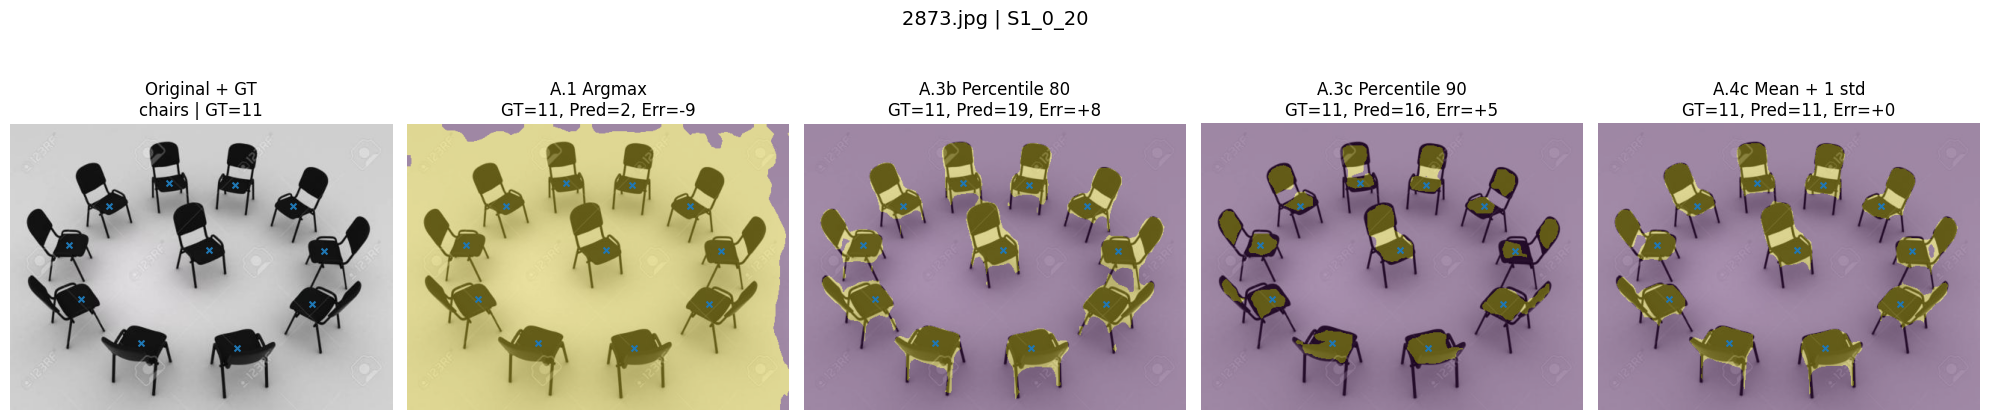

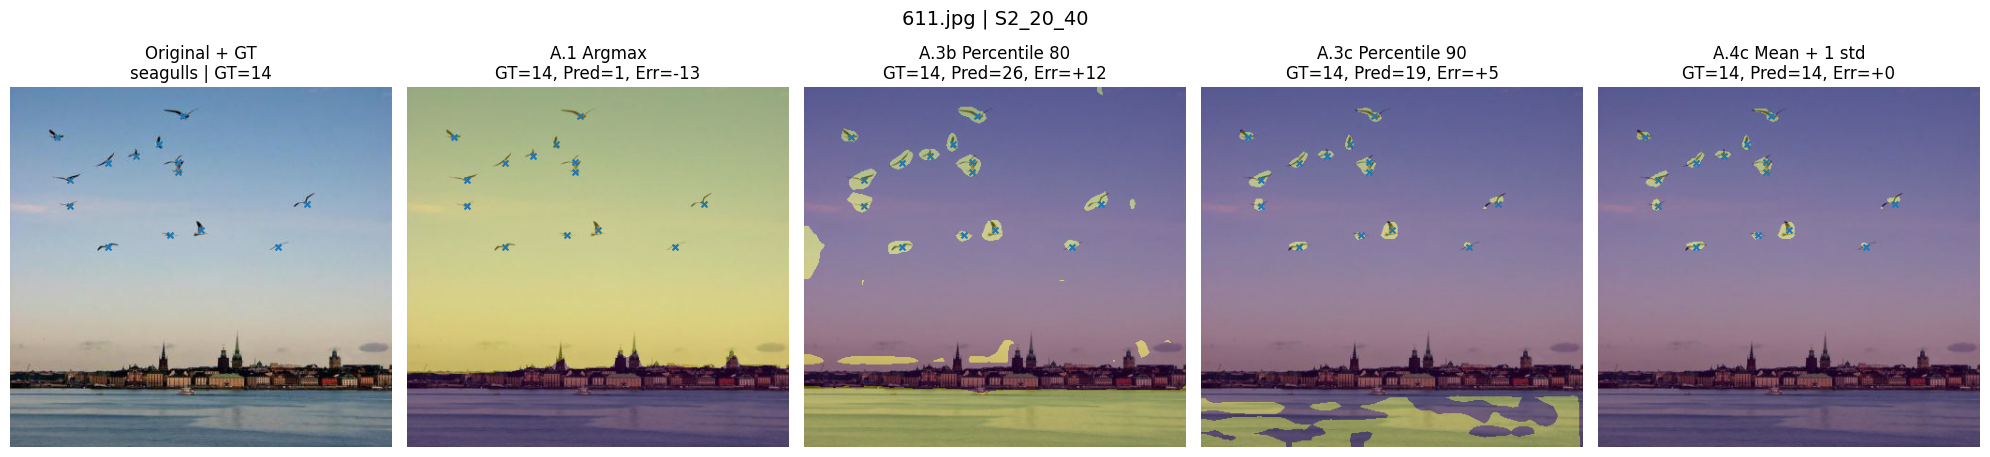

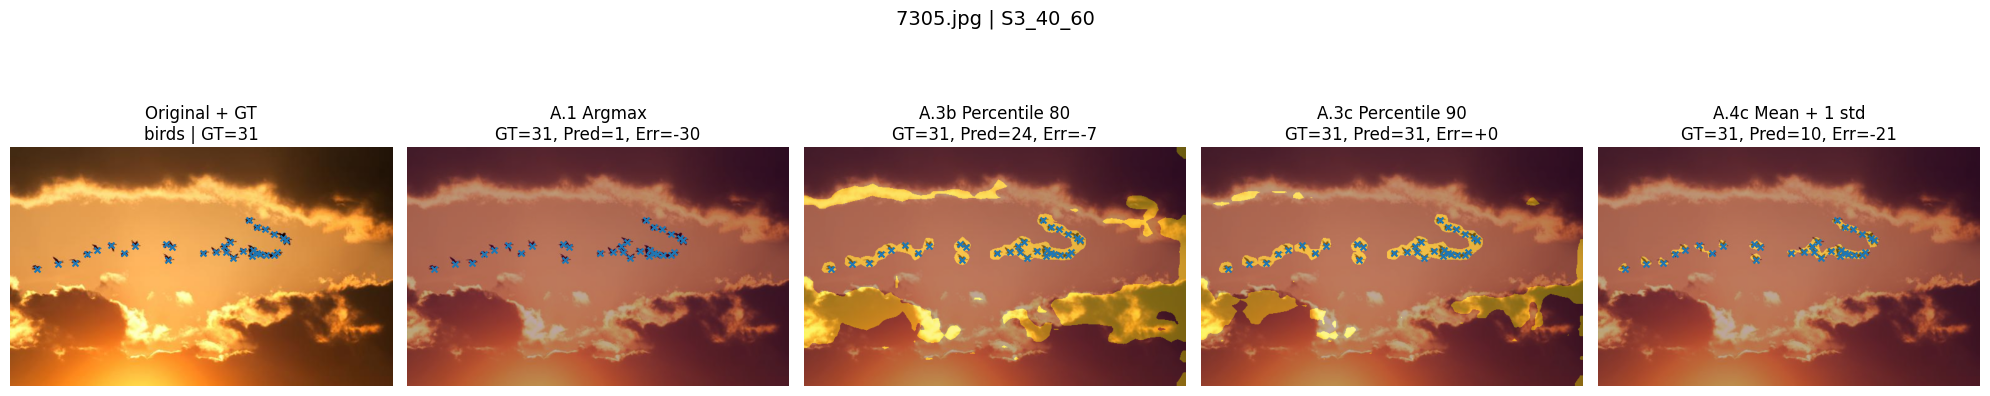

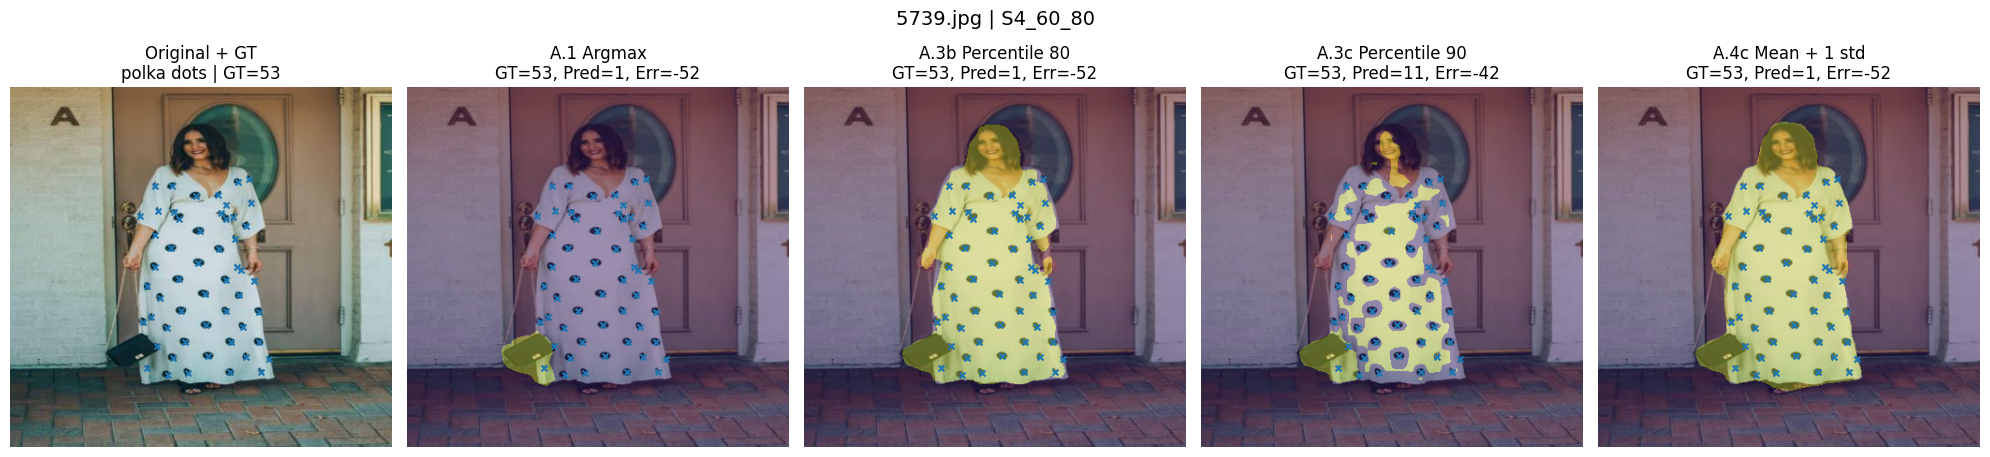

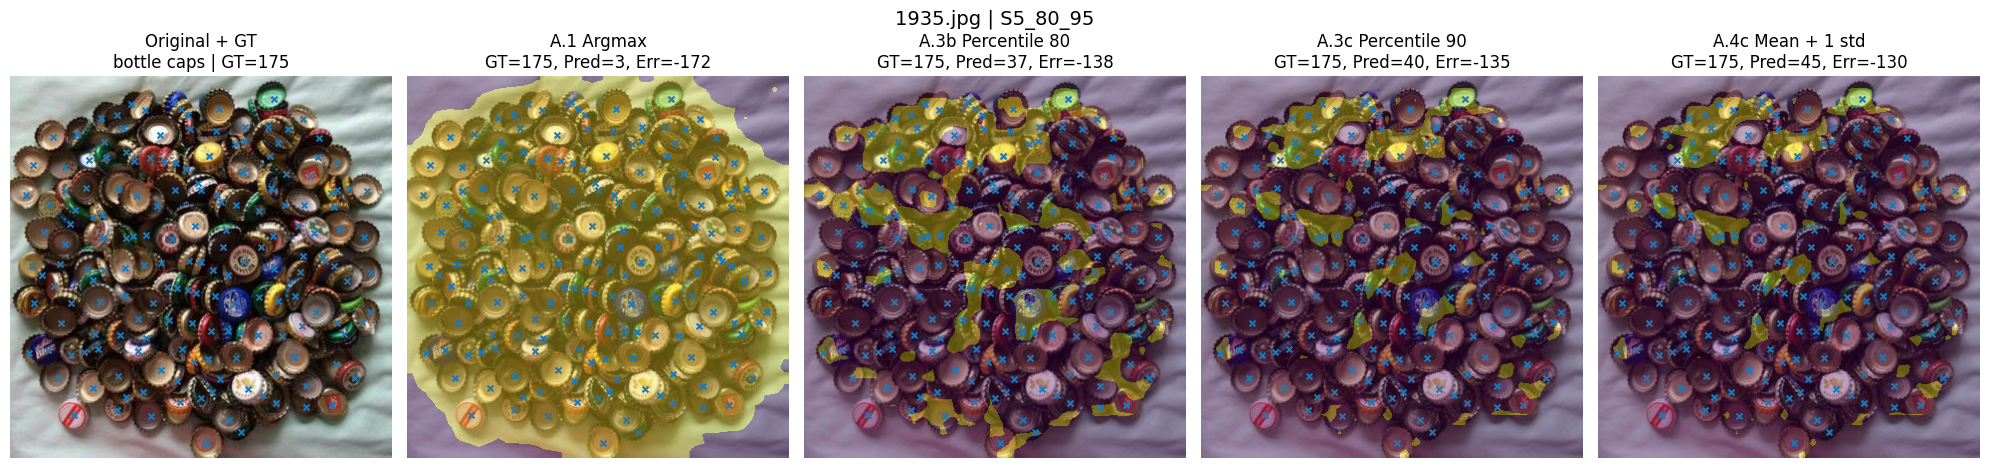

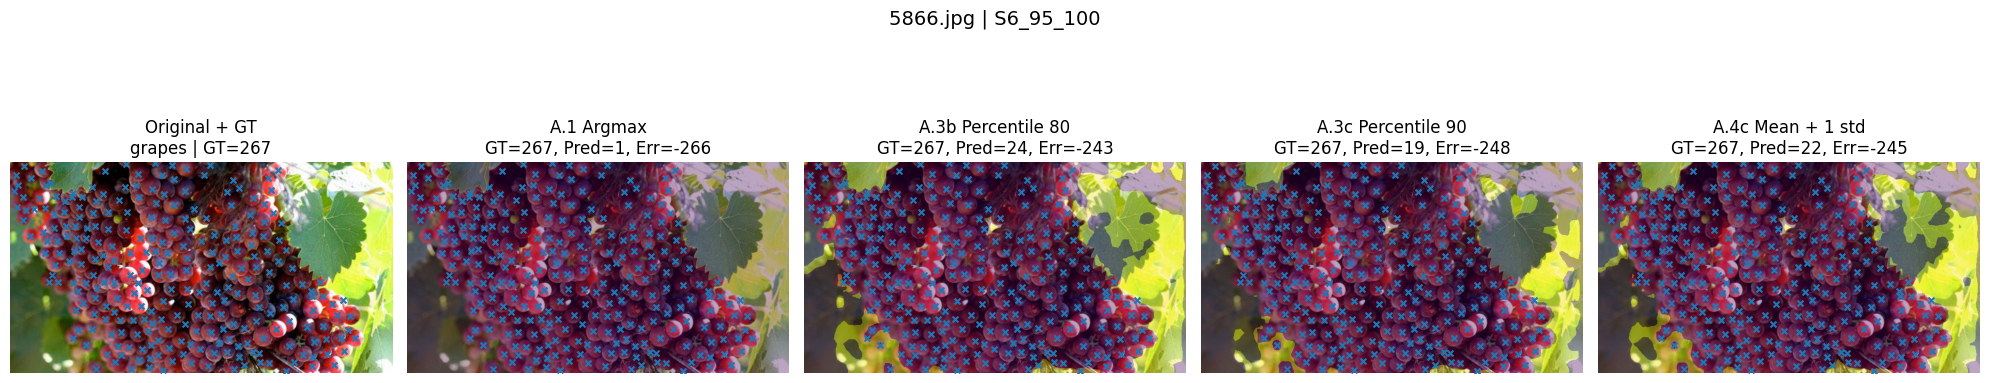

In [63]:
# ============================================================
# Step 8N-4 — Visualise all six diagnostic images
# ============================================================

for _, row in diagnostic_rows.iterrows():

    visualise_group_a_diagnostic(
        row
    )

# Group A conclusion:

1.   Family A.3 - Perecentile-based thresholding
2.   A.3c (90th percentil) as the primary configuration, with A.3b (80th percentile) retained as the secondary configuration.
3.   A.4c is retained as an alternative-family configuration for selective robustness checking later, if warranted.

A.3c achieved the lowest overall MAE and the strongest performance across S3–S5.

A.3b achieved the lowest overall RMSE and strongest S6 performance.

Diagnostic visualisation indicates that percentile thresholding improves counting primarily by breaking weak connections within large semantic foreground regions.

However, it can also fragment individual objects, and substantial merging remains in dense scenes. Consequently, semantic thresholding followed by naïve connected-component extraction is insufficient for robust instance separation.

# Step 9 — Group B: Binary Mask Post-processing Experiments

Group B evaluates whether simple binary-mask post-processing improves
the A.3c semantic masks before connected-component extraction.

Fixed upstream configuration:
- SAN cached target/background scores
- A.3c: 90th-percentile target-score threshold

Fixed downstream configuration:
- connected components
- one geometric centroid per component
- proxy count = number of reference points

Only the binary-mask post-processing operation is varied.

In [64]:
# ============================================================
# Step 9A — Group-B binary mask post-processing
# ============================================================

import numpy as np

from skimage.morphology import (
    disk,
    binary_opening,
    binary_closing,
    remove_small_objects,
)


def get_scaled_radius(
    mask,
    radius_fraction,
):
    """
    Convert a relative radius into pixels.

    Radius is defined relative to the shorter
    image dimension.

    Minimum radius = 1 pixel.
    """

    height, width = mask.shape

    radius = int(
        round(
            min(height, width)
            * float(radius_fraction)
        )
    )

    return max(
        1,
        radius,
    )


def get_scaled_min_area(
    mask,
    area_fraction,
):
    """
    Convert a relative component-area threshold
    into pixels.

    Area is defined relative to total image area.

    Minimum area = 1 pixel.
    """

    height, width = mask.shape

    min_area = int(
        round(
            height
            * width
            * float(area_fraction)
        )
    )

    return max(
        1,
        min_area,
    )


def postprocess_binary_mask(
    mask,
    operation="none",
    **kwargs,
):
    """
    Apply one Group-B binary-mask processing operation.

    Group B:
        B.1  none
        B.2  opening
        B.3  closing
        B.4  remove small components

    Returns
    -------
    processed_mask : np.ndarray, bool
    info : dict
        Processing metadata.
    """

    mask = np.asarray(
        mask,
        dtype=bool,
    )

    # --------------------------------------------------------
    # B.1 — No post-processing
    # --------------------------------------------------------

    if operation == "none":

        processed_mask = mask.copy()

        info = {
            "operation": "none",
            "parameter": None,
            "parameter_pixels": None,
        }

    # --------------------------------------------------------
    # B.2 — Morphological opening
    # --------------------------------------------------------

    elif operation == "opening":

        radius_fraction = float(
            kwargs["radius_fraction"]
        )

        radius_px = get_scaled_radius(
            mask,
            radius_fraction,
        )

        footprint = disk(
            radius_px
        )

        processed_mask = binary_opening(
            mask,
            footprint=footprint,
        )

        info = {
            "operation": "opening",
            "parameter": radius_fraction,
            "parameter_pixels": radius_px,
        }

    # --------------------------------------------------------
    # B.3 — Morphological closing
    # --------------------------------------------------------

    elif operation == "closing":

        radius_fraction = float(
            kwargs["radius_fraction"]
        )

        radius_px = get_scaled_radius(
            mask,
            radius_fraction,
        )

        footprint = disk(
            radius_px
        )

        processed_mask = binary_closing(
            mask,
            footprint=footprint,
        )

        info = {
            "operation": "closing",
            "parameter": radius_fraction,
            "parameter_pixels": radius_px,
        }

    # --------------------------------------------------------
    # B.4 — Remove small foreground components
    # --------------------------------------------------------

    elif operation == "remove_small":

        area_fraction = float(
            kwargs["area_fraction"]
        )

        min_area_px = get_scaled_min_area(
            mask,
            area_fraction,
        )

        processed_mask = remove_small_objects(
            mask,
            min_size=min_area_px,
        )

        info = {
            "operation": "remove_small",
            "parameter": area_fraction,
            "parameter_pixels": min_area_px,
        }

    else:

        raise ValueError(
            f"Unknown Group-B operation: "
            f"{operation}"
        )

    return (
        np.asarray(
            processed_mask,
            dtype=bool,
        ),
        info,
    )

In [65]:
# @title
# ============================================================
# Step 9B — Single-image Group-B sanity check
# ============================================================

test_row = fsc147_dev_100_df.iloc[0]

test_image_id = test_row[
    "image_id"
]

cached = load_san_cache(
    test_image_id
)

# ------------------------------------------------------------
# Fixed Group-A winner: A.3c
# ------------------------------------------------------------

raw_mask, _ = make_semantic_mask(
    cached["target_score"],
    cached["background_score"],
    strategy="percentile",
    percentile=90,
)

# ------------------------------------------------------------
# Example Group-B opening
# ------------------------------------------------------------

processed_mask, processing_info = (
    postprocess_binary_mask(
        raw_mask,
        operation="opening",
        radius_fraction=0.005,
    )
)

raw_proposal = (
    mask_to_centroid_points(
        raw_mask
    )
)

processed_proposal = (
    mask_to_centroid_points(
        processed_mask
    )
)

print(
    "Image:",
    test_image_id,
)

print(
    "GT:",
    int(test_row["gt_count"]),
)

print(
    "Raw A.3c components:",
    raw_proposal[
        "num_components"
    ],
)

print(
    "Processed components:",
    processed_proposal[
        "num_components"
    ],
)

print(
    "Operation:",
    processing_info,
)

print(
    "Raw foreground pixels:",
    int(raw_mask.sum()),
)

print(
    "Processed foreground pixels:",
    int(processed_mask.sum()),
)

Image: 3873.jpg
GT: 7
Raw A.3c components: 7
Processed components: 8
Operation: {'operation': 'opening', 'parameter': 0.005, 'parameter_pixels': 2}
Raw foreground pixels: 14746
Processed foreground pixels: 14672


In [66]:
# ============================================================
# Step 9C — Freeze Group-B experiment configurations
# ============================================================

GROUP_B_CONFIGS = [

    # --------------------------------------------------------
    # B.1 — Fixed A.3c baseline
    # --------------------------------------------------------

    {
        "experiment_id": "B1.B.1",
        "name": "none",
        "operation": "none",
        "kwargs": {},
    },

    # --------------------------------------------------------
    # B.2 — Opening
    # --------------------------------------------------------

    {
        "experiment_id": "B1.B.2a",
        "name": "opening_0.0025",
        "operation": "opening",
        "kwargs": {
            "radius_fraction": 0.0025,
        },
    },

    {
        "experiment_id": "B1.B.2b",
        "name": "opening_0.0050",
        "operation": "opening",
        "kwargs": {
            "radius_fraction": 0.0050,
        },
    },

    {
        "experiment_id": "B1.B.2c",
        "name": "opening_0.0100",
        "operation": "opening",
        "kwargs": {
            "radius_fraction": 0.0100,
        },
    },

    # --------------------------------------------------------
    # B.3 — Closing
    # --------------------------------------------------------

    {
        "experiment_id": "B1.B.3a",
        "name": "closing_0.0025",
        "operation": "closing",
        "kwargs": {
            "radius_fraction": 0.0025,
        },
    },

    {
        "experiment_id": "B1.B.3b",
        "name": "closing_0.0050",
        "operation": "closing",
        "kwargs": {
            "radius_fraction": 0.0050,
        },
    },

    {
        "experiment_id": "B1.B.3c",
        "name": "closing_0.0100",
        "operation": "closing",
        "kwargs": {
            "radius_fraction": 0.0100,
        },
    },

    # --------------------------------------------------------
    # B.4 — Remove small foreground components
    # --------------------------------------------------------

    {
        "experiment_id": "B1.B.4a",
        "name": "remove_small_0.00005",
        "operation": "remove_small",
        "kwargs": {
            "area_fraction": 0.00005,
        },
    },

    {
        "experiment_id": "B1.B.4b",
        "name": "remove_small_0.00010",
        "operation": "remove_small",
        "kwargs": {
            "area_fraction": 0.00010,
        },
    },

    {
        "experiment_id": "B1.B.4c",
        "name": "remove_small_0.00020",
        "operation": "remove_small",
        "kwargs": {
            "area_fraction": 0.00020,
        },
    },
]


print(
    "Number of Group-B configurations:",
    len(GROUP_B_CONFIGS)
)

for config in GROUP_B_CONFIGS:

    print(
        config["experiment_id"],
        config["name"],
        config["kwargs"],
    )

Number of Group-B configurations: 10
B1.B.1 none {}
B1.B.2a opening_0.0025 {'radius_fraction': 0.0025}
B1.B.2b opening_0.0050 {'radius_fraction': 0.005}
B1.B.2c opening_0.0100 {'radius_fraction': 0.01}
B1.B.3a closing_0.0025 {'radius_fraction': 0.0025}
B1.B.3b closing_0.0050 {'radius_fraction': 0.005}
B1.B.3c closing_0.0100 {'radius_fraction': 0.01}
B1.B.4a remove_small_0.00005 {'area_fraction': 5e-05}
B1.B.4b remove_small_0.00010 {'area_fraction': 0.0001}
B1.B.4c remove_small_0.00020 {'area_fraction': 0.0002}


In [67]:
# ============================================================
# Step 9D — Group-B experiment runner
# ============================================================

from tqdm.auto import tqdm
import pandas as pd
import time


def run_group_b_experiment(
    dev_df,
    operation,
    **operation_kwargs,
):
    """
    Run one Group-B configuration over the frozen
    FSC-147 development subset.

    Fixed upstream:
        SAN cached output
        A.3c percentile-90 threshold

    Variable:
        binary-mask post-processing

    Fixed downstream:
        connected components
        geometric centroid per component
        proxy count = number of points
    """

    rows = []

    start_time = time.perf_counter()

    for _, row in tqdm(
        dev_df.iterrows(),
        total=len(dev_df),
        desc=f"Running Group B: {operation}",
    ):

        image_id = row[
            "image_id"
        ]

        cached = load_san_cache(
            image_id
        )

        # ----------------------------------------------------
        # Fixed A.3c mask
        # ----------------------------------------------------

        raw_mask, mask_info = (
            make_semantic_mask(
                cached[
                    "target_score"
                ],
                cached[
                    "background_score"
                ],
                strategy="percentile",
                percentile=90,
            )
        )

        # ----------------------------------------------------
        # Group-B processing
        # ----------------------------------------------------

        processed_mask, processing_info = (
            postprocess_binary_mask(
                raw_mask,
                operation=operation,
                **operation_kwargs,
            )
        )

        # ----------------------------------------------------
        # Fixed connected components + centroids
        # ----------------------------------------------------

        proposal_info = (
            mask_to_centroid_points(
                processed_mask
            )
        )

        gt_count = int(
            row["gt_count"]
        )

        pred_count = int(
            proposal_info[
                "num_points"
            ]
        )

        error = (
            pred_count
            - gt_count
        )

        rows.append(
            {
                "image_id": image_id,

                "dataset_index": int(
                    row[
                        "dataset_index"
                    ]
                ),

                "category": row[
                    "category"
                ],

                "density_stratum": row[
                    "density_stratum"
                ],

                "gt_count": gt_count,
                "pred_count": pred_count,

                "error": error,
                "abs_error": abs(
                    error
                ),

                # --------------------------------------------
                # Raw A.3c mask
                # --------------------------------------------

                "raw_foreground_pixels": int(
                    raw_mask.sum()
                ),

                "raw_foreground_fraction": float(
                    raw_mask.mean()
                ),

                # --------------------------------------------
                # Group-B processed mask
                # --------------------------------------------

                "processed_foreground_pixels": int(
                    processed_mask.sum()
                ),

                "processed_foreground_fraction": float(
                    processed_mask.mean()
                ),

                "foreground_pixel_change": int(
                    processed_mask.sum()
                    - raw_mask.sum()
                ),

                # --------------------------------------------
                # Final proposals
                # --------------------------------------------

                "num_components": int(
                    proposal_info[
                        "num_components"
                    ]
                ),

                "num_reference_points": int(
                    proposal_info[
                        "num_points"
                    ]
                ),

                # --------------------------------------------
                # Configuration metadata
                # --------------------------------------------

                "mask_strategy":
                    "percentile",

                "mask_percentile":
                    90,

                "mask_threshold":
                    mask_info.get(
                        "threshold"
                    ),

                "postprocess_operation":
                    operation,

                "postprocess_parameter":
                    processing_info.get(
                        "parameter"
                    ),

                "postprocess_parameter_pixels":
                    processing_info.get(
                        "parameter_pixels"
                    ),
            }
        )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    results_df = pd.DataFrame(
        rows
    )

    return (
        results_df,
        elapsed_time,
    )

In [68]:
# ============================================================
# Step 9E — Run complete Group-B experiment sweep
# ============================================================

group_b_results = {}


for config in GROUP_B_CONFIGS:

    experiment_id = config[
        "experiment_id"
    ]

    name = config[
        "name"
    ]

    operation = config[
        "operation"
    ]

    operation_kwargs = config[
        "kwargs"
    ]

    print(
        "\n"
        + "=" * 70
    )

    print(
        experiment_id,
        "—",
        name,
    )

    print(
        "=" * 70
    )

    results_df, runtime = (
        run_group_b_experiment(
            fsc147_dev_100_df,
            operation=operation,
            **operation_kwargs,
        )
    )

    metrics_df = (
        evaluate_by_density_stratum(
            results_df
        )
    )

    group_b_results[
        experiment_id
    ] = {
        "config": config,
        "results_df": results_df,
        "metrics_df": metrics_df,
        "runtime": runtime,
    }

    overall = (
        metrics_df[
            metrics_df[
                "scope"
            ]
            == "Overall"
        ]
        .iloc[0]
    )

    print(
        f"Runtime: "
        f"{runtime:.3f}s"
    )

    print(
        f"Overall MAE: "
        f"{overall['mae']:.3f}"
    )

    print(
        f"Overall RMSE: "
        f"{overall['rmse']:.3f}"
    )

    print(
        f"Sum GT: "
        f"{int(overall['sum_gt'])}"
    )

    print(
        f"Sum Pred: "
        f"{int(overall['sum_pred'])}"
    )


B1.B.1 — none


Running Group B: none:   0%|          | 0/100 [00:00<?, ?it/s]

Runtime: 3.024s
Overall MAE: 79.670
Overall RMSE: 263.541
Sum GT: 10045
Sum Pred: 2554

B1.B.2a — opening_0.0025


Running Group B: opening:   0%|          | 0/100 [00:00<?, ?it/s]

Runtime: 4.577s
Overall MAE: 80.690
Overall RMSE: 264.930
Sum GT: 10045
Sum Pred: 2298

B1.B.2b — opening_0.0050


...

Runtime: 2.881s
Overall MAE: 81.160
Overall RMSE: 265.435
Sum GT: 10045
Sum Pred: 2243

B1.B.4b — remove_small_0.00010


Running Group B: remove_small:   0%|          | 0/100 [00:00<?, ?it/s]

Runtime: 3.858s
Overall MAE: 82.300
Overall RMSE: 266.676
Sum GT: 10045
Sum Pred: 2035

B1.B.4c — remove_small_0.00020


Running Group B: remove_small:   0%|          | 0/100 [00:00<?, ?it/s]

Runtime: 2.828s
Overall MAE: 83.740
Overall RMSE: 267.948
Sum GT: 10045
Sum Pred: 1829


In [69]:
# ============================================================
# Step 9F — Group-B comparison table
# ============================================================

summary_rows = []


for config in GROUP_B_CONFIGS:

    experiment_id = config[
        "experiment_id"
    ]

    result = group_b_results[
        experiment_id
    ]

    metrics_df = result[
        "metrics_df"
    ]

    summary_row = {
        "experiment_id":
            experiment_id,

        "name":
            config["name"],

        "operation":
            config["operation"],

        "runtime_sec":
            result["runtime"],
    }

    # --------------------------------------------------------
    # Overall + S1 ... S6
    # --------------------------------------------------------

    for _, metric_row in (
        metrics_df.iterrows()
    ):

        scope = metric_row[
            "scope"
        ]

        summary_row[
            f"{scope}_MAE"
        ] = metric_row[
            "mae"
        ]

        summary_row[
            f"{scope}_RMSE"
        ] = metric_row[
            "rmse"
        ]

    # --------------------------------------------------------
    # Overall diagnostics
    # --------------------------------------------------------

    overall = (
        metrics_df[
            metrics_df[
                "scope"
            ]
            == "Overall"
        ]
        .iloc[0]
    )

    summary_row[
        "Overall_mean_signed_error"
    ] = overall[
        "mean_signed_error"
    ]

    summary_row[
        "Overall_undercount"
    ] = int(
        overall[
            "undercount"
        ]
    )

    summary_row[
        "Overall_exact"
    ] = int(
        overall[
            "exact"
        ]
    )

    summary_row[
        "Overall_overcount"
    ] = int(
        overall[
            "overcount"
        ]
    )

    summary_row[
        "sum_gt"
    ] = int(
        overall[
            "sum_gt"
        ]
    )

    summary_row[
        "sum_pred"
    ] = int(
        overall[
            "sum_pred"
        ]
    )

    summary_rows.append(
        summary_row
    )


group_b_summary_df = pd.DataFrame(
    summary_rows
)

display(
    group_b_summary_df
)

,experiment_id,name,operation,runtime_sec,Overall_MAE,Overall_RMSE,S1_0_20_MAE,S1_0_20_RMSE,S2_20_40_MAE,S2_20_40_RMSE,...,S5_80_95_MAE,S5_80_95_RMSE,S6_95_100_MAE,S6_95_100_RMSE,Overall_mean_signed_error,Overall_undercount,Overall_exact,Overall_overcount,sum_gt,sum_pred
0,B1.B.1,none,none,3.023644,79.67,263.541363,5.25,7.010706,8.30,10.894953,...,74.6,83.587080,619.6,827.614645,-74.91,68,5,27,10045,2554
1,B1.B.2a,opening_0.0025,opening,4.577328,80.69,264.929783,4.80,6.172520,6.60,8.167007,...,76.8,85.373298,626.0,831.736978,-77.47,72,3,25,10045,2298
2,B1.B.2b,opening_0.0050,opening,3.377961,82.27,266.542323,4.35,5.634714,6.20,7.141428,...,81.1,89.138656,632.7,836.319736,-80.03,79,2,19,10045,2042
3,B1.B.2c,opening_0.0100,opening,4.222717,84.90,268.973939,4.25,5.277310,4.60,5.983310,...,89.0,95.769515,643.9,842.994365,-83.86,83,3,14,10045,1659
4,B1.B.3a,closing_0.0025,closing,4.565566,79.80,263.566652,5.20,6.942622,8.35,10.911004,...,75.0,83.860599,619.7,827.638871,-75.16,69,5,26,10045,2529
5,B1.B.3b,closing_0.0050,closing,4.419668,80.13,263.982632,5.30,7.049823,8.20,10.719142,...,75.9,84.437551,620.7,828.877494,-75.61,71,3,26,10045,2484
6,B1.B.3c,closing_0.0100,closing,4.712897,80.50,264.115884,5.00,6.348228,7.90,9.994999,...,77.1,85.301231,621.9,829.162167,-76.50,70,3,27,10045,2395
7,B1.B.4a,remove_small_0.00005,remove_small,2.880620,81.16,265.435228,4.75,6.119641,6.60,7.823043,...,78.2,86.253116,628.1,833.241202,-78.02,74,2,24,10045,2243
8,B1.B.4b,remove_small_0.00010,remove_small,3.858067,82.30,266.675983,4.25,5.616939,6.00,7.078135,...,81.4,88.836929,633.8,836.778824,-80.10,76,6,18,10045,2035
9,B1.B.4c,remove_small_0.00020,remove_small,2.828361,83.74,267.947681,4.05,5.361903,6.10,6.935416,...,84.7,92.111346,639.1,840.322974,-82.16,80,4,16,10045,1829


In [70]:
# ============================================================
# Step 9G — Compact Group-B ranking
# ============================================================

ranking_columns = [
    "experiment_id",
    "name",
    "operation",

    "Overall_MAE",
    "Overall_RMSE",

    "S1_0_20_MAE",
    "S2_20_40_MAE",
    "S3_40_60_MAE",
    "S4_60_80_MAE",
    "S5_80_95_MAE",
    "S6_95_100_MAE",

    "Overall_mean_signed_error",
    "Overall_undercount",
    "Overall_exact",
    "Overall_overcount",

    "sum_pred",
    "runtime_sec",
]


group_b_ranking_df = (
    group_b_summary_df[
        ranking_columns
    ]
    .sort_values(
        by="Overall_MAE",
        ascending=True,
    )
    .reset_index(
        drop=True
    )
)


display(
    group_b_ranking_df
)

,experiment_id,name,operation,Overall_MAE,Overall_RMSE,S1_0_20_MAE,S2_20_40_MAE,S3_40_60_MAE,S4_60_80_MAE,S5_80_95_MAE,S6_95_100_MAE,Overall_mean_signed_error,Overall_undercount,Overall_exact,Overall_overcount,sum_pred,runtime_sec
0,B1.B.1,none,none,79.67,263.541363,5.25,8.30,11.20,26.50,74.6,619.6,-74.91,68,5,27,2554,3.023644
1,B1.B.3a,closing_0.0025,closing,79.80,263.566652,5.20,8.35,11.10,27.00,75.0,619.7,-75.16,69,5,26,2529,4.565566
2,B1.B.3b,closing_0.0050,closing,80.13,263.982632,5.30,8.20,11.30,27.55,75.9,620.7,-75.61,71,3,26,2484,4.419668
3,B1.B.3c,closing_0.0100,closing,80.50,264.115884,5.00,7.90,11.35,28.75,77.1,621.9,-76.50,70,3,27,2395,4.712897
4,B1.B.2a,opening_0.0025,opening,80.69,264.929783,4.80,6.60,11.05,29.60,76.8,626.0,-77.47,72,3,25,2298,4.577328
5,B1.B.4a,remove_small_0.00005,remove_small,81.16,265.435228,4.75,6.60,11.35,29.95,78.2,628.1,-78.02,74,2,24,2243,2.880620
6,B1.B.2b,opening_0.0050,opening,82.27,266.542323,4.35,6.20,12.00,31.90,81.1,632.7,-80.03,79,2,19,2042,3.377961
7,B1.B.4b,remove_small_0.00010,remove_small,82.30,266.675983,4.25,6.00,11.70,31.95,81.4,633.8,-80.10,76,6,18,2035,3.858067
8,B1.B.4c,remove_small_0.00020,remove_small,83.74,267.947681,4.05,6.10,13.05,33.60,84.7,639.1,-82.16,80,4,16,1829,2.828361
9,B1.B.2c,opening_0.0100,opening,84.90,268.973939,4.25,4.60,13.60,35.60,89.0,643.9,-83.86,83,3,14,1659,4.222717


In [71]:
# ============================================================
# Step 9H — Save complete Group-B results
# ============================================================

GROUP_B_RESULTS_DIR = (
    B1_RESULTS_ROOT /
    "Group_B"
)

GROUP_B_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


for config in GROUP_B_CONFIGS:

    experiment_id = config[
        "experiment_id"
    ]

    safe_id = (
        experiment_id
        .replace(".", "_")
    )

    result = group_b_results[
        experiment_id
    ]

    per_image_file = (
        GROUP_B_RESULTS_DIR /
        f"{safe_id}_dev100_per_image.csv"
    )

    metrics_file = (
        GROUP_B_RESULTS_DIR /
        f"{safe_id}_dev100_metrics.csv"
    )

    result[
        "results_df"
    ].to_csv(
        per_image_file,
        index=False,
    )

    result[
        "metrics_df"
    ].to_csv(
        metrics_file,
        index=False,
    )


GROUP_B_SUMMARY_FILE = (
    GROUP_B_RESULTS_DIR /
    "B1_Group_B_dev100_summary.csv"
)

GROUP_B_RANKING_FILE = (
    GROUP_B_RESULTS_DIR /
    "B1_Group_B_dev100_ranking.csv"
)


group_b_summary_df.to_csv(
    GROUP_B_SUMMARY_FILE,
    index=False,
)

group_b_ranking_df.to_csv(
    GROUP_B_RANKING_FILE,
    index=False,
)


print(
    "Saved Group-B summary:",
    GROUP_B_SUMMARY_FILE,
)

print(
    "Saved Group-B ranking:",
    GROUP_B_RANKING_FILE,
)

Saved Group-B summary: /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments/Group_B/B1_Group_B_dev100_summary.csv
Saved Group-B ranking: /content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments/Group_B/B1_Group_B_dev100_ranking.csv


# Group B conclusion:

**None of the tested binary-mask post-processing operations improved overall counting performance on the frozen FSC-147 dev100 subset.**

The unprocessed A.3c mask achieved the lowest MAE (79.67) and RMSE (263.54).

Opening and small-component removal improved some low-density strata but increasingly degraded performance at higher densities, while closing produced only minor changes and no overall gain.

These results indicate that generic morphological clean-up **does not address** the dominant failure mode, which is the merging of multiple object instances within connected semantic regions. Therefore, no binary post-processing is retained, and **the unmodified A.3c mask is carried forward to Group C.**

# Step 10 — Group C: Region Splitting / Watershed Experiments

Group C evaluates whether merged connected semantic regions can be
split into better object-candidate regions.

Fixed upstream configuration:
- SAN cached target/background scores
- A.3c: 90th-percentile target-score threshold
- Group B: no post-processing

Fixed downstream configuration:
- one geometric centroid per resulting region
- proxy count = number of reference points

Group C compares:
- C.1: ordinary connected components (no splitting)
- C.2: distance-transform watershed with image-relative spatial peak separation
- C.3: distance-transform watershed with component-relative h-maxima prominence

In [72]:
# ============================================================
# Step 10A — Inspect FSC-147 dev100 image dimensions
# ============================================================

import pandas as pd
import numpy as np


image_size_rows = []


for _, row in fsc147_dev_100_df.iterrows():

    dataset_index = int(
        row["dataset_index"]
    )

    sample = fsc147_val_dataset[
        dataset_index
    ]

    width = int(
        sample["width"]
    )

    height = int(
        sample["height"]
    )

    short_side = min(
        width,
        height,
    )

    long_side = max(
        width,
        height,
    )

    image_size_rows.append(
        {
            "image_id": row["image_id"],
            "dataset_index": dataset_index,
            "width": width,
            "height": height,
            "short_side": short_side,
            "long_side": long_side,
        }
    )


group_c_image_sizes_df = pd.DataFrame(
    image_size_rows
)


display(
    group_c_image_sizes_df.head()
)

,image_id,dataset_index,width,height,short_side,long_side
0,3873.jpg,576,384,384,384,384
1,1964.jpg,322,540,384,384,540
2,774.jpg,153,575,384,384,575
3,2304.jpg,360,613,384,384,613
4,3573.jpg,514,408,384,384,408


In [73]:
# ============================================================
# Step 10A.1 — Image-size summary
# ============================================================

short_side_summary = (
    group_c_image_sizes_df[
        "short_side"
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
        ]
    )
)


print(
    "FSC-147 dev100 short-side distribution:"
)

display(
    short_side_summary
)

FSC-147 dev100 short-side distribution:


,short_side
count,100.0
mean,384.0
std,0.0
min,384.0
10%,384.0
25%,384.0
50%,384.0
75%,384.0
90%,384.0
max,384.0


In [74]:
# ============================================================
# Step 10A.2 — Candidate C.2 alpha values
# ============================================================

C2_ALPHA_CANDIDATES = [
    0.005,
    0.010,
    0.020,
]


representative_short_sides = {
    "min": int(
        group_c_image_sizes_df[
            "short_side"
        ].min()
    ),

    "25%": int(
        group_c_image_sizes_df[
            "short_side"
        ].quantile(0.25)
    ),

    "median": int(
        group_c_image_sizes_df[
            "short_side"
        ].median()
    ),

    "75%": int(
        group_c_image_sizes_df[
            "short_side"
        ].quantile(0.75)
    ),

    "max": int(
        group_c_image_sizes_df[
            "short_side"
        ].max()
    ),
}


alpha_rows = []


for label, short_side in (
    representative_short_sides.items()
):

    row = {
        "short_side_position": label,
        "short_side_px": short_side,
    }

    for alpha in C2_ALPHA_CANDIDATES:

        min_distance = max(
            1,
            int(
                round(
                    alpha
                    * short_side
                )
            ),
        )

        row[
            f"alpha_{alpha:.3f}_px"
        ] = min_distance

    alpha_rows.append(
        row
    )


c2_alpha_pixel_table = pd.DataFrame(
    alpha_rows
)


display(
    c2_alpha_pixel_table
)

,short_side_position,short_side_px,alpha_0.005_px,alpha_0.010_px,alpha_0.020_px
0,min,384,2,4,8
1,25%,384,2,4,8
2,median,384,2,4,8
3,75%,384,2,4,8
4,max,384,2,4,8


## Step 10B — Group-C region handling functions

Implements:

- C.1: ordinary connected components
- C.2: distance-transform watershed with image-relative spatial peak separation
- C.3: distance-transform watershed with component-relative h-maxima prominence

The A.3c binary mask is assumed to be provided as input.

In [75]:
# ============================================================
# Step 10B — Group-C region handling functions
# ============================================================

import numpy as np

from scipy import ndimage as ndi

from skimage.feature import peak_local_max
from skimage.measure import label, regionprops
from skimage.morphology import h_maxima
from skimage.segmentation import watershed

In [76]:
# ============================================================
# Step 10B.1 — Labelled regions → centroid reference points
# ============================================================

def labelled_regions_to_points(
    labelled_regions,
):
    """
    Convert labelled regions into one geometric centroid
    per region.

    Returns
    -------
    dict with:
        labelled_regions
        points              Nx2 array [x, y]
        num_regions
        num_points
        region_areas
    """

    labelled_regions = np.asarray(
        labelled_regions,
        dtype=np.int32,
    )

    props = regionprops(
        labelled_regions
    )

    points = []
    region_areas = []

    for region in props:

        # skimage centroid is returned as (row, col) = (y, x)
        y, x = region.centroid

        points.append(
            [x, y]
        )

        region_areas.append(
            int(region.area)
        )

    points = np.asarray(
        points,
        dtype=float,
    ).reshape(-1, 2)

    return {
        "labelled_regions":
            labelled_regions,

        "points":
            points,

        "num_regions":
            len(props),

        "num_points":
            len(points),

        "region_areas":
            region_areas,
    }

In [77]:
# ============================================================
# Step 10B.2 — C.1 ordinary connected components
# ============================================================

def group_c_connected_components(
    mask,
):
    """
    C.1 baseline:
    ordinary connected components with 4-connectivity.
    """

    mask = np.asarray(
        mask,
        dtype=bool,
    )

    labelled_regions = label(
        mask,
        connectivity=1,
    )

    result = labelled_regions_to_points(
        labelled_regions
    )

    result["strategy"] = "connected_components"
    result["parameter"] = None

    return result

In [78]:
# ============================================================
# Step 10B.3 — C.2 spatial-separation watershed
# ============================================================

def group_c_watershed_spatial(
    mask,
    alpha,
):
    """
    C.2:
    Distance-transform watershed using local-maxima markers
    with image-relative minimum spatial separation.

    Parameters
    ----------
    mask : 2D bool array
        A.3c binary semantic mask.

    alpha : float
        Relative minimum peak separation:
            min_distance = alpha * min(H, W)
    """

    mask = np.asarray(
        mask,
        dtype=bool,
    )

    height, width = mask.shape

    min_distance = max(
        1,
        int(
            round(
                float(alpha)
                * min(height, width)
            )
        ),
    )

    # Connected components of the original mask
    cc_labels = label(
        mask,
        connectivity=1,
    )

    output_labels = np.zeros(
        mask.shape,
        dtype=np.int32,
    )

    next_label = 1

    total_markers = 0
    original_components = int(
        cc_labels.max()
    )

    # --------------------------------------------------------
    # Process each connected component independently
    # --------------------------------------------------------

    for component_id in range(
        1,
        original_components + 1,
    ):

        component_mask = (
            cc_labels
            == component_id
        )

        if not component_mask.any():
            continue

        # Euclidean distance transform
        distance = ndi.distance_transform_edt(
            component_mask
        )

        # Local maxima coordinates
        peak_coords = peak_local_max(
            distance,
            labels=component_mask,
            min_distance=min_distance,
            exclude_border=False,
        )

        # ----------------------------------------------------
        # Safety fallback:
        # every non-empty component must retain >= 1 marker
        # ----------------------------------------------------

        if len(peak_coords) == 0:

            max_pos = np.unravel_index(
                np.argmax(distance),
                distance.shape,
            )

            peak_coords = np.asarray(
                [max_pos]
            )

        markers = np.zeros(
            mask.shape,
            dtype=np.int32,
        )

        for marker_id, (
            row,
            col,
        ) in enumerate(
            peak_coords,
            start=1,
        ):

            markers[
                row,
                col,
            ] = marker_id

        total_markers += len(
            peak_coords
        )

        # Watershed on negative distance
        ws_labels = watershed(
            -distance,
            markers=markers,
            mask=component_mask,
        )

        # Copy local watershed regions into global label map
        local_region_ids = np.unique(
            ws_labels
        )

        local_region_ids = (
            local_region_ids[
                local_region_ids > 0
            ]
        )

        for local_id in local_region_ids:

            output_labels[
                ws_labels == local_id
            ] = next_label

            next_label += 1

    result = labelled_regions_to_points(
        output_labels
    )

    result["strategy"] = (
        "watershed_spatial"
    )

    result["parameter"] = float(
        alpha
    )

    result["min_distance_px"] = int(
        min_distance
    )

    result["original_components"] = (
        original_components
    )

    result["num_markers"] = int(
        total_markers
    )

    return result

In [79]:
# ============================================================
# Step 10B.4 — C.3 component-relative h-maxima watershed
# ============================================================

def group_c_watershed_hmax(
    mask,
    beta,
):
    """
    C.3:
    Distance-transform watershed using component-relative
    h-maxima marker generation.

    For component C:

        h_C = beta * D_max,C

    where D_max,C is the maximum Euclidean distance-transform
    value within that component.
    """

    mask = np.asarray(
        mask,
        dtype=bool,
    )

    cc_labels = label(
        mask,
        connectivity=1,
    )

    output_labels = np.zeros(
        mask.shape,
        dtype=np.int32,
    )

    next_label = 1

    original_components = int(
        cc_labels.max()
    )

    total_markers = 0

    component_h_values = []
    component_dmax_values = []

    # --------------------------------------------------------
    # Process each connected component independently
    # --------------------------------------------------------

    for component_id in range(
        1,
        original_components + 1,
    ):

        component_mask = (
            cc_labels
            == component_id
        )

        if not component_mask.any():
            continue

        distance = ndi.distance_transform_edt(
            component_mask
        )

        dmax = float(
            distance[
                component_mask
            ].max()
        )

        component_dmax_values.append(
            dmax
        )

        # ----------------------------------------------------
        # Component-relative h
        # ----------------------------------------------------

        h_value = (
            float(beta)
            * dmax
        )

        # Numerical safeguard
        h_value = max(
            h_value,
            1e-6,
        )

        component_h_values.append(
            h_value
        )

        # ----------------------------------------------------
        # h-maxima gives a boolean image containing
        # surviving significant maxima
        # ----------------------------------------------------

        maxima_mask = h_maxima(
            distance,
            h=h_value,
        )

        # Restrict explicitly to this component
        maxima_mask &= (
            component_mask
        )

        # Label connected maxima plateaus as markers
        markers, num_markers = (
            ndi.label(
                maxima_mask
            )
        )

        # ----------------------------------------------------
        # Safety fallback
        # ----------------------------------------------------

        if num_markers == 0:

            markers = np.zeros(
                mask.shape,
                dtype=np.int32,
            )

            max_pos = np.unravel_index(
                np.argmax(distance),
                distance.shape,
            )

            markers[
                max_pos
            ] = 1

            num_markers = 1

        total_markers += int(
            num_markers
        )

        # ----------------------------------------------------
        # Watershed
        # ----------------------------------------------------

        ws_labels = watershed(
            -distance,
            markers=markers,
            mask=component_mask,
        )

        local_region_ids = np.unique(
            ws_labels
        )

        local_region_ids = (
            local_region_ids[
                local_region_ids > 0
            ]
        )

        for local_id in local_region_ids:

            output_labels[
                ws_labels == local_id
            ] = next_label

            next_label += 1

    result = labelled_regions_to_points(
        output_labels
    )

    result["strategy"] = (
        "watershed_hmax"
    )

    result["parameter"] = float(
        beta
    )

    result["original_components"] = (
        original_components
    )

    result["num_markers"] = int(
        total_markers
    )

    result[
        "component_dmax_values"
    ] = component_dmax_values

    result[
        "component_h_values"
    ] = component_h_values

    return result

In [80]:
# ============================================================
# Step 10B.5 — Unified Group-C interface
# ============================================================

def extract_group_c_regions(
    mask,
    strategy,
    **kwargs,
):
    """
    Unified Group-C region extraction interface.
    """

    if strategy == "connected_components":

        return (
            group_c_connected_components(
                mask
            )
        )

    elif strategy == "watershed_spatial":

        return (
            group_c_watershed_spatial(
                mask,
                alpha=kwargs[
                    "alpha"
                ],
            )
        )

    elif strategy == "watershed_hmax":

        return (
            group_c_watershed_hmax(
                mask,
                beta=kwargs[
                    "beta"
                ],
            )
        )

    else:

        raise ValueError(
            f"Unknown Group-C strategy: "
            f"{strategy}"
        )

In [81]:
# ============================================================
# Step 10C — Single-image Group-C sanity check
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

In [82]:
# ------------------------------------------------------------
# Step 10C.1 — Select a known merged-object example
# ------------------------------------------------------------

TEST_IMAGE_ID = "1935.jpg"

test_row = (
    fsc147_dev_100_df[
        fsc147_dev_100_df["image_id"]
        == TEST_IMAGE_ID
    ]
    .iloc[0]
)

dataset_index = int(
    test_row["dataset_index"]
)

sample = fsc147_val_dataset[
    dataset_index
]

category = test_row[
    "category"
]

gt_count = int(
    test_row["gt_count"]
)

print(
    "Image:",
    TEST_IMAGE_ID
)

print(
    "Category:",
    category
)

print(
    "GT count:",
    gt_count
)

Image: 1935.jpg
Category: bottle caps
GT count: 175


In [83]:
# ------------------------------------------------------------
# Step 10C.2 — Fixed Group-A winner: A.3c
# ------------------------------------------------------------

cached = load_san_cache(
    TEST_IMAGE_ID
)

a3c_mask, a3c_info = (
    make_semantic_mask(
        cached["target_score"],
        cached["background_score"],
        strategy="percentile",
        percentile=90,
    )
)

print(
    "A.3c foreground pixels:",
    int(a3c_mask.sum())
)

print(
    "A.3c foreground fraction:",
    float(a3c_mask.mean())
)

A.3c foreground pixels: 14746
A.3c foreground fraction: 0.1000027126736111


In [84]:
# ------------------------------------------------------------
# Step 10C.3 — Run representative C.1 / C.2 / C.3
# ------------------------------------------------------------

c1_result = extract_group_c_regions(
    a3c_mask,
    strategy="connected_components",
)


c2_result = extract_group_c_regions(
    a3c_mask,
    strategy="watershed_spatial",
    alpha=0.010,
)


c3_result = extract_group_c_regions(
    a3c_mask,
    strategy="watershed_hmax",
    beta=0.20,
)

In [85]:
print(
    "\nC.1 — Connected components"
)

print(
    "Regions:",
    c1_result["num_regions"]
)


print(
    "\nC.2 — Spatial watershed"
)

print(
    "Original components:",
    c2_result["original_components"]
)

print(
    "Markers:",
    c2_result["num_markers"]
)

print(
    "Watershed regions:",
    c2_result["num_regions"]
)

print(
    "min_distance:",
    c2_result["min_distance_px"],
    "px",
)


print(
    "\nC.3 — h-maxima watershed"
)

print(
    "Original components:",
    c3_result["original_components"]
)

print(
    "Markers:",
    c3_result["num_markers"]
)

print(
    "Watershed regions:",
    c3_result["num_regions"]
)

print(
    "beta:",
    c3_result["parameter"]
)


C.1 — Connected components
Regions: 40

C.2 — Spatial watershed
Original components: 40
Markers: 69
Watershed regions: 69
min_distance: 4 px

C.3 — h-maxima watershed
Original components: 40
Markers: 52
Watershed regions: 52
beta: 0.2


In [86]:
# ------------------------------------------------------------
# Step 10C.4 — Sanity assertions
# ------------------------------------------------------------

assert (
    c1_result["num_regions"]
    == c2_result["original_components"]
)

assert (
    c1_result["num_regions"]
    == c3_result["original_components"]
)

assert (
    c2_result["num_regions"]
    >= c1_result["num_regions"]
)

assert (
    c3_result["num_regions"]
    >= c1_result["num_regions"]
)

assert (
    c2_result["num_regions"]
    == c2_result["num_markers"]
)

assert (
    c3_result["num_regions"]
    == c3_result["num_markers"]
)

print(
    "All Group-C sanity assertions passed."
)

All Group-C sanity assertions passed.


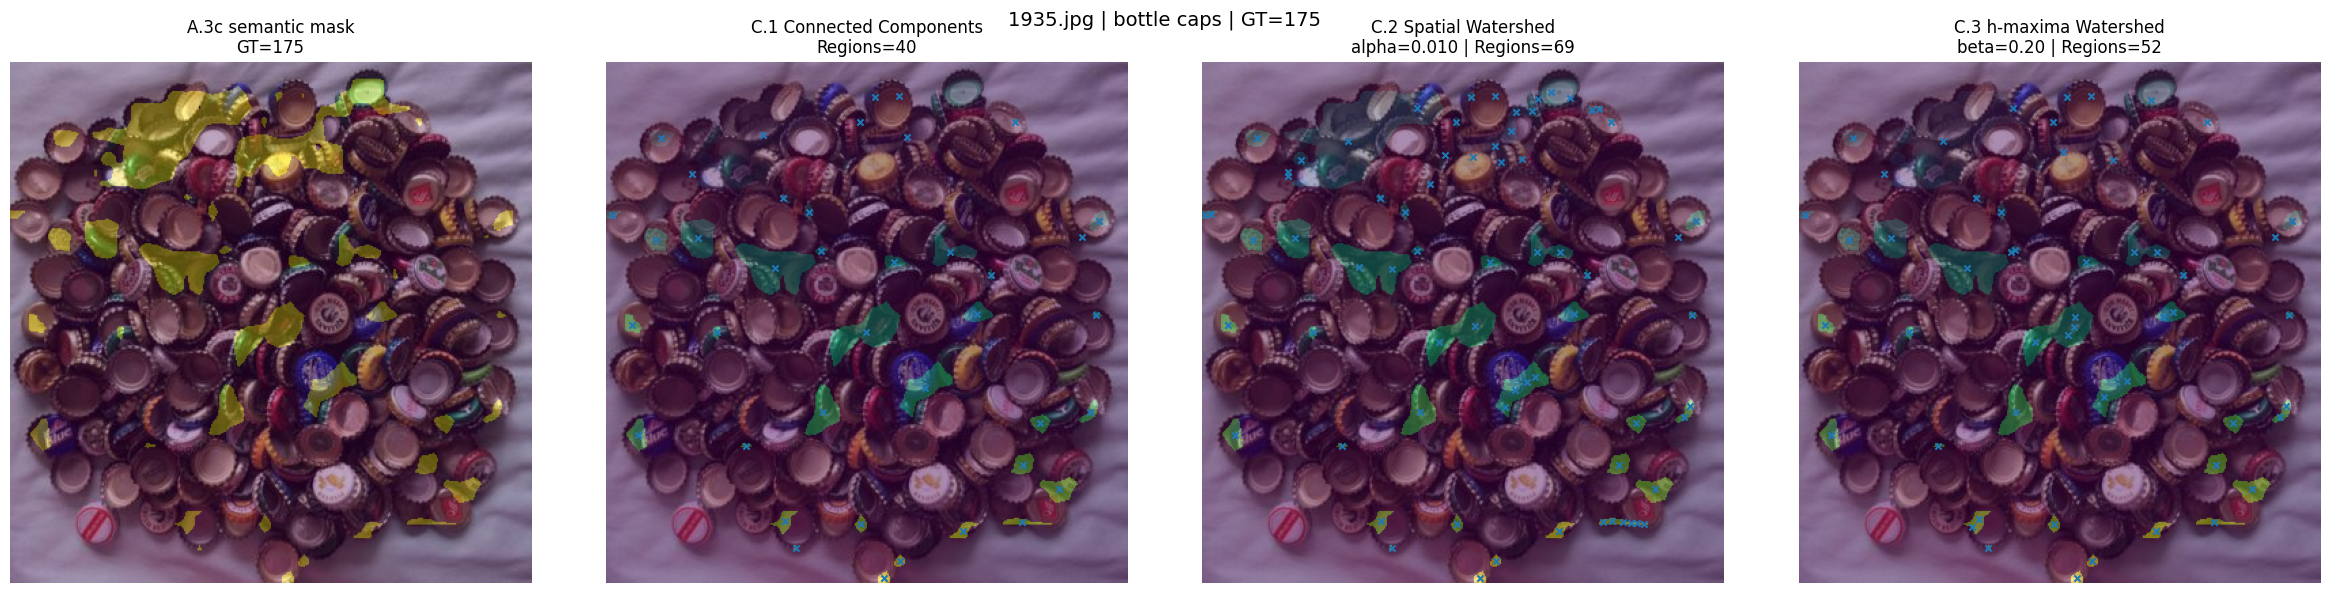

In [87]:
# ------------------------------------------------------------
# Step 10C.5 — Visualise C.1 / C.2 / C.3
# ------------------------------------------------------------

image = np.asarray(
    sample["image"].convert("RGB")
)


fig, axes = plt.subplots(
    1,
    4,
    figsize=(24, 6),
)


# ------------------------------------------------------------
# Original + A.3c
# ------------------------------------------------------------

axes[0].imshow(
    image
)

axes[0].imshow(
    a3c_mask,
    alpha=0.35,
)

axes[0].set_title(
    f"A.3c semantic mask\n"
    f"GT={gt_count}"
)

axes[0].axis("off")


# ------------------------------------------------------------
# C.1
# ------------------------------------------------------------

axes[1].imshow(
    image
)

axes[1].imshow(
    c1_result[
        "labelled_regions"
    ],
    alpha=0.45,
)

points = c1_result[
    "points"
]

if len(points) > 0:

    axes[1].scatter(
        points[:, 0],
        points[:, 1],
        s=20,
        marker="x",
    )

axes[1].set_title(
    f"C.1 Connected Components\n"
    f"Regions={c1_result['num_regions']}"
)

axes[1].axis("off")


# ------------------------------------------------------------
# C.2
# ------------------------------------------------------------

axes[2].imshow(
    image
)

axes[2].imshow(
    c2_result[
        "labelled_regions"
    ],
    alpha=0.45,
)

points = c2_result[
    "points"
]

if len(points) > 0:

    axes[2].scatter(
        points[:, 0],
        points[:, 1],
        s=20,
        marker="x",
    )

axes[2].set_title(
    f"C.2 Spatial Watershed\n"
    f"alpha=0.010 | "
    f"Regions={c2_result['num_regions']}"
)

axes[2].axis("off")


# ------------------------------------------------------------
# C.3
# ------------------------------------------------------------

axes[3].imshow(
    image
)

axes[3].imshow(
    c3_result[
        "labelled_regions"
    ],
    alpha=0.45,
)

points = c3_result[
    "points"
]

if len(points) > 0:

    axes[3].scatter(
        points[:, 0],
        points[:, 1],
        s=20,
        marker="x",
    )

axes[3].set_title(
    f"C.3 h-maxima Watershed\n"
    f"beta=0.20 | "
    f"Regions={c3_result['num_regions']}"
)

axes[3].axis("off")


fig.suptitle(
    f"{TEST_IMAGE_ID} | "
    f"{category} | "
    f"GT={gt_count}",
    fontsize=14,
)

plt.tight_layout()

plt.show()

## Step 10D — Full Group-C experiment sweep

The Group-C configurations are frozen before evaluation.

Fixed upstream:
- SAN cached scores
- A.3c: 90th-percentile threshold
- Group B: no binary-mask post-processing

Group-C variants:
- C.1: ordinary connected components
- C.2a–c: spatial watershed with α = 0.005, 0.010, 0.020
- C.3a–c: h-maxima watershed with β = 0.10, 0.20, 0.30

Fixed downstream:
- one geometric centroid per resulting region
- proxy count = number of regions/reference points

In [88]:
# ============================================================
# Step 10D.1 — Freeze Group-C experiment configurations
# ============================================================

GROUP_C_CONFIGS = [

    # --------------------------------------------------------
    # C.1 — Baseline connected components
    # --------------------------------------------------------

    {
        "experiment_id": "B1.C.1",
        "name": "connected_components",
        "strategy": "connected_components",
        "kwargs": {},
    },

    # --------------------------------------------------------
    # C.2 — Spatial-separation watershed
    # --------------------------------------------------------

    {
        "experiment_id": "B1.C.2a",
        "name": "watershed_spatial_alpha_0.005",
        "strategy": "watershed_spatial",
        "kwargs": {
            "alpha": 0.005,
        },
    },

    {
        "experiment_id": "B1.C.2b",
        "name": "watershed_spatial_alpha_0.010",
        "strategy": "watershed_spatial",
        "kwargs": {
            "alpha": 0.010,
        },
    },

    {
        "experiment_id": "B1.C.2c",
        "name": "watershed_spatial_alpha_0.020",
        "strategy": "watershed_spatial",
        "kwargs": {
            "alpha": 0.020,
        },
    },

    # --------------------------------------------------------
    # C.3 — Component-relative h-maxima watershed
    # --------------------------------------------------------

    {
        "experiment_id": "B1.C.3a",
        "name": "watershed_hmax_beta_0.10",
        "strategy": "watershed_hmax",
        "kwargs": {
            "beta": 0.10,
        },
    },

    {
        "experiment_id": "B1.C.3b",
        "name": "watershed_hmax_beta_0.20",
        "strategy": "watershed_hmax",
        "kwargs": {
            "beta": 0.20,
        },
    },

    {
        "experiment_id": "B1.C.3c",
        "name": "watershed_hmax_beta_0.30",
        "strategy": "watershed_hmax",
        "kwargs": {
            "beta": 0.30,
        },
    },
]


print(
    "Number of Group-C configurations:",
    len(GROUP_C_CONFIGS)
)

for config in GROUP_C_CONFIGS:

    print(
        config["experiment_id"],
        config["name"],
        config["kwargs"],
    )

Number of Group-C configurations: 7
B1.C.1 connected_components {}
B1.C.2a watershed_spatial_alpha_0.005 {'alpha': 0.005}
B1.C.2b watershed_spatial_alpha_0.010 {'alpha': 0.01}
B1.C.2c watershed_spatial_alpha_0.020 {'alpha': 0.02}
B1.C.3a watershed_hmax_beta_0.10 {'beta': 0.1}
B1.C.3b watershed_hmax_beta_0.20 {'beta': 0.2}
B1.C.3c watershed_hmax_beta_0.30 {'beta': 0.3}


In [89]:
# ============================================================
# Step 10D.2 — Group-C experiment runner
# ============================================================

import pandas as pd
import time

from tqdm.auto import tqdm


def run_group_c_experiment(
    dev_df,
    strategy,
    **strategy_kwargs,
):
    """
    Run one Group-C configuration over the frozen
    FSC-147 dev100 subset.

    Fixed upstream:
        SAN cached output
        A.3c percentile-90 semantic mask
        no Group-B mask processing

    Variable:
        Group-C region handling / watershed strategy

    Fixed downstream:
        one geometric centroid per resulting region
        proxy count = number of regions
    """

    rows = []

    start_time = time.perf_counter()

    for _, row in tqdm(
        dev_df.iterrows(),
        total=len(dev_df),
        desc=f"Running Group C: {strategy}",
    ):

        image_id = row[
            "image_id"
        ]

        cached = load_san_cache(
            image_id
        )

        # ----------------------------------------------------
        # Fixed Group-A winner: A.3c
        # ----------------------------------------------------

        mask, mask_info = (
            make_semantic_mask(
                cached["target_score"],
                cached["background_score"],
                strategy="percentile",
                percentile=90,
            )
        )

        # ----------------------------------------------------
        # Group-C region handling
        # ----------------------------------------------------

        region_result = (
            extract_group_c_regions(
                mask,
                strategy=strategy,
                **strategy_kwargs,
            )
        )

        gt_count = int(
            row["gt_count"]
        )

        pred_count = int(
            region_result[
                "num_regions"
            ]
        )

        error = (
            pred_count
            - gt_count
        )

        # ----------------------------------------------------
        # Diagnostics that differ slightly between C.1/C.2/C.3
        # ----------------------------------------------------

        if strategy == "connected_components":

            original_components = int(
                region_result[
                    "num_regions"
                ]
            )

            num_markers = int(
                region_result[
                    "num_regions"
                ]
            )

            min_distance_px = None
            alpha = None
            beta = None

        elif strategy == "watershed_spatial":

            original_components = int(
                region_result[
                    "original_components"
                ]
            )

            num_markers = int(
                region_result[
                    "num_markers"
                ]
            )

            min_distance_px = int(
                region_result[
                    "min_distance_px"
                ]
            )

            alpha = float(
                region_result[
                    "parameter"
                ]
            )

            beta = None

        elif strategy == "watershed_hmax":

            original_components = int(
                region_result[
                    "original_components"
                ]
            )

            num_markers = int(
                region_result[
                    "num_markers"
                ]
            )

            min_distance_px = None
            alpha = None

            beta = float(
                region_result[
                    "parameter"
                ]
            )

        else:

            raise ValueError(
                f"Unknown Group-C strategy: "
                f"{strategy}"
            )

        # ----------------------------------------------------
        # Number of additional regions generated by splitting
        # ----------------------------------------------------

        regions_added = (
            pred_count
            - original_components
        )

        rows.append(
            {
                "image_id":
                    image_id,

                "dataset_index":
                    int(
                        row[
                            "dataset_index"
                        ]
                    ),

                "category":
                    row[
                        "category"
                    ],

                "density_stratum":
                    row[
                        "density_stratum"
                    ],

                "gt_count":
                    gt_count,

                "pred_count":
                    pred_count,

                "error":
                    error,

                "abs_error":
                    abs(error),

                # --------------------------------------------
                # Fixed A.3c semantic mask
                # --------------------------------------------

                "foreground_pixels":
                    int(
                        mask.sum()
                    ),

                "foreground_fraction":
                    float(
                        mask.mean()
                    ),

                "mask_threshold":
                    mask_info.get(
                        "threshold"
                    ),

                # --------------------------------------------
                # Group-C diagnostics
                # --------------------------------------------

                "original_components":
                    original_components,

                "num_markers":
                    num_markers,

                "num_regions":
                    pred_count,

                "num_reference_points":
                    int(
                        region_result[
                            "num_points"
                        ]
                    ),

                "regions_added":
                    regions_added,

                # --------------------------------------------
                # Configuration
                # --------------------------------------------

                "region_strategy":
                    strategy,

                "alpha":
                    alpha,

                "beta":
                    beta,

                "min_distance_px":
                    min_distance_px,
            }
        )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    results_df = pd.DataFrame(
        rows
    )

    return (
        results_df,
        elapsed_time,
    )

In [90]:
# ============================================================
# Step 10D.3 — Run complete Group-C experiment sweep
# ============================================================

group_c_results = {}


for config in GROUP_C_CONFIGS:

    experiment_id = config[
        "experiment_id"
    ]

    name = config[
        "name"
    ]

    strategy = config[
        "strategy"
    ]

    strategy_kwargs = config[
        "kwargs"
    ]

    print(
        "\n"
        + "=" * 72
    )

    print(
        experiment_id,
        "—",
        name,
    )

    print(
        "=" * 72
    )

    results_df, runtime = (
        run_group_c_experiment(
            fsc147_dev_100_df,
            strategy=strategy,
            **strategy_kwargs,
        )
    )

    group_c_results[
        experiment_id
    ] = {
        "config":
            config,

        "results_df":
            results_df,

        "runtime":
            runtime,
    }

    # --------------------------------------------------------
    # Quick execution diagnostics only
    # Do NOT rank/select yet.
    # --------------------------------------------------------

    print(
        f"Runtime: "
        f"{runtime:.3f}s"
    )

    print(
        "Sum GT:",
        int(
            results_df[
                "gt_count"
            ].sum()
        ),
    )

    print(
        "Sum predictions:",
        int(
            results_df[
                "pred_count"
            ].sum()
        ),
    )

    print(
        "Original components:",
        int(
            results_df[
                "original_components"
            ].sum()
        ),
    )

    print(
        "Regions added by splitting:",
        int(
            results_df[
                "regions_added"
            ].sum()
        ),
    )

    print(
        "Images with splitting:",
        int(
            (
                results_df[
                    "regions_added"
                ]
                > 0
            ).sum()
        ),
        "/",
        len(results_df),
    )


B1.C.1 — connected_components


Running Group C: connected_components:   0%|          | 0/100 [00:00<?, ?it/s]

Runtime: 1.392s
Sum GT: 10045
Sum predictions: 2554
Original components: 2554
Regions added by splitting: 0
Images with splitting: 0 / 100

B1.C.2a — watershed_spatial_alpha_0.005


Running Group C: watershed_spatial:   0%|          | 0/100 [00:00<?, ?it/s]

Runtime: 57.834s
Sum GT: 10045
Sum predictions: 11295
Original components: 2554
Regions added by splitting: 8741
Images with splitting: 100 / 100

B1.C.2b — watershed_spatial_alpha_0.010


...

Runtime: 260.725s
Sum GT: 10045
Sum predictions: 3693
Original components: 2554
Regions added by splitting: 1139
Images with splitting: 98 / 100

B1.C.3b — watershed_hmax_beta_0.20


Running Group C: watershed_hmax:   0%|          | 0/100 [00:00<?, ?it/s]

Runtime: 263.741s
Sum GT: 10045
Sum predictions: 3315
Original components: 2554
Regions added by splitting: 761
Images with splitting: 97 / 100

B1.C.3c — watershed_hmax_beta_0.30


Running Group C: watershed_hmax:   0%|          | 0/100 [00:00<?, ?it/s]

Runtime: 261.560s
Sum GT: 10045
Sum predictions: 3123
Original components: 2554
Regions added by splitting: 569
Images with splitting: 91 / 100


## Step 10E — Group-C evaluation and ranking

Evaluate the seven frozen Group-C configurations on the same FSC-147
dev100 subset.

Primary evaluation:
- Overall MAE
- Overall RMSE

Diagnostic evaluation:
- Mean signed error
- Under / exact / over counts
- Total predicted count
- S1–S6 MAE and RMSE
- Amount of watershed splitting

No parameter range expansion is performed until the initial frozen
C.2 and C.3 grids have been evaluated.

In [91]:
# ============================================================
# Step 10E.1 — Evaluate all Group-C configurations
# ============================================================

group_c_evaluations = {}


for config in GROUP_C_CONFIGS:

    experiment_id = config["experiment_id"]

    results_df = (
        group_c_results[
            experiment_id
        ]["results_df"]
    )

    runtime = (
        group_c_results[
            experiment_id
        ]["runtime"]
    )

    evaluation_df = (
        evaluate_by_density_stratum(
            results_df
        )
    )

    group_c_evaluations[
        experiment_id
    ] = {
        "evaluation_df":
            evaluation_df,

        "runtime":
            runtime,
    }

    print(
        "\n",
        "=" * 72
    )

    print(
        experiment_id,
        "—",
        config["name"]
    )

    print(
        "=" * 72
    )

    display(
        evaluation_df
    )


B1.C.1 — connected_components


,scope,n_images,mae,rmse,mean_signed_error,undercount,exact,overcount,sum_gt,sum_pred
0,Overall,100,79.67,263.541363,-74.91,68,5,27,10045,2554
1,S1_0_20,20,5.25,7.010706,2.25,7,3,10,195,240
2,S2_20_40,20,8.30,10.894953,3.60,11,0,9,320,392
3,S3_40_60,20,11.20,13.989282,-6.80,11,1,8,537,401
4,S4_60_80,20,26.50,30.664312,-26.50,19,1,0,1096,566
5,S5_80_95,10,74.60,83.587080,-74.60,10,0,0,1211,465
6,S6_95_100,10,619.60,827.614645,-619.60,10,0,0,6686,490



B1.C.2a — watershed_spatial_alpha_0.005


,scope,n_images,mae,rmse,mean_signed_error,undercount,exact,overcount,sum_gt,sum_pred
0,Overall,100,123.88,259.191242,12.5,18,0,82,10045,11295
1,S1_0_20,20,63.90,78.523245,63.9,0,0,20,195,1473
2,S2_20_40,20,98.80,119.525729,98.8,0,0,20,320,2296
3,S3_40_60,20,95.80,105.310968,93.6,2,0,18,537,2409
4,S4_60_80,20,55.30,64.771136,55.0,1,0,19,1096,2196
5,S5_80_95,10,81.60,97.561263,32.0,5,0,5,1211,1531
6,S6_95_100,10,529.60,768.639577,-529.6,10,0,0,6686,1390



B1.C.2b — watershed_spatial_alpha_0.010


...

,scope,n_images,mae,rmse,mean_signed_error,undercount,exact,overcount,sum_gt,sum_pred
0,Overall,100,78.02,260.271243,-63.52,48,5,47,10045,3693
1,S1_0_20,20,11.30,15.109600,9.80,2,3,15,195,391
2,S2_20_40,20,17.05,21.367031,15.25,4,1,15,320,625
3,S3_40_60,20,13.00,14.518953,4.20,7,0,13,537,621
4,S4_60_80,20,16.65,22.500000,-15.35,16,1,3,1096,789
5,S5_80_95,10,57.80,72.816207,-56.60,9,0,1,1211,645
6,S6_95_100,10,606.40,818.110750,-606.40,10,0,0,6686,622



B1.C.3b — watershed_hmax_beta_0.20


,scope,n_images,mae,rmse,mean_signed_error,undercount,exact,overcount,sum_gt,sum_pred
0,Overall,100,77.94,261.108407,-67.30,54,3,43,10045,3315
1,S1_0_20,20,8.55,11.478240,6.65,4,2,14,195,328
2,S2_20_40,20,13.30,16.661332,11.10,5,0,15,320,542
3,S3_40_60,20,12.30,14.064139,0.70,8,0,12,537,551
4,S4_60_80,20,20.20,25.622256,-19.60,18,0,2,1096,704
5,S5_80_95,10,60.50,74.737541,-60.50,9,1,0,1211,606
6,S6_95_100,10,610.20,820.769761,-610.20,10,0,0,6686,584



B1.C.3c — watershed_hmax_beta_0.30


,scope,n_images,mae,rmse,mean_signed_error,undercount,exact,overcount,sum_gt,sum_pred
0,Overall,100,77.78,261.562191,-69.22,56,5,39,10045,3123
1,S1_0_20,20,7.20,9.813256,5.10,4,3,13,195,297
2,S2_20_40,20,11.30,14.117365,8.50,6,0,14,320,490
3,S3_40_60,20,11.35,13.661991,-0.95,8,2,10,537,518
4,S4_60_80,20,21.60,26.942531,-21.30,18,0,2,1096,670
5,S5_80_95,10,62.50,76.640068,-62.50,10,0,0,1211,586
6,S6_95_100,10,612.40,822.105711,-612.40,10,0,0,6686,562


In [92]:
# ============================================================
# Step 10E.2 — Build Group-C comparison summary
# ============================================================

summary_rows = []


for config in GROUP_C_CONFIGS:

    experiment_id = config[
        "experiment_id"
    ]

    results_df = (
        group_c_results[
            experiment_id
        ]["results_df"]
    )

    runtime = (
        group_c_results[
            experiment_id
        ]["runtime"]
    )

    evaluation_df = (
        group_c_evaluations[
            experiment_id
        ]["evaluation_df"]
    )

    # --------------------------------------------------------
    # Existing evaluation function uses "scope"
    # --------------------------------------------------------

    eval_lookup = (
        evaluation_df
        .set_index("scope")
    )

    overall = eval_lookup.loc[
        "Overall"
    ]

    summary_row = {
        "experiment_id":
            experiment_id,

        "name":
            config["name"],

        "strategy":
            config["strategy"],

        "alpha":
            config["kwargs"].get(
                "alpha"
            ),

        "beta":
            config["kwargs"].get(
                "beta"
            ),

        # ----------------------------------------------------
        # Overall counting metrics
        # ----------------------------------------------------

        "Overall_MAE":
            float(
                overall["mae"]
            ),

        "Overall_RMSE":
            float(
                overall["rmse"]
            ),

        "Overall_mean_signed_error":
            float(
                overall[
                    "mean_signed_error"
                ]
            ),

        "Overall_undercount":
            int(
                overall["undercount"]
            ),

        "Overall_exact":
            int(
                overall["exact"]
            ),

        "Overall_overcount":
            int(
                overall["overcount"]
            ),

        "Overall_sum_gt":
            int(
                overall["sum_gt"]
            ),

        "Overall_sum_pred":
            int(
                overall["sum_pred"]
            ),

        # ----------------------------------------------------
        # Splitting diagnostics
        # ----------------------------------------------------

        "regions_added_total":
            int(
                results_df[
                    "regions_added"
                ].sum()
            ),

        "images_with_splitting":
            int(
                (
                    results_df[
                        "regions_added"
                    ] > 0
                ).sum()
            ),

        "runtime_sec":
            float(
                runtime
            ),
    }

    # --------------------------------------------------------
    # S1–S6 metrics
    # --------------------------------------------------------

    for scope in [
        "S1_0_20",
        "S2_20_40",
        "S3_40_60",
        "S4_60_80",
        "S5_80_95",
        "S6_95_100",
    ]:

        scope_metrics = (
            eval_lookup.loc[
                scope
            ]
        )

        summary_row[
            f"{scope}_MAE"
        ] = float(
            scope_metrics["mae"]
        )

        summary_row[
            f"{scope}_RMSE"
        ] = float(
            scope_metrics["rmse"]
        )

    summary_rows.append(
        summary_row
    )


group_c_summary_df = pd.DataFrame(
    summary_rows
)


display(
    group_c_summary_df
)

,experiment_id,name,strategy,alpha,beta,Overall_MAE,Overall_RMSE,Overall_mean_signed_error,Overall_undercount,Overall_exact,...,S2_20_40_MAE,S2_20_40_RMSE,S3_40_60_MAE,S3_40_60_RMSE,S4_60_80_MAE,S4_60_80_RMSE,S5_80_95_MAE,S5_80_95_RMSE,S6_95_100_MAE,S6_95_100_RMSE
0,B1.C.1,connected_components,connected_components,NaN,NaN,79.67,263.541363,-74.91,68,5,...,8.30,10.894953,11.20,13.989282,26.50,30.664312,74.6,83.587080,619.6,827.614645
1,B1.C.2a,watershed_spatial_alpha_0.005,watershed_spatial,0.005,NaN,123.88,259.191242,12.50,18,0,...,98.80,119.525729,95.80,105.310968,55.30,64.771136,81.6,97.561263,529.6,768.639577
2,B1.C.2b,watershed_spatial_alpha_0.010,watershed_spatial,0.010,NaN,88.79,257.512893,-39.71,26,2,...,42.50,53.665631,37.25,41.357587,17.60,21.945387,51.4,64.947671,585.2,803.849364
3,B1.C.2c,watershed_spatial_alpha_0.020,watershed_spatial,0.020,NaN,80.08,260.130006,-58.74,42,0,...,22.00,28.358420,16.90,18.316659,14.25,19.040746,58.5,71.978469,604.7,817.117066
4,B1.C.3a,watershed_hmax_beta_0.10,watershed_hmax,NaN,0.1,78.02,260.271243,-63.52,48,5,...,17.05,21.367031,13.00,14.518953,16.65,22.500000,57.8,72.816207,606.4,818.110750
5,B1.C.3b,watershed_hmax_beta_0.20,watershed_hmax,NaN,0.2,77.94,261.108407,-67.30,54,3,...,13.30,16.661332,12.30,14.064139,20.20,25.622256,60.5,74.737541,610.2,820.769761
6,B1.C.3c,watershed_hmax_beta_0.30,watershed_hmax,NaN,0.3,77.78,261.562191,-69.22,56,5,...,11.30,14.117365,11.35,13.661991,21.60,26.942531,62.5,76.640068,612.4,822.105711


In [93]:
# ============================================================
# Step 10E.3 — Rank Group-C configurations
# ============================================================

group_c_ranking_df = (
    group_c_summary_df
    .sort_values(
        by=[
            "Overall_MAE",
            "Overall_RMSE",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .reset_index(
        drop=True
    )
)


ranking_columns = [

    "experiment_id",
    "name",

    "Overall_MAE",
    "Overall_RMSE",
    "Overall_mean_signed_error",

    "Overall_undercount",
    "Overall_exact",
    "Overall_overcount",

    "Overall_sum_gt",
    "Overall_sum_pred",

    "regions_added_total",
    "images_with_splitting",

    "runtime_sec",
]


display(
    group_c_ranking_df[
        ranking_columns
    ]
)

,experiment_id,name,Overall_MAE,Overall_RMSE,Overall_mean_signed_error,Overall_undercount,Overall_exact,Overall_overcount,Overall_sum_gt,Overall_sum_pred,regions_added_total,images_with_splitting,runtime_sec
0,B1.C.3c,watershed_hmax_beta_0.30,77.78,261.562191,-69.22,56,5,39,10045,3123,569,91,261.560193
1,B1.C.3b,watershed_hmax_beta_0.20,77.94,261.108407,-67.30,54,3,43,10045,3315,761,97,263.741340
2,B1.C.3a,watershed_hmax_beta_0.10,78.02,260.271243,-63.52,48,5,47,10045,3693,1139,98,260.724942
3,B1.C.1,connected_components,79.67,263.541363,-74.91,68,5,27,10045,2554,0,0,1.392274
4,B1.C.2c,watershed_spatial_alpha_0.020,80.08,260.130006,-58.74,42,0,58,10045,4171,1617,99,54.660917
5,B1.C.2b,watershed_spatial_alpha_0.010,88.79,257.512893,-39.71,26,2,72,10045,6074,3520,99,56.786217
6,B1.C.2a,watershed_spatial_alpha_0.005,123.88,259.191242,12.50,18,0,82,10045,11295,8741,100,57.833631


In [94]:
# ============================================================
# Step 10E.4 — Compare S1–S6 performance
# ============================================================

density_columns = [

    "experiment_id",

    "Overall_MAE",
    "Overall_RMSE",

    "S1_0_20_MAE",
    "S1_0_20_RMSE",

    "S2_20_40_MAE",
    "S2_20_40_RMSE",

    "S3_40_60_MAE",
    "S3_40_60_RMSE",

    "S4_60_80_MAE",
    "S4_60_80_RMSE",

    "S5_80_95_MAE",
    "S5_80_95_RMSE",

    "S6_95_100_MAE",
    "S6_95_100_RMSE",
]


group_c_density_df = (
    group_c_summary_df
    .sort_values(
        by="Overall_MAE",
        ascending=True,
    )
    [density_columns]
    .reset_index(
        drop=True
    )
)


display(
    group_c_density_df
)

,experiment_id,Overall_MAE,Overall_RMSE,S1_0_20_MAE,S1_0_20_RMSE,S2_20_40_MAE,S2_20_40_RMSE,S3_40_60_MAE,S3_40_60_RMSE,S4_60_80_MAE,S4_60_80_RMSE,S5_80_95_MAE,S5_80_95_RMSE,S6_95_100_MAE,S6_95_100_RMSE
0,B1.C.3c,77.78,261.562191,7.20,9.813256,11.30,14.117365,11.35,13.661991,21.60,26.942531,62.5,76.640068,612.4,822.105711
1,B1.C.3b,77.94,261.108407,8.55,11.478240,13.30,16.661332,12.30,14.064139,20.20,25.622256,60.5,74.737541,610.2,820.769761
2,B1.C.3a,78.02,260.271243,11.30,15.109600,17.05,21.367031,13.00,14.518953,16.65,22.500000,57.8,72.816207,606.4,818.110750
3,B1.C.1,79.67,263.541363,5.25,7.010706,8.30,10.894953,11.20,13.989282,26.50,30.664312,74.6,83.587080,619.6,827.614645
4,B1.C.2c,80.08,260.130006,15.65,20.130822,22.00,28.358420,16.90,18.316659,14.25,19.040746,58.5,71.978469,604.7,817.117066
5,B1.C.2b,88.79,257.512893,28.30,36.005555,42.50,53.665631,37.25,41.357587,17.60,21.945387,51.4,64.947671,585.2,803.849364
6,B1.C.2a,123.88,259.191242,63.90,78.523245,98.80,119.525729,95.80,105.310968,55.30,64.771136,81.6,97.561263,529.6,768.639577


In [95]:
# ============================================================
# Step 10E.5a — C.2 alpha trend
# ============================================================

c2_trend_df = (
    group_c_summary_df[
        group_c_summary_df[
            "strategy"
        ]
        == "watershed_spatial"
    ]
    [
        [
            "experiment_id",
            "alpha",
            "Overall_MAE",
            "Overall_RMSE",
            "Overall_mean_signed_error",
            "Overall_sum_pred",
            "regions_added_total",
        ]
    ]
    .sort_values(
        "alpha"
    )
)


display(
    c2_trend_df
)

,experiment_id,alpha,Overall_MAE,Overall_RMSE,Overall_mean_signed_error,Overall_sum_pred,regions_added_total
1,B1.C.2a,0.005,123.88,259.191242,12.50,11295,8741
2,B1.C.2b,0.010,88.79,257.512893,-39.71,6074,3520
3,B1.C.2c,0.020,80.08,260.130006,-58.74,4171,1617


In [96]:
# ============================================================
# Step 10E.5b — C.3 beta trend
# ============================================================

c3_trend_df = (
    group_c_summary_df[
        group_c_summary_df[
            "strategy"
        ]
        == "watershed_hmax"
    ]
    [
        [
            "experiment_id",
            "beta",
            "Overall_MAE",
            "Overall_RMSE",
            "Overall_mean_signed_error",
            "Overall_sum_pred",
            "regions_added_total",
        ]
    ]
    .sort_values(
        "beta"
    )
)


display(
    c3_trend_df
)

,experiment_id,beta,Overall_MAE,Overall_RMSE,Overall_mean_signed_error,Overall_sum_pred,regions_added_total
4,B1.C.3a,0.1,78.02,260.271243,-63.52,3693,1139
5,B1.C.3b,0.2,77.94,261.108407,-67.30,3315,761
6,B1.C.3c,0.3,77.78,261.562191,-69.22,3123,569


In [97]:
# ============================================================
# Step 10E.6 — Save Group-C results
# ============================================================

GROUP_C_RESULTS_DIR = (
    B1_RESULTS_ROOT
    / "Group_C"
)

GROUP_C_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Save each per-image result table
# ------------------------------------------------------------

for config in GROUP_C_CONFIGS:

    experiment_id = config[
        "experiment_id"
    ]

    safe_id = (
        experiment_id
        .replace(".", "_")
    )

    results_df = (
        group_c_results[
            experiment_id
        ]["results_df"]
    )

    results_df.to_csv(
        GROUP_C_RESULTS_DIR
        / f"{safe_id}_dev100_per_image.csv",
        index=False,
    )


# ------------------------------------------------------------
# Save summary and ranking
# ------------------------------------------------------------

group_c_summary_df.to_csv(
    GROUP_C_RESULTS_DIR
    / "B1_Group_C_dev100_summary.csv",
    index=False,
)


group_c_ranking_df.to_csv(
    GROUP_C_RESULTS_DIR
    / "B1_Group_C_dev100_ranking.csv",
    index=False,
)


print(
    "Saved Group-C results to:"
)

print(
    GROUP_C_RESULTS_DIR
)

Saved Group-C results to:
/content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments/Group_C


# **Group C decision**

Group C reveals a clear density-dependent trade-off.

- **C.1 (connected components)** gives the lowest MAE in S1–S3 and is therefore retained as the **region-based reference configuration**. It preserves strong performance in sparse and moderate-density scenes without introducing watershed over-splitting.
- Increasingly aggressive watershed splitting becomes more useful as density increases:
  - C.2c gives the lowest MAE in S4,
  - C.2b in S5,
  - C.2a in S6.
- However, the same aggressive splitting substantially degrades sparse-scene performance and therefore cannot be adopted as a single global strategy.

C.3 provides a more conservative compromise and C.3c achieves the lowest overall MAE (77.78), but it does not outperform C.1 in S1–S3 and provides only limited recovery in the densest scenes.

**Decision:** retain **C.1 as the primary region-based evidence**, with **C.2b retained as a complementary dense-recovery operating point**. C.3c remains an important ablation result demonstrating the benefit of conservative splitting, but is not selected solely because it has the lowest overall MAE.

The results also suggest that a single fixed region-splitting rule is unlikely to be optimal across object densities. Any future adaptive use of splitting must rely on observable image/model evidence rather than ground-truth density strata.

This motivates Group D to investigate whether activation-based semantic evidence provides complementary instance information that is unavailable from thresholded semantic regions alone.

In [98]:
# ============================================================
# Step 10F — C2c localisation diagnostic with canonical matcher
# ============================================================
#
# Purpose
# -------
# Re-evaluate retained C2c using the SAME canonical one-to-one
# matcher now frozen in Group D.
#
# Canonical localisation tolerance:
#
#   radius_px = max(1, round(0.03 * min(H, W)))
#
# Matching objective:
#   1. maximise number of matches within radius_px
#   2. among maximum-cardinality matchings,
#      minimise total Euclidean distance
#
# IMPORTANT
# ---------
# This does NOT change:
#   - A3c
#   - C2c
#   - reference-point generation
#   - predicted counts
#
# It changes only the localisation evaluation so that
# Group C and Group D use the same protocol.
# ============================================================

import numpy as np
import pandas as pd

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from tqdm.auto import tqdm


# ------------------------------------------------------------
# Frozen settings
# ------------------------------------------------------------

A3C_PERCENTILE = 90
POINT_TOLERANCE_FRAC = 0.03
C2C_ALPHA = 0.020

DENSITY_ORDER = [
    "S1_0_20",
    "S2_20_40",
    "S3_40_60",
    "S4_60_80",
    "S5_80_95",
    "S6_95_100",
]


# ------------------------------------------------------------
# Canonical Group-D matcher
#
# This is the same implementation used in the final
# Group-D notebook.
# ------------------------------------------------------------

def match_points_one_to_one_efficient(
    pred_xy,
    gt_xy,
    radius_px,
):
    """
    Memory-efficient one-to-one matching.

    Objective:
        1. maximise number of matches within radius_px
        2. among maximum-cardinality matchings,
           minimise total Euclidean distance

    Each predicted point and each GT point can be matched
    at most once.
    """

    pred_xy = np.asarray(
        pred_xy,
        dtype=np.float32,
    ).reshape(-1, 2)

    gt_xy = np.asarray(
        gt_xy,
        dtype=np.float32,
    ).reshape(-1, 2)

    n_pred = len(pred_xy)
    n_gt = len(gt_xy)

    # --------------------------------------------------------
    # Empty cases
    # --------------------------------------------------------

    if n_pred == 0 or n_gt == 0:

        return {
            "matches": np.empty(
                (0, 2),
                dtype=np.int64,
            ),

            "distances": np.empty(
                (0,),
                dtype=np.float32,
            ),

            "tp": 0,
            "fp": n_pred,
            "fn": n_gt,
        }

    # --------------------------------------------------------
    # Pairwise distances
    # --------------------------------------------------------

    dist_matrix = cdist(
        pred_xy,
        gt_xy,
        metric="euclidean",
    )

    valid = (
        dist_matrix <= radius_px
    )

    # --------------------------------------------------------
    # Lexicographic objective
    # --------------------------------------------------------

    max_possible_matches = min(
        n_pred,
        n_gt,
    )

    unmatched_cost = (
        (max_possible_matches + 1)
        * (float(radius_px) + 1.0)
    )

    forbidden_cost = (
        unmatched_cost
        * (max_possible_matches + 2)
    )

    # --------------------------------------------------------
    # Rectangular assignment matrix
    #
    # Columns:
    #   0 ... n_gt-1 = real GT points
    #   n_gt ...      = dummy unmatched columns
    # --------------------------------------------------------

    cost_matrix = np.full(
        (
            n_pred,
            n_gt + n_pred,
        ),
        forbidden_cost,
        dtype=np.float64,
    )

    # Real valid prediction -> GT costs
    real_costs = cost_matrix[
        :,
        :n_gt,
    ]

    real_costs[valid] = (
        dist_matrix[valid]
    )

    # Any prediction may remain unmatched
    cost_matrix[
        :,
        n_gt:
    ] = unmatched_cost

    # --------------------------------------------------------
    # Hungarian assignment
    # --------------------------------------------------------

    row_ind, col_ind = (
        linear_sum_assignment(
            cost_matrix
        )
    )

    # Real prediction -> GT assignments only
    real_match_mask = (
        col_ind < n_gt
    )

    pred_idx = row_ind[
        real_match_mask
    ]

    gt_idx = col_ind[
        real_match_mask
    ]

    matched_distances = (
        dist_matrix[
            pred_idx,
            gt_idx,
        ]
    )

    # Safety check
    accepted = (
        matched_distances
        <= radius_px
    )

    pred_idx = pred_idx[
        accepted
    ]

    gt_idx = gt_idx[
        accepted
    ]

    matched_distances = (
        matched_distances[
            accepted
        ]
    )

    tp = len(pred_idx)
    fp = n_pred - tp
    fn = n_gt - tp

    if tp > 0:

        matches = np.column_stack(
            [
                pred_idx,
                gt_idx,
            ]
        ).astype(
            np.int64
        )

    else:

        matches = np.empty(
            (0, 2),
            dtype=np.int64,
        )

    return {
        "matches": matches,

        "distances":
            matched_distances.astype(
                np.float32
            ),

        "tp": tp,
        "fp": fp,
        "fn": fn,
    }


# ------------------------------------------------------------
# Canonical metric wrapper
# ------------------------------------------------------------

def canonical_point_metrics(
    pred_xy,
    gt_xy,
    width,
    height,
):
    """
    Evaluate predicted points using the frozen Group-D
    one-to-one localisation protocol.
    """

    pred_xy = np.asarray(
        pred_xy,
        dtype=np.float32,
    ).reshape(-1, 2)

    gt_xy = np.asarray(
        gt_xy,
        dtype=np.float32,
    ).reshape(-1, 2)

    radius_px = max(
        1,
        int(
            round(
                POINT_TOLERANCE_FRAC
                * min(
                    int(height),
                    int(width),
                )
            )
        ),
    )

    match_result = (
        match_points_one_to_one_efficient(
            pred_xy,
            gt_xy,
            radius_px,
        )
    )

    tp = int(
        match_result["tp"]
    )

    fp = int(
        match_result["fp"]
    )

    fn = int(
        match_result["fn"]
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    f1 = (
        2.0
        * precision
        * recall
        / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "radius_px": radius_px,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


# ------------------------------------------------------------
# Re-evaluate C2c on frozen dev100
# ------------------------------------------------------------

c2c_localisation_rows = []


for _, dev_row in tqdm(
    fsc147_dev_100_df.iterrows(),
    total=len(fsc147_dev_100_df),
    desc="C2c canonical localisation",
):

    dataset_index = int(
        dev_row["dataset_index"]
    )

    image_id = str(
        dev_row["image_id"]
    )

    category = str(
        dev_row["category"]
    )

    density_stratum = str(
        dev_row["density_stratum"]
    )

    sample = (
        fsc147_val_dataset[
            dataset_index
        ]
    )

    width = int(
        sample["width"]
    )

    height = int(
        sample["height"]
    )

    gt_points_xy = np.asarray(
        get_gt_points(
            sample,
            category,
        ),
        dtype=np.float32,
    ).reshape(-1, 2)

    gt_count = len(
        gt_points_xy
    )

    # --------------------------------------------------------
    # Load frozen SAN cache
    # --------------------------------------------------------

    san_cache = (
        load_san_cache(
            image_id
        )
    )

    # --------------------------------------------------------
    # Frozen A3c semantic mask
    #
    # IMPORTANT:
    # make_semantic_mask requires BOTH target and background
    # score maps and returns (mask, info).
    # --------------------------------------------------------

    semantic_mask, semantic_info = (
        make_semantic_mask(
            san_cache["target_score"],
            san_cache["background_score"],
            strategy="percentile",
            percentile=A3C_PERCENTILE,
        )
    )

    # --------------------------------------------------------
    # Frozen C2c region extraction
    #
    # extract_group_c_regions returns a result dictionary.
    # Reference points are stored in result["points"].
    # --------------------------------------------------------

    region_result = (
        extract_group_c_regions(
            semantic_mask,
            strategy="watershed_spatial",
            alpha=C2C_ALPHA,
        )
    )

    pred_points_xy = np.asarray(
        region_result["points"],
        dtype=np.float32,
    ).reshape(-1, 2)

    pred_count = len(
        pred_points_xy
    )

    # --------------------------------------------------------
    # Canonical localisation evaluation
    # --------------------------------------------------------

    metrics = (
        canonical_point_metrics(
            pred_points_xy,
            gt_points_xy,
            width,
            height,
        )
    )

    c2c_localisation_rows.append({

        "dataset_index":
            dataset_index,

        "image_id":
            image_id,

        "category":
            category,

        "density_stratum":
            density_stratum,

        "width":
            width,

        "height":
            height,

        "gt_count":
            gt_count,

        "pred_count":
            pred_count,

        "radius_px":
            metrics["radius_px"],

        "tp":
            metrics["tp"],

        "fp":
            metrics["fp"],

        "fn":
            metrics["fn"],

        "precision":
            metrics["precision"],

        "recall":
            metrics["recall"],

        "f1":
            metrics["f1"],
    })


c2c_localisation_df = (
    pd.DataFrame(
        c2c_localisation_rows
    )
)


# ------------------------------------------------------------
# Overall macro localisation metrics
# ------------------------------------------------------------

c2c_macro_precision = (
    c2c_localisation_df[
        "precision"
    ].mean()
)

c2c_macro_recall = (
    c2c_localisation_df[
        "recall"
    ].mean()
)

c2c_macro_f1 = (
    c2c_localisation_df[
        "f1"
    ].mean()
)


print("=" * 78)
print(
    "C2c localisation diagnostic "
    "- CANONICAL Group-D matcher"
)
print("=" * 78)

print(
    f"Images           : "
    f"{len(c2c_localisation_df)}"
)

print(
    f"Tolerance        : "
    f"{POINT_TOLERANCE_FRAC:.0%} "
    f"of short side, rounded to integer px"
)

print(
    f"Macro Precision  : "
    f"{c2c_macro_precision:.4f}"
)

print(
    f"Macro Recall     : "
    f"{c2c_macro_recall:.4f}"
)

print(
    f"Macro F1         : "
    f"{c2c_macro_f1:.4f}"
)


# ------------------------------------------------------------
# Density-stratum summary
# ------------------------------------------------------------

c2c_by_density = (
    c2c_localisation_df
    .groupby(
        "density_stratum"
    )[
        [
            "precision",
            "recall",
            "f1",
        ]
    ]
    .mean()
    .reindex(
        DENSITY_ORDER
    )
    .reset_index()
)


print(
    "\nC2c localisation "
    "by density stratum:"
)

display(
    c2c_by_density.round(4)
)


# ------------------------------------------------------------
# Radius sanity
# ------------------------------------------------------------

print(
    "\nCanonical radius distribution:"
)

display(
    c2c_localisation_df[
        "radius_px"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "radius_px"
    )
    .reset_index(
        name="n_images"
    )
)


# ------------------------------------------------------------
# Final sanity
# ------------------------------------------------------------

assert (
    len(c2c_localisation_df)
    ==
    len(fsc147_dev_100_df)
)

assert (
    c2c_localisation_df[
        "pred_count"
    ]
    ==
    (
        c2c_localisation_df["tp"]
        +
        c2c_localisation_df["fp"]
    )
).all()

assert (
    c2c_localisation_df[
        "gt_count"
    ]
    ==
    (
        c2c_localisation_df["tp"]
        +
        c2c_localisation_df["fn"]
    )
).all()


print(
    "\nStep 10F complete."
)

print(
    "C2c is now evaluated using "
    "the canonical Group-D matcher."
)

C2c canonical localisation:   0%|          | 0/100 [00:00<?, ?it/s]

C2c localisation diagnostic - CANONICAL Group-D matcher
Images           : 100
Tolerance        : 3% of short side, rounded to integer px
Macro Precision  : 0.3725
Macro Recall     : 0.3860
Macro F1         : 0.3178

C2c localisation by density stratum:


,density_stratum,precision,recall,f1
0,S1_0_20,0.2003,0.4261,0.2546
1,S2_20_40,0.2477,0.4766,0.3053
2,S3_40_60,0.3332,0.4074,0.3259
3,S4_60_80,0.4902,0.3969,0.4232
4,S5_80_95,0.5208,0.3429,0.3960
5,S6_95_100,0.6612,0.1032,0.1638



Canonical radius distribution:


,radius_px,n_images
0,12,100



Step 10F complete.
C2c is now evaluated using the canonical Group-D matcher.


In [99]:
# ============================================================
# Step 10G — Final Group-C -> Group-E handoff
#              with canonical localisation evaluation
# ============================================================
#
# Purpose
# -------
# Prepare the retained region-based semantic representations
# for Group E:
#
#   C1  = ordinary 4-connected components
#   C2b = spatial watershed, alpha = 0.010
#   C2c = spatial watershed, alpha = 0.020
#
# All three use:
#   - frozen SAN cache
#   - frozen A3c percentile = 90
#   - no Group-B post-processing
#
# Localisation evaluation is harmonised with Group D:
#
#   radius_px = max(1, round(0.03 * min(H, W)))
#
# IMPORTANT
# ---------
# This cell does NOT retune or modify C1/C2b/C2c.
#
# It:
#   1. reconstructs their frozen points,
#   2. evaluates them with the canonical Group-D matcher,
#   3. checks historical COUNT reconstruction,
#   4. exports the final Group-E handoff.
# ============================================================

import json
import numpy as np
import pandas as pd

from tqdm.auto import tqdm


# ------------------------------------------------------------
# Frozen settings
# ------------------------------------------------------------

A3C_PERCENTILE = 90
POINT_TOLERANCE_FRAC = 0.03

DENSITY_ORDER = [
    "S1_0_20",
    "S2_20_40",
    "S3_40_60",
    "S4_60_80",
    "S5_80_95",
    "S6_95_100",
]


# ------------------------------------------------------------
# Retained Group-C candidates
# ------------------------------------------------------------

GROUP_C_E_CANDIDATES = {

    "C1": {
        "experiment_id":
            "B1.C.1",

        "strategy":
            "connected_components",

        "alpha":
            None,

        "description":
            "4-connected components",
    },

    "C2b": {
        "experiment_id":
            "B1.C.2b",

        "strategy":
            "watershed_spatial",

        "alpha":
            0.010,

        "description":
            "spatial watershed alpha=0.010",
    },

    "C2c": {
        "experiment_id":
            "B1.C.2c",

        "strategy":
            "watershed_spatial",

        "alpha":
            0.020,

        "description":
            "spatial watershed alpha=0.020",
    },
}


# ------------------------------------------------------------
# Helper: serialise Nx2 points safely for CSV
# ------------------------------------------------------------

def points_to_json(
    points_xy,
):

    points_xy = np.asarray(
        points_xy,
        dtype=np.float32,
    ).reshape(-1, 2)

    return json.dumps(
        [
            [
                float(x),
                float(y),
            ]
            for x, y
            in points_xy
        ]
    )


# ------------------------------------------------------------
# Confirm Step 10F canonical matcher is available
# ------------------------------------------------------------

if (
    "match_points_one_to_one_efficient"
    not in globals()
):
    raise RuntimeError(
        "Canonical matcher not found. "
        "Run replacement Step 10F first."
    )

if (
    "canonical_point_metrics"
    not in globals()
):
    raise RuntimeError(
        "canonical_point_metrics() not found. "
        "Run replacement Step 10F first."
    )


# ------------------------------------------------------------
# Generate final per-image Group-C handoff
# ------------------------------------------------------------

print("=" * 78)
print(
    "Preparing Group-C candidates "
    "for Group E"
)
print("=" * 78)


group_c_e_rows = []


for _, dev_row in tqdm(
    fsc147_dev_100_df.iterrows(),
    total=len(fsc147_dev_100_df),
    desc="Group C -> Group E",
):

    dataset_index = int(
        dev_row["dataset_index"]
    )

    image_id = str(
        dev_row["image_id"]
    )

    category = str(
        dev_row["category"]
    )

    density_stratum = str(
        dev_row["density_stratum"]
    )

    sample = (
        fsc147_val_dataset[
            dataset_index
        ]
    )

    width = int(
        sample["width"]
    )

    height = int(
        sample["height"]
    )

    gt_points_xy = np.asarray(
        get_gt_points(
            sample,
            category,
        ),
        dtype=np.float32,
    ).reshape(-1, 2)

    gt_count = len(
        gt_points_xy
    )

    # --------------------------------------------------------
    # Frozen SAN cache
    # --------------------------------------------------------

    san_cache = (
        load_san_cache(
            image_id
        )
    )

    # --------------------------------------------------------
    # Frozen A3c semantic mask
    #
    # Correct ABC interface:
    #   make_semantic_mask(
    #       target_score,
    #       background_score,
    #       strategy=...,
    #   )
    #
    # Returns:
    #   semantic_mask, semantic_info
    # --------------------------------------------------------

    semantic_mask, semantic_info = (
        make_semantic_mask(
            san_cache["target_score"],
            san_cache["background_score"],
            strategy="percentile",
            percentile=A3C_PERCENTILE,
        )
    )

    # --------------------------------------------------------
    # Generate each retained C representation
    # --------------------------------------------------------

    for (
        candidate_id,
        cfg,
    ) in GROUP_C_E_CANDIDATES.items():

        if (
            cfg["strategy"]
            ==
            "connected_components"
        ):

            region_result = (
                extract_group_c_regions(
                    semantic_mask,
                    strategy=
                        "connected_components",
                )
            )

        elif (
            cfg["strategy"]
            ==
            "watershed_spatial"
        ):

            region_result = (
                extract_group_c_regions(
                    semantic_mask,
                    strategy=
                        "watershed_spatial",
                    alpha=
                        cfg["alpha"],
                )
            )

        else:

            raise ValueError(
                "Unexpected Group-C "
                f"strategy: {cfg['strategy']}"
            )

        # ----------------------------------------------------
        # ABC region helper already stores reference points
        # as an Nx2 [x, y] array in result["points"].
        # ----------------------------------------------------

        pred_points_xy = np.asarray(
            region_result["points"],
            dtype=np.float32,
        ).reshape(-1, 2)

        pred_count = len(
            pred_points_xy
        )

        # ----------------------------------------------------
        # Canonical localisation metrics
        # ----------------------------------------------------

        metrics = (
            canonical_point_metrics(
                pred_points_xy,
                gt_points_xy,
                width,
                height,
            )
        )

        # ----------------------------------------------------
        # Count metrics
        # ----------------------------------------------------

        signed_error = (
            pred_count
            -
            gt_count
        )

        abs_error = abs(
            signed_error
        )

        squared_error = (
            signed_error ** 2
        )

        pred_gt_ratio = (
            pred_count / gt_count
            if gt_count > 0
            else np.nan
        )

        # ----------------------------------------------------
        # Store Group-E handoff row
        # ----------------------------------------------------

        group_c_e_rows.append({

            "candidate_id":
                candidate_id,

            "experiment_id":
                cfg["experiment_id"],

            "candidate_family":
                "region_based_semantic",

            "description":
                cfg["description"],

            "dataset_index":
                dataset_index,

            "image_id":
                image_id,

            "category":
                category,

            "density_stratum":
                density_stratum,

            "width":
                width,

            "height":
                height,

            "a3c_percentile":
                A3C_PERCENTILE,

            "point_tolerance_frac":
                POINT_TOLERANCE_FRAC,

            "radius_px":
                metrics["radius_px"],

            "gt_count":
                gt_count,

            "pred_count":
                pred_count,

            "signed_error":
                signed_error,

            "abs_error":
                abs_error,

            "squared_error":
                squared_error,

            "pred_gt_ratio":
                pred_gt_ratio,

            "tp":
                metrics["tp"],

            "fp":
                metrics["fp"],

            "fn":
                metrics["fn"],

            "precision":
                metrics["precision"],

            "recall":
                metrics["recall"],

            "f1":
                metrics["f1"],

            "gt_points_xy":
                points_to_json(
                    gt_points_xy
                ),

            "pred_points_xy":
                points_to_json(
                    pred_points_xy
                ),
        })


group_c_e_df = (
    pd.DataFrame(
        group_c_e_rows
    )
)


# ------------------------------------------------------------
# Final row sanity
# ------------------------------------------------------------

print(
    "\n"
    + "=" * 78
)

print(
    "FINAL Group-C -> Group-E "
    "row sanity"
)

print("=" * 78)


candidate_counts = (
    group_c_e_df[
        "candidate_id"
    ]
    .value_counts()
    .sort_index()
)

print(
    candidate_counts
)


expected_rows = (
    len(
        GROUP_C_E_CANDIDATES
    )
    *
    len(
        fsc147_dev_100_df
    )
)


print(
    "\nPer-image rows:",
    len(group_c_e_df),
)

print(
    "Expected rows :",
    expected_rows,
)


assert (
    len(group_c_e_df)
    ==
    expected_rows
)


for candidate_id in (
    GROUP_C_E_CANDIDATES
):

    n_rows = int(
        (
            group_c_e_df[
                "candidate_id"
            ]
            ==
            candidate_id
        ).sum()
    )

    assert (
        n_rows
        ==
        len(
            fsc147_dev_100_df
        )
    ), (
        f"{candidate_id}: "
        f"expected "
        f"{len(fsc147_dev_100_df)} "
        f"rows, got {n_rows}"
    )


assert not (
    group_c_e_df[
        [
            "dataset_index",
            "candidate_id",
        ]
    ]
    .duplicated()
    .any()
)


# Matching arithmetic sanity
assert (
    group_c_e_df[
        "pred_count"
    ]
    ==
    (
        group_c_e_df["tp"]
        +
        group_c_e_df["fp"]
    )
).all()

assert (
    group_c_e_df[
        "gt_count"
    ]
    ==
    (
        group_c_e_df["tp"]
        +
        group_c_e_df["fn"]
    )
).all()


print(
    "\nRow and matching sanity passed."
)


# ------------------------------------------------------------
# Historical count reconstruction sanity
#
# IMPORTANT:
# Compare COUNTS only.
#
# P/R/F1 are expected to be recomputed because the matcher
# has now been harmonised with Group D.
# ------------------------------------------------------------

print(
    "\n"
    + "=" * 78
)

print(
    "Historical Group-C COUNT "
    "reconstruction sanity"
)

print("=" * 78)


HISTORICAL_COUNT_FILES = {

    "C1":
        GROUP_C_RESULTS_DIR
        / "B1_C_1_dev100_per_image.csv",

    "C2b":
        GROUP_C_RESULTS_DIR
        / "B1_C_2b_dev100_per_image.csv",

    "C2c":
        GROUP_C_RESULTS_DIR
        / "B1_C_2c_dev100_per_image.csv",
}


for (
    candidate_id,
    csv_path,
) in HISTORICAL_COUNT_FILES.items():

    if not csv_path.exists():

        raise FileNotFoundError(
            f"Historical result not found: "
            f"{csv_path}"
        )

    historical_df = (
        pd.read_csv(
            csv_path
        )
    )

    current_df = (
        group_c_e_df[
            group_c_e_df[
                "candidate_id"
            ]
            ==
            candidate_id
        ][
            [
                "dataset_index",
                "image_id",
                "pred_count",
            ]
        ]
        .copy()
    )

    # --------------------------------------------------------
    # Detect historical predicted-count column
    # --------------------------------------------------------

    possible_count_columns = [
        "pred_count",
        "predicted_count",
        "count_pred",
        "n_regions",
        "region_count",
    ]

    historical_count_col = None

    for col in (
        possible_count_columns
    ):

        if (
            col
            in historical_df.columns
        ):

            historical_count_col = col
            break

    if (
        historical_count_col
        is None
    ):

        raise KeyError(
            f"{candidate_id}: "
            "could not identify the "
            "historical predicted-count "
            f"column in {csv_path.name}.\n"
            "Available columns: "
            f"{historical_df.columns.tolist()}"
        )

    # --------------------------------------------------------
    # Prefer dataset_index for alignment
    # --------------------------------------------------------

    if (
        "dataset_index"
        in historical_df.columns
    ):

        historical_compare = (
            historical_df[
                [
                    "dataset_index",
                    historical_count_col,
                ]
            ]
            .copy()
            .rename(
                columns={
                    historical_count_col:
                        "historical_pred_count"
                }
            )
        )

        check_df = (
            current_df
            .merge(
                historical_compare,
                on="dataset_index",
                how="left",
            )
        )

    elif (
        "image_id"
        in historical_df.columns
    ):

        historical_compare = (
            historical_df[
                [
                    "image_id",
                    historical_count_col,
                ]
            ]
            .copy()
            .rename(
                columns={
                    historical_count_col:
                        "historical_pred_count"
                }
            )
        )

        historical_compare[
            "image_id"
        ] = (
            historical_compare[
                "image_id"
            ]
            .astype(str)
        )

        current_df[
            "image_id"
        ] = (
            current_df[
                "image_id"
            ]
            .astype(str)
        )

        check_df = (
            current_df
            .merge(
                historical_compare,
                on="image_id",
                how="left",
            )
        )

    else:

        raise KeyError(
            f"{candidate_id}: "
            "historical CSV contains "
            "neither dataset_index "
            "nor image_id."
        )

    # No missing historical matches allowed
    assert not (
        check_df[
            "historical_pred_count"
        ]
        .isna()
        .any()
    ), (
        f"{candidate_id}: "
        "some current images could not "
        "be matched to historical results."
    )

    count_match = (
        check_df[
            "pred_count"
        ].astype(int)
        ==
        check_df[
            "historical_pred_count"
        ].astype(int)
    )

    n_match = int(
        count_match.sum()
    )

    n_total = len(
        check_df
    )

    print(
        f"{candidate_id}: "
        f"{n_match}/{n_total} "
        "counts match"
    )

    assert (
        n_match
        ==
        n_total
    ), (
        f"{candidate_id}: "
        "reconstructed counts differ "
        "from historical Group-C results."
    )


print(
    "\nAll historical Group-C "
    "counts reproduced."
)


# ------------------------------------------------------------
# Summary helper
# ------------------------------------------------------------

def summarise_group_c_scope(
    df,
    scope_name,
):

    gt_sum = (
        df["gt_count"].sum()
    )

    pred_sum = (
        df["pred_count"].sum()
    )

    return {

        "scope":
            scope_name,

        "n_images":
            len(df),

        "mae":
            df[
                "abs_error"
            ].mean(),

        "rmse":
            np.sqrt(
                df[
                    "squared_error"
                ].mean()
            ),

        "mean_signed_error":
            df[
                "signed_error"
            ].mean(),

        "mean_pred_gt_ratio":
            df[
                "pred_gt_ratio"
            ].mean(),

        "aggregate_pred_gt_ratio":
            (
                pred_sum / gt_sum
                if gt_sum > 0
                else np.nan
            ),

        "macro_precision":
            df[
                "precision"
            ].mean(),

        "macro_recall":
            df[
                "recall"
            ].mean(),

        "macro_f1":
            df[
                "f1"
            ].mean(),
    }


# ------------------------------------------------------------
# Build Overall + S1...S6 summary
# ------------------------------------------------------------

summary_rows = []


for candidate_id in (
    GROUP_C_E_CANDIDATES
):

    candidate_df = (
        group_c_e_df[
            group_c_e_df[
                "candidate_id"
            ]
            ==
            candidate_id
        ]
    )

    # Overall
    row = (
        summarise_group_c_scope(
            candidate_df,
            "Overall",
        )
    )

    row[
        "candidate_id"
    ] = candidate_id

    summary_rows.append(
        row
    )

    # Density strata
    for density_stratum in (
        DENSITY_ORDER
    ):

        stratum_df = (
            candidate_df[
                candidate_df[
                    "density_stratum"
                ]
                ==
                density_stratum
            ]
        )

        row = (
            summarise_group_c_scope(
                stratum_df,
                density_stratum,
            )
        )

        row[
            "candidate_id"
        ] = candidate_id

        summary_rows.append(
            row
        )


group_c_e_summary_df = (
    pd.DataFrame(
        summary_rows
    )
)


group_c_e_summary_df = (
    group_c_e_summary_df[
        [
            "candidate_id",
            "scope",
            "n_images",

            "mae",
            "rmse",
            "mean_signed_error",

            "mean_pred_gt_ratio",
            "aggregate_pred_gt_ratio",

            "macro_precision",
            "macro_recall",
            "macro_f1",
        ]
    ]
)


# ------------------------------------------------------------
# Save final Group-E handoff
# ------------------------------------------------------------

per_image_path = (
    GROUP_C_RESULTS_DIR
    /
    "B1_Group_C_E_candidates_per_image.csv"
)

summary_path = (
    GROUP_C_RESULTS_DIR
    /
    "B1_Group_C_E_candidates_summary.csv"
)


group_c_e_df.to_csv(
    per_image_path,
    index=False,
)

group_c_e_summary_df.to_csv(
    summary_path,
    index=False,
)


# ------------------------------------------------------------
# Display final harmonised comparison
# ------------------------------------------------------------

print(
    "\n"
    + "=" * 78
)

print(
    "FINAL Group-C -> Group-E "
    "handoff complete"
)

print("=" * 78)


print(
    "\nPer-image rows:",
    len(group_c_e_df),
)

print(
    "Expected rows :",
    expected_rows,
)


print(
    "\nSaved per-image file:"
)

print(
    per_image_path
)


print(
    "\nSaved summary file:"
)

print(
    summary_path
)


# ------------------------------------------------------------
# Overall table
# ------------------------------------------------------------

overall_table = (
    group_c_e_summary_df[
        group_c_e_summary_df[
            "scope"
        ]
        ==
        "Overall"
    ]
    .set_index(
        "candidate_id"
    )[
        [
            "mae",
            "rmse",
            "mean_signed_error",
            "mean_pred_gt_ratio",
            "aggregate_pred_gt_ratio",
            "macro_precision",
            "macro_recall",
            "macro_f1",
        ]
    ]
)


print(
    "\nOverall harmonised comparison:"
)

display(
    overall_table.round(4)
)


# ------------------------------------------------------------
# F1 by density
# ------------------------------------------------------------

f1_table = (
    group_c_e_summary_df[
        group_c_e_summary_df[
            "scope"
        ]
        !=
        "Overall"
    ]
    .pivot(
        index="candidate_id",
        columns="scope",
        values="macro_f1",
    )
    .reindex(
        index=list(
            GROUP_C_E_CANDIDATES.keys()
        ),
        columns=DENSITY_ORDER,
    )
)


print(
    "\nMacro F1@3% "
    "by density stratum:"
)

display(
    f1_table.round(4)
)


# ------------------------------------------------------------
# Recall by density
# ------------------------------------------------------------

recall_table = (
    group_c_e_summary_df[
        group_c_e_summary_df[
            "scope"
        ]
        !=
        "Overall"
    ]
    .pivot(
        index="candidate_id",
        columns="scope",
        values="macro_recall",
    )
    .reindex(
        index=list(
            GROUP_C_E_CANDIDATES.keys()
        ),
        columns=DENSITY_ORDER,
    )
)


print(
    "\nMacro Recall@3% "
    "by density stratum:"
)

display(
    recall_table.round(4)
)


# ------------------------------------------------------------
# Precision by density
# ------------------------------------------------------------

precision_table = (
    group_c_e_summary_df[
        group_c_e_summary_df[
            "scope"
        ]
        !=
        "Overall"
    ]
    .pivot(
        index="candidate_id",
        columns="scope",
        values="macro_precision",
    )
    .reindex(
        index=list(
            GROUP_C_E_CANDIDATES.keys()
        ),
        columns=DENSITY_ORDER,
    )
)


print(
    "\nMacro Precision@3% "
    "by density stratum:"
)

display(
    precision_table.round(4)
)


# ------------------------------------------------------------
# Aggregate Pred/GT by density
# ------------------------------------------------------------

burden_table = (
    group_c_e_summary_df[
        group_c_e_summary_df[
            "scope"
        ]
        !=
        "Overall"
    ]
    .pivot(
        index="candidate_id",
        columns="scope",
        values=
            "aggregate_pred_gt_ratio",
    )
    .reindex(
        index=list(
            GROUP_C_E_CANDIDATES.keys()
        ),
        columns=DENSITY_ORDER,
    )
)


print(
    "\nAggregate Pred/GT ratio "
    "by density stratum:"
)

display(
    burden_table.round(4)
)


# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print(
    "\n"
    + "=" * 78
)

print(
    "Step 10G complete."
)

print(
    "Expected final state:"
)

print(
    "  3 retained C representations"
)

print(
    "  x 100 dev images"
)

print(
    "  = 300 Group-E handoff rows"
)

print("=" * 78)

Preparing Group-C candidates for Group E


Group C -> Group E:   0%|          | 0/100 [00:00<?, ?it/s]


FINAL Group-C -> Group-E row sanity
candidate_id
C1     100
C2b    100
C2c    100
Name: count, dtype: int64

Per-image rows: 300
Expected rows : 300

Row and matching sanity passed.

Historical Group-C COUNT reconstruction sanity
C1: 100/100 counts match
C2b: 100/100 counts match
C2c: 100/100 counts match

All historical Group-C counts reproduced.

FINAL Group-C -> Group-E handoff complete

Per-image rows: 300
Expected rows : 300

Saved per-image file:
/content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments/Group_C/B1_Group_C_E_candidates_per_image.csv

Saved summary file:
/content/drive/MyDrive/MSc_Project_ZeroShot_Counting/results/B1_experiments/Group_C/B1_Group_C_E_candidates_summary.csv

Overall harmonised comparison:


,mae,rmse,mean_signed_error,mean_pred_gt_ratio,aggregate_pred_gt_ratio,macro_precision,macro_recall,macro_f1
candidate_id,,,,,,,,
C1,79.67,263.5414,-74.91,0.7986,0.2543,0.4031,0.2573,0.2687
C2b,88.79,257.5129,-39.71,2.2940,0.6047,0.3053,0.4250,0.2861
C2c,80.08,260.1300,-58.74,1.4963,0.4152,0.3725,0.3860,0.3178



Macro F1@3% by density stratum:


...


Macro Precision@3% by density stratum:


scope,S1_0_20,S2_20_40,S3_40_60,S4_60_80,S5_80_95,S6_95_100
candidate_id,,,,,,
C1,0.2909,0.2562,0.3249,0.5372,0.5284,0.6847
C2b,0.1559,0.1782,0.2538,0.4080,0.4264,0.6346
C2c,0.2003,0.2477,0.3332,0.4902,0.5208,0.6612



Aggregate Pred/GT ratio by density stratum:


scope,S1_0_20,S2_20_40,S3_40_60,S4_60_80,S5_80_95,S6_95_100
candidate_id,,,,,,
C1,1.2308,1.2250,0.7467,0.5164,0.3840,0.0733
C2b,3.8923,3.6562,2.2793,1.1223,0.7077,0.1247
C2c,2.5333,2.3375,1.4358,0.8020,0.5285,0.0956



Step 10G complete.
Expected final state:
  3 retained C representations
  x 100 dev images
  = 300 Group-E handoff rows
